Large Scale Analysis of Neural Network Weight Distributions

In [1]:
import importlib.util
import os
import json
from dotenv import load_dotenv
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from permutation_free_architecture import PermutationFreeNet
from standardRegArchitecture import SimpleNet

In [2]:
NUM_BINS = 30

perm_free_working_networks_path = "/home2/coles8/Large-Scale-Design-and-Analysis-of-Neural-Networks/perm_free_5k/working_networks.pt"
simple_net_100k_path = "/home2/coles8/savedNetworks/simpleNet100k.pt"

def load_networks(path, architecture):
    loaded_state_dict = torch.load(path, map_location=torch.device('cpu'))
    
    # Create new instantiations to contain the saved networks
    num_networks = len(loaded_state_dict)
    print(num_networks)
    networks = []
    for n in range(num_networks):
        networks.append(architecture())

    for i, network in enumerate(networks):
        state_dict_key = f'network_{i+1}'
        network.load_state_dict(loaded_state_dict[state_dict_key])
    
    return networks

perm_free_networks = load_networks(perm_free_working_networks_path, PermutationFreeNet)
simple_networks = load_networks(simple_net_100k_path, SimpleNet)
print(perm_free_networks[0])
print(simple_networks[0])


/tmp/ipykernel_147331/326472429.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_state_dict = torch.load(path, map_location=torch.device('cpu'))


1000
100000
PermutationFreeNet(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=3, out_features=6, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=6, out_features=6, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=6, out_features=6, bias=True)
    (7): ELU(alpha=1.0)
    (8): Linear(in_features=6, out_features=1, bias=True)
  )
)
SimpleNet(
  (fc1): Linear(in_features=2, out_features=5, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=5, out_features=5, bias=True)
  (fc3): Linear(in_features=5, out_features=1, bias=True)
)


Get min and max weight values in each layer of the networks

In [3]:
def getMinOrMax(networks, layerNum, getMin):
    """
    Parameters:
    - networks: an array of trained pytorch networks where the layers are nn.Linear
    - layer: an int representing the fully connected layer to access
    - getMin: a boolean indicating wheter to get the min or max
    Outputs: the minimum or maximum weight in some array of neural networks
    """
    weights = []
    curLayer = -1
    for network in networks:
        for layer in network.children():
            if isinstance(layer, nn.Linear):
                curLayer += 1
                if curLayer == layerNum:
                    #.cpu moves the tensor from the gpu to cpu if it is there in order to use .numpy()
                    weights.extend(layer.weight.data.cpu().numpy().flatten())
        curLayer = -1
    
    if getMin:
        return min(weights) - 1e-6 #small adjustment to account for floating point rounding error, issue occured with getting the upper bound of the max bin
    else:
        return max(weights) + 1e-6

def getMinOrMaxPermFree(networks, layerNum, getMin):
    """
    Parameters:
    - networks: a list of trained pytorch networks
    - layerNum: an int representing the fully connected layer index to access
    - getMin: a boolean indicating whether to get the minimum or maximum value
    Outputs: the minimum or maximum weight among the specified layer's weights across networks
    """
    weights = []
    
    for network in networks:
        # Access the inner layers correctly
        if hasattr(network, "network"):
            layers = list(network.network.children())
        else:
            layers = list(network.children())
        
        fc_layer_idx = 0  # Counter for fully connected (nn.Linear) layers
        for layer in layers:
            if isinstance(layer, nn.Linear):
                if fc_layer_idx == layerNum:
                    weights.extend(layer.weight.data.cpu().numpy().flatten())
                fc_layer_idx += 1

    if getMin:
        return min(weights) - 1e-6  # Adjust for floating point precision
    else:
        return max(weights) + 1e-6
# print(networks[0].children().weight())
    
# min_weight = getMinOrMax(networks, 0, True)
# max_weight = getMinOrMax(networks, 0, False)
# min_weight1 = getMinOrMax(networks, 1, True)
# max_weight1 = getMinOrMax(networks, 1, False)

# print(min_weight)
# print(max_weight)

Create 4D matrix to store weights values of networks

In [4]:
def create_weight_distributions(networks, num_bins):
    """
    Prepare data structures for binning neural network weights and populate them.
    
    Parameters:
    - networks: List of neural networks to analyze
    - num_bins: Number of bins to use for weight histograms
    
    Returns:
    - layer_weight_distributions: List of numpy arrays storing weight distributions
                                 Each array has shape (num_neurons, num_inputs, num_bins)
    - layer_bin_ranges: List of bin edges for each layer
    - network_weights: List of weight matrices for each layer across all networks
    """
    layer_weight_distributions = []
    layer_bin_ranges = []
    network_fc_indices = []
    
    # Get the layers from the first network
    layers = networks[0].children()
    fcLayerNum = -1
    
    # For each fully connected layer, create matrix of shape (N, M, B) where
    # N = num neurons in layer
    # M = num neurons in previous layer
    # B = number of bins
    for index, layer in enumerate(layers):
        if isinstance(layer, nn.Linear):
            fcLayerNum += 1
            layerMin = getMinOrMax(networks, fcLayerNum, True)
            layerMax = getMinOrMax(networks, fcLayerNum, False)
            
            # For each layer make an array of shape (num of neurons in layer, num of inputs to layer, num of bins)
            network_fc_indices.append(index)
            layer_shape = layer.weight.shape
            layer_weight_distributions.append(np.zeros(layer_shape + (num_bins,), dtype=int))
            
            # Create bin edges for this layer
            bin_edges = np.histogram_bin_edges(a=[], bins=num_bins, range=(layerMin, layerMax))
            layer_bin_ranges.append(bin_edges)
    
    network_weights = []
    for index, layer_index in enumerate(network_fc_indices):
        network_weights_per_layer = []
        for network in networks:
            net_layers = list(network.children())
            network_weights_per_layer.append(net_layers[layer_index].weight.data.numpy())
        network_weights.append(network_weights_per_layer)
    
    return layer_weight_distributions, layer_bin_ranges, network_fc_indices, network_weights

def create_weight_distributions_perm_free(networks, num_bins):
    layer_weight_distributions = []
    layer_bin_ranges = []
    network_fc_indices = []
    
    # Access the inner module if it exists
    first_net = networks[0]
    if hasattr(first_net, "network"):
        layers = list(first_net.network.children())
    else:
        layers = list(first_net.children())
    
    fcLayerNum = -1
    for index, layer in enumerate(layers):
        if isinstance(layer, nn.Linear):
            fcLayerNum += 1
            layerMin = getMinOrMaxPermFree(networks, fcLayerNum, True)
            layerMax = getMinOrMaxPermFree(networks, fcLayerNum, False)
            
            network_fc_indices.append(index)
            layer_shape = layer.weight.shape
            layer_weight_distributions.append(np.zeros(layer_shape + (num_bins,), dtype=int))
            bin_edges = np.histogram_bin_edges(a=[], bins=num_bins, range=(layerMin, layerMax))
            layer_bin_ranges.append(bin_edges)
    
    network_weights = []
    for index, layer_index in enumerate(network_fc_indices):
        network_weights_per_layer = []
        for network in networks:
            if hasattr(network, "network"):
                net_layers = list(network.network.children())
            else:
                net_layers = list(network.children())
            network_weights_per_layer.append(net_layers[layer_index].weight.data.numpy())
        network_weights.append(network_weights_per_layer)
    
    return layer_weight_distributions, layer_bin_ranges, network_fc_indices, network_weights

perm_free_layer_weight_distributions, perm_free_layer_bin_ranges, perm_free_network_fc_indices, perm_free_network_weights = create_weight_distributions_perm_free(perm_free_networks, NUM_BINS)
simple_layer_weight_distributions, simple_layer_bin_ranges, simple_network_fc_indices, simple_network_weights = create_weight_distributions(simple_networks, NUM_BINS)

print(perm_free_layer_weight_distributions[0].shape)
print(simple_layer_weight_distributions[0].shape)

(3, 2, 30)
(5, 2, 30)


Populate bins

In [5]:
def populate_weight_distributions(layer_weight_distributions, layer_bin_ranges, network_weights, num_bins):
    """
    Populate the weight distribution arrays by binning weights from all networks.
    
    Parameters:
    - layer_weight_distributions: List of numpy arrays to store weight distributions
                                 Each array has shape (num_neurons, num_inputs, num_bins)
    - layer_bin_ranges: List of bin edges for each layer
    - network_weights: List of weight matrices for each layer across all networks
    - num_bins: Number of bins used for histograms
    
    Returns:
    - layer_weight_distributions: The populated weight distribution arrays
    """
    for layer_num, layer_distribution in enumerate(layer_weight_distributions):
        # Iterate over neurons in layer
        for i in range(np.shape(layer_distribution)[0]):  
            # Iterate over incoming weights to neuron
            for j in range(np.shape(layer_distribution)[1]):
                # For this weight, iterate over each network to add data to corresponding bin
                for network in network_weights[layer_num]:
                    # Select network[neuron i, incoming weight j]
                    weight = network[i][j]
                    corresponding_bin = np.digitize(weight, layer_bin_ranges[layer_num], right=False) - 1
                    
                    # Check for out-of-bounds bin indices
                    if corresponding_bin >= num_bins or corresponding_bin < 0:
                        print(f"Warning: Weight {weight} assigned to invalid bin {corresponding_bin}")
                    else:
                        layer_weight_distributions[layer_num][i][j][corresponding_bin] += 1
    
    return layer_weight_distributions

perm_free_distributions = populate_weight_distributions(
    perm_free_layer_weight_distributions, perm_free_layer_bin_ranges, perm_free_network_weights, NUM_BINS
)
simple_distributions = populate_weight_distributions(
    simple_layer_weight_distributions, simple_layer_bin_ranges, simple_network_weights, NUM_BINS
)

In [6]:
print(perm_free_distributions[0].shape)

(3, 2, 30)


Plot histogram for some weight

In [7]:
def plot_weight_bins(weight_distributions, layer, weight_position, bin_edges, save=False, save_dir="./outputs"):
    """
    Parameters:
    - weight_distributions: weight counts in the shape (layer, neuron, incoming weight, bin)
    - layer: Index of the layer to plot (0-indexed).
    - weight_position: Tuple indicating the neuron index and incoming weight index in the layer.
    - bin_edges: The edges of the bins for the specified layer, used to label the x-axis with actual values.
    - save: Whether to save the figure to disk (default False).
    - save_dir: Directory where figures should be saved.
    """
    # get the bin data for the specified weight
    neuron_idx, from_weight_idx = weight_position
    weight_distribution = weight_distributions[layer][neuron_idx][from_weight_idx][:]

    num_bins = len(weight_distribution)

    bin_labels = [f"{bin_edges[i]:.3f} - {bin_edges[i+1]:.3f}" for i in range(num_bins)]
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(num_bins), weight_distribution, width=0.8, align='center', edgecolor='black')
    plt.xlabel('Bin Range')
    plt.ylabel('Count')
    plt.title(f'Weight Histogram for Layer {layer}, Position {weight_position}')
    plt.xticks(range(num_bins), bin_labels, rotation=45, ha='right')  # Rotate for readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()  # Adjust layout to prevent label cut-off
    plt.show()
    if save:
        os.makedirs(save_dir, exist_ok=True)
        filename = f"layer{layer}-neuron{neuron_idx}-from{from_weight_idx}-hist.png"
        filepath = os.path.join(save_dir, filename)
        plt.savefig(filepath)


# neuron 10 in layer 1(0) coming from input neuron 2
# print(layer_bin_ranges)
#currently bin_edges are global and aren't specific to each layer
# plot_weight_bins(layer_weight_distributions, layer=0, weight_position=(0, 1), bin_edges=layer_bin_ranges[0], save=True, save_dir=f"/home2/coles8/NN_GWAS/GWAS-approach-to-NN-interp/outputs")



In [8]:
def weights_walkthrough(weight_distributions, walkthrough_strategy, layer, bin_edges, start_neuron=0):
    """
    Step through the weights of a selected layer using a specified traversal strategy.

    Parameters:
    - weight_distributions: Weight counts in the form (layer, neuron, incoming weight, bin).
    - walkthrough_strategy: 'previous_layer_first' or 'next_layer_first' traversal strategy.
    - layer: Index of the selected layer (0-indexed).
    - bin_edges: The edges of the bins for the selected layer to label the x-axis with actual values.
    - start_neuron: Optional, neuron in the selected layer to start the walkthrough from (default is 0).
    """
    
    num_neurons = weight_distributions[layer].shape[0]  #number of neurons in the selected layer
    num_weights = weight_distributions[layer].shape[1]  #number of weights to each neuron in selected layer

    if walkthrough_strategy == 'previous_layer_first':
        for neuron in range(start_neuron, num_neurons):
            for incoming_weight in range(num_weights):
                print(f"Neuron {neuron}, Incoming Weight {incoming_weight}")
                
                plot_weight_bins(weight_distributions, layer, (neuron, incoming_weight), bin_edges, save=True, save_dir=f"/home2/coles8/NN_GWAS/GWAS-approach-to-NN-interp/outputs")
                
                user_input = input("Press Enter to continue, or type 'q' to stop: ").strip().lower()
                if user_input == 'q':
                    print("quitting walkthrough.")
                    return
                
    elif walkthrough_strategy == 'next_layer_first':
        for incoming_weight in range(num_weights):
            for neuron in range(start_neuron, num_neurons):
                print(f"Neuron {neuron}, Incoming Weight {incoming_weight}")
                
                plot_weight_bins(weight_distributions, layer, (neuron, incoming_weight), bin_edges, save=True, save_dir=f"/home2/coles8/NN_GWAS/GWAS-approach-to-NN-interp/outputs")
                
                user_input = input("Press Enter to continue, or type 'q' to stop: ").strip().lower()
                if user_input == 'q':
                    print("quitting walkthrough.")
                    return
                
    else:
        print("Invalid walkthrough strategy. Choose 'previous_layer_first' or 'next_layer_first'.")



Neuron 0, Incoming Weight 0


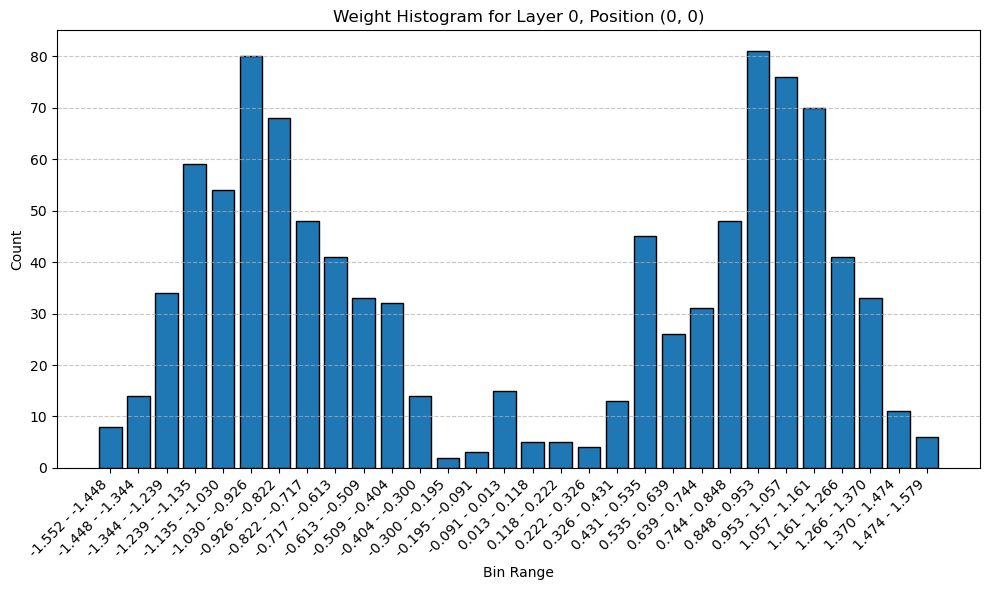

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

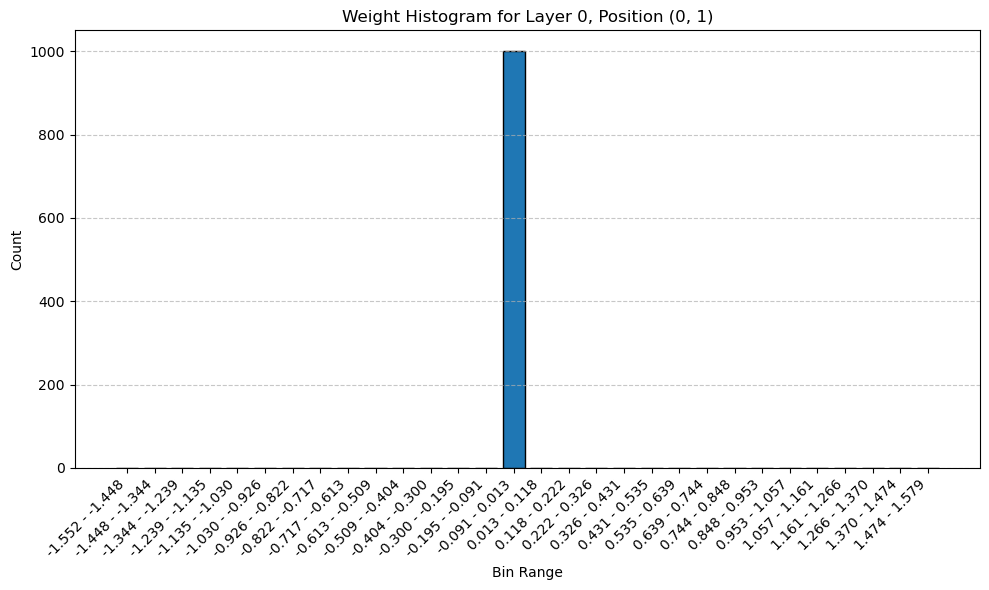

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

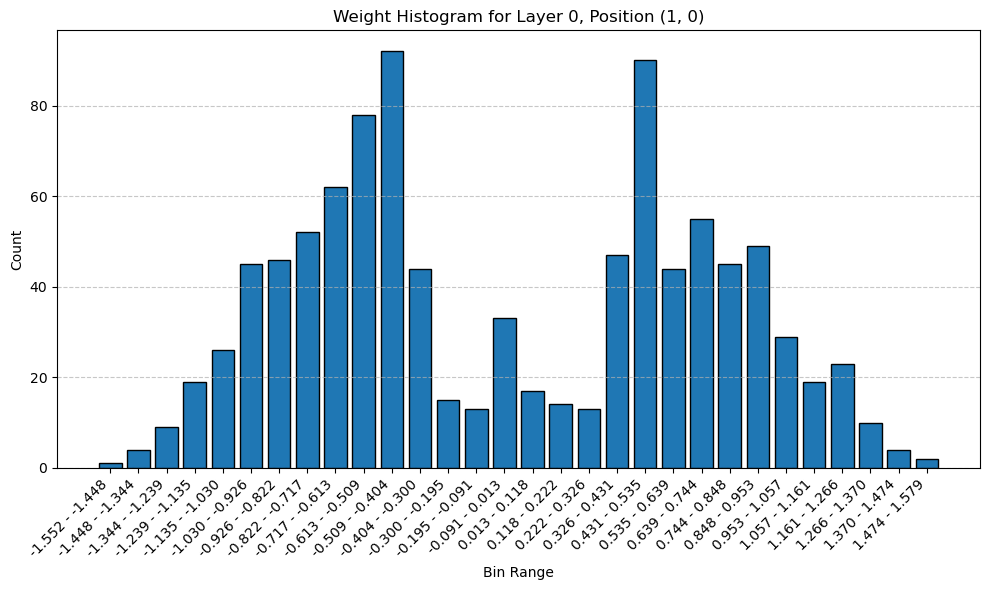

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

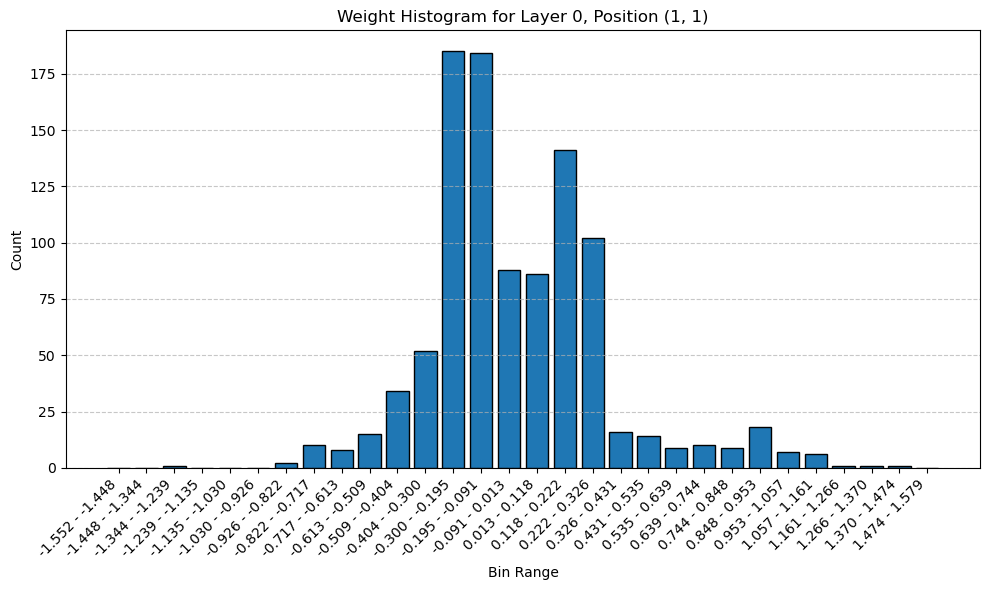

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

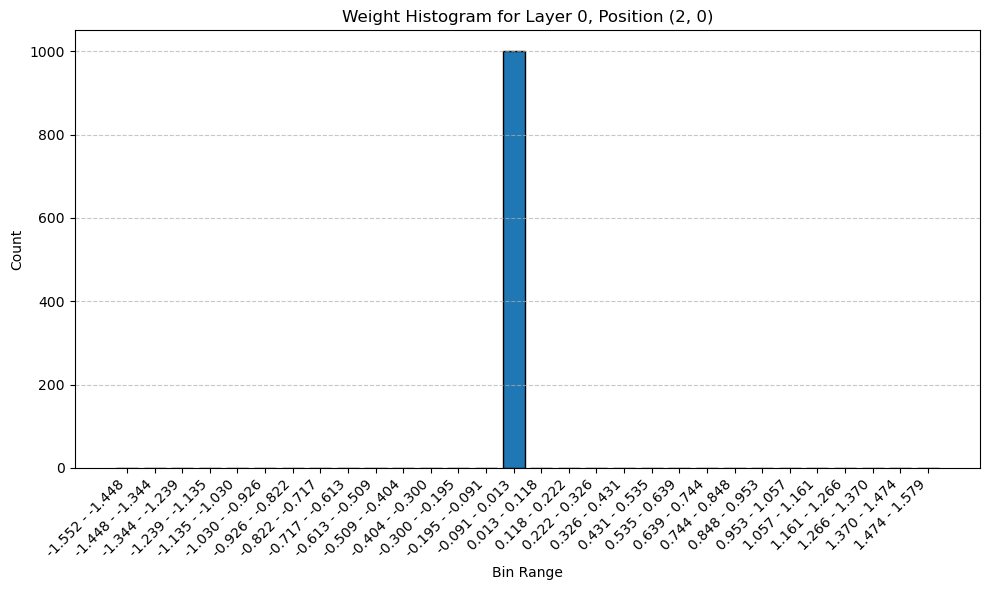

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

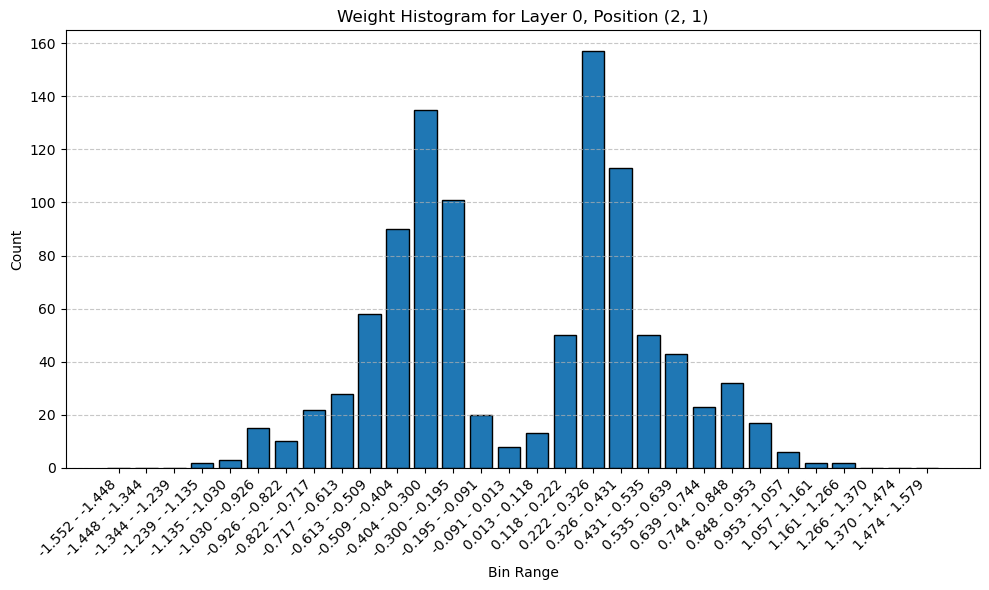

Press Enter to continue, or type 'q' to stop: 


<Figure size 640x480 with 0 Axes>

In [9]:
weights_walkthrough(perm_free_layer_weight_distributions, 'previous_layer_first', 0, perm_free_layer_bin_ranges[0])

Neuron 0, Incoming Weight 0


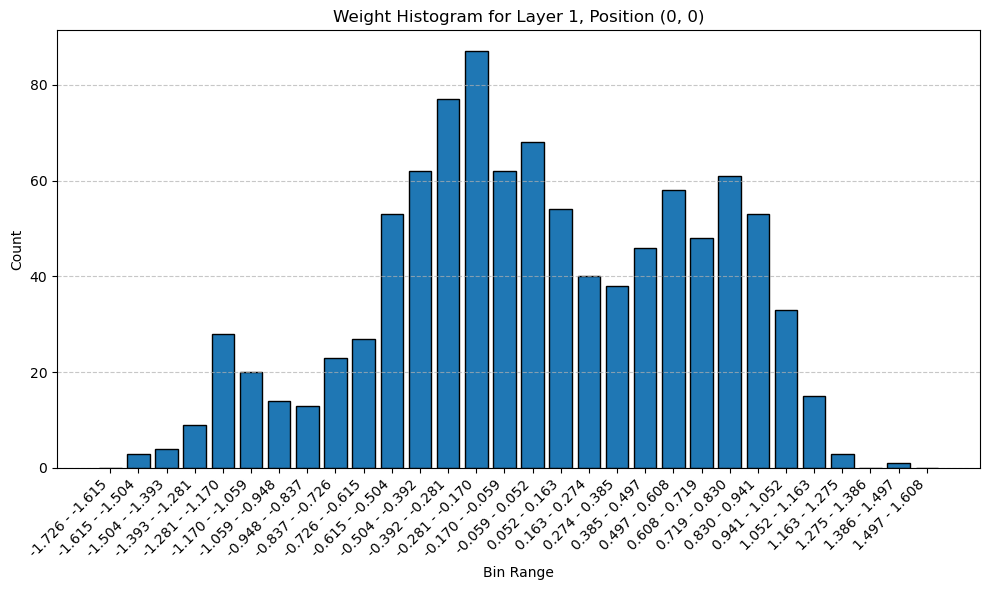

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

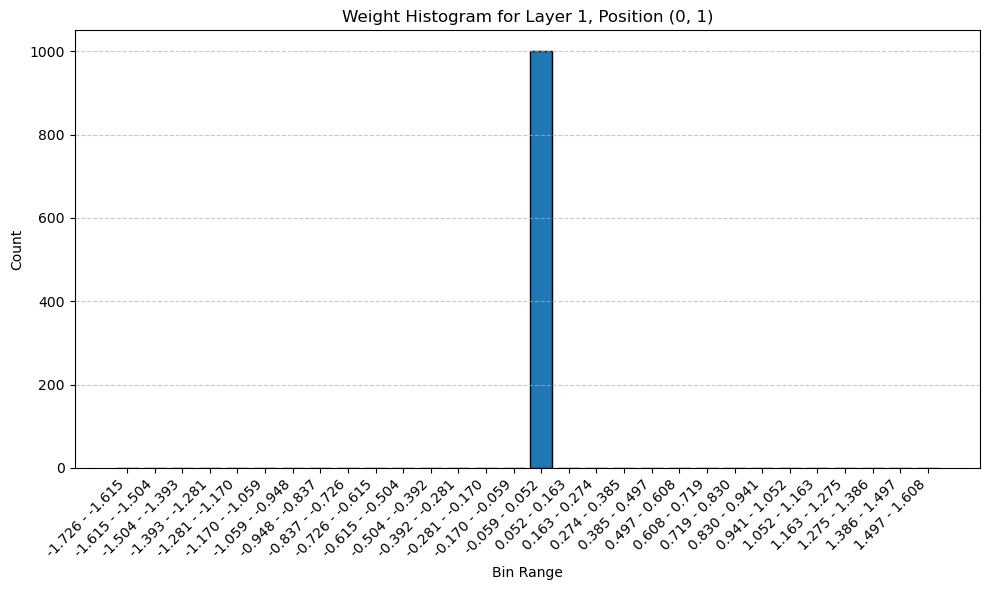

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

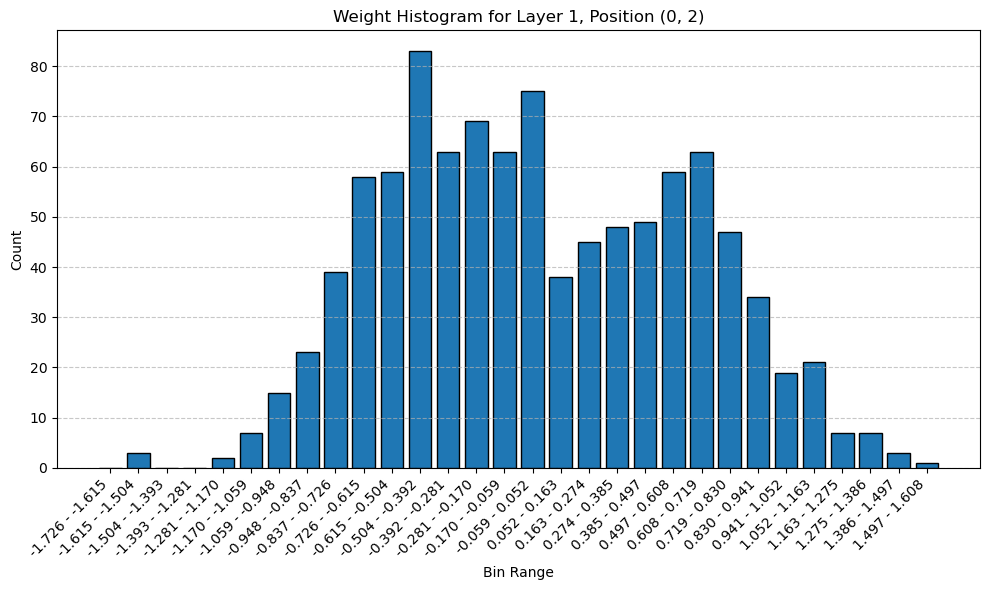

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

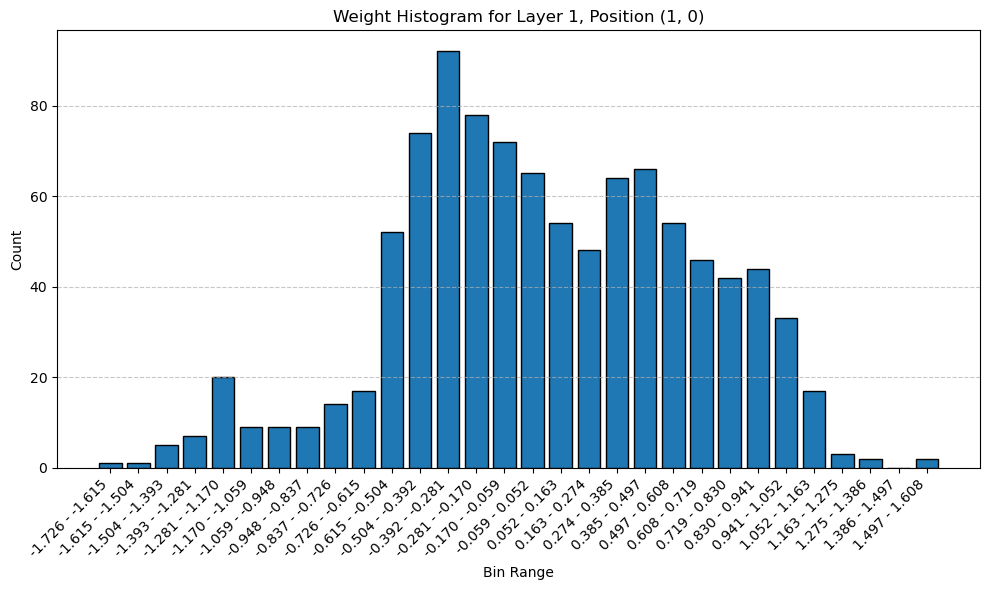

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

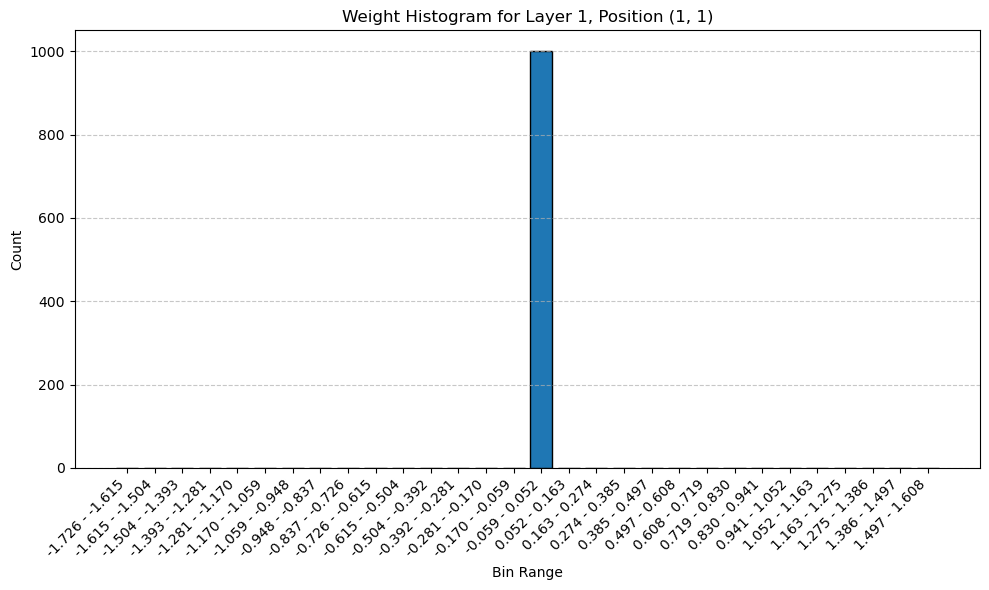

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

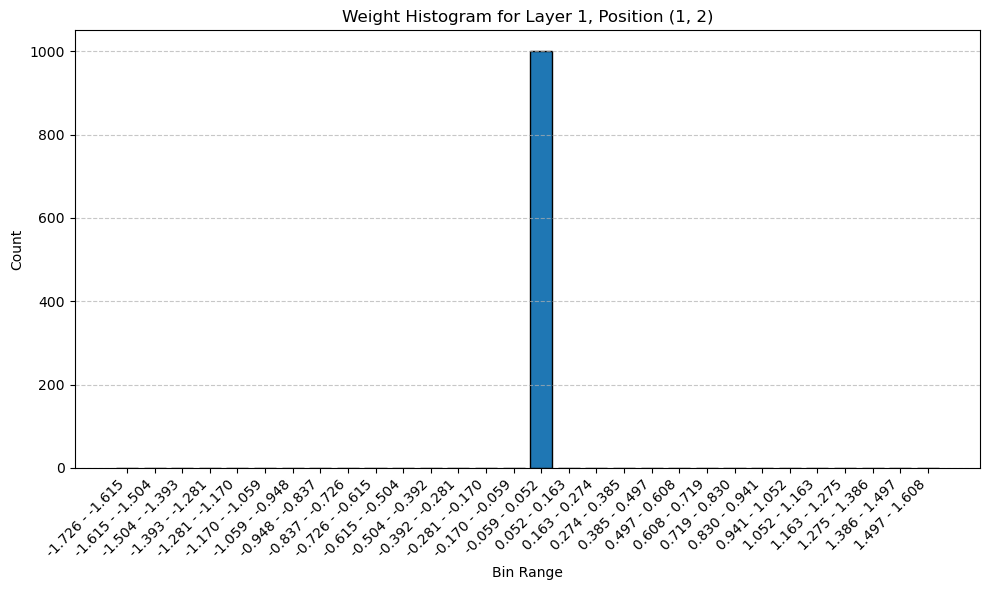

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

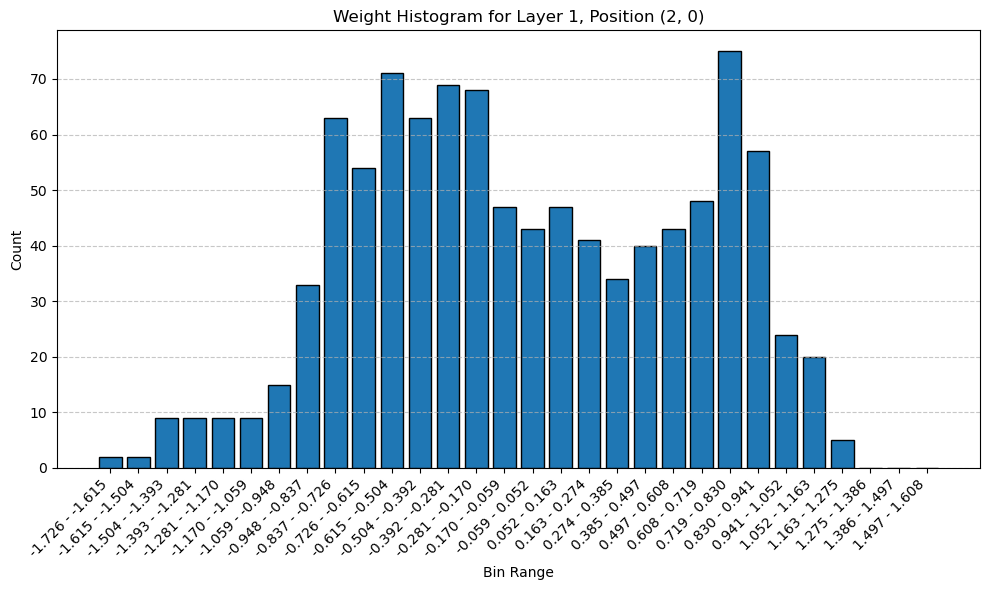

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

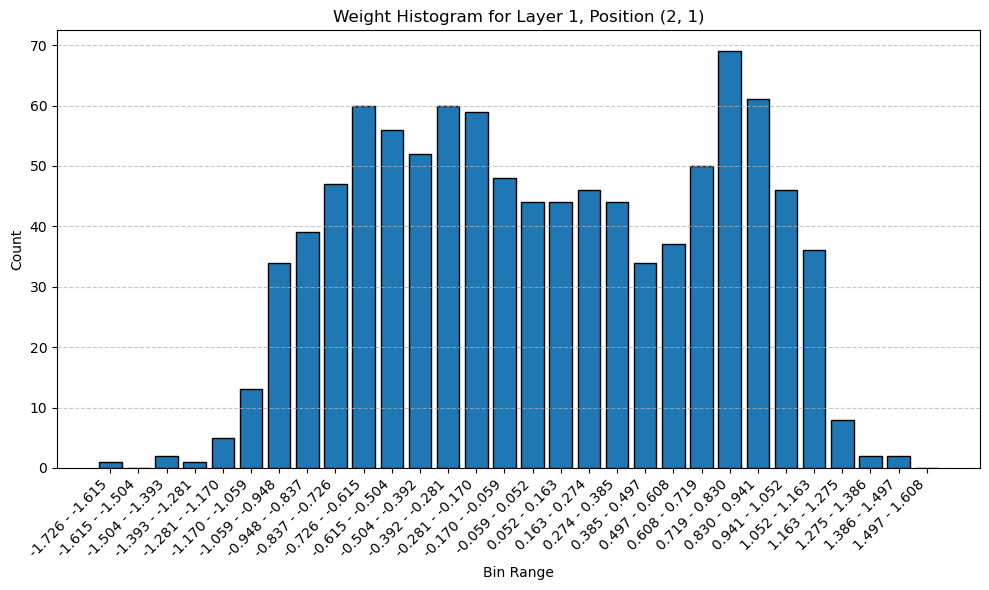

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

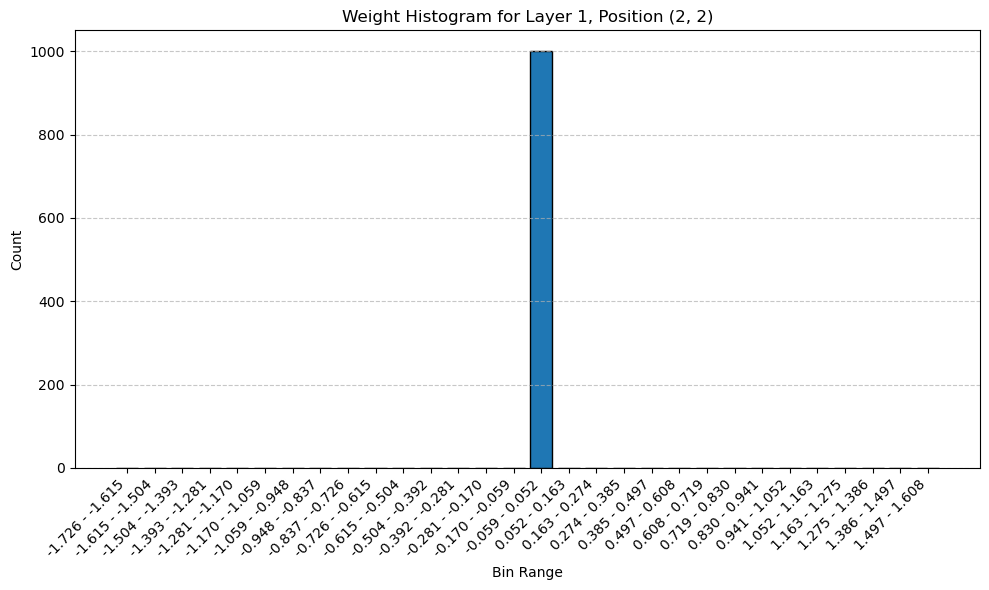

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

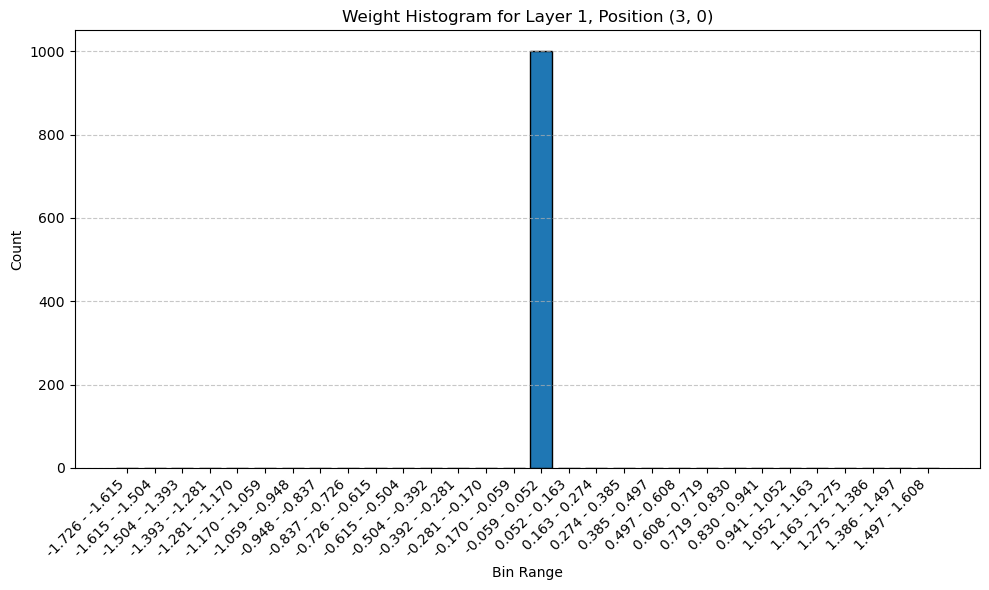

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

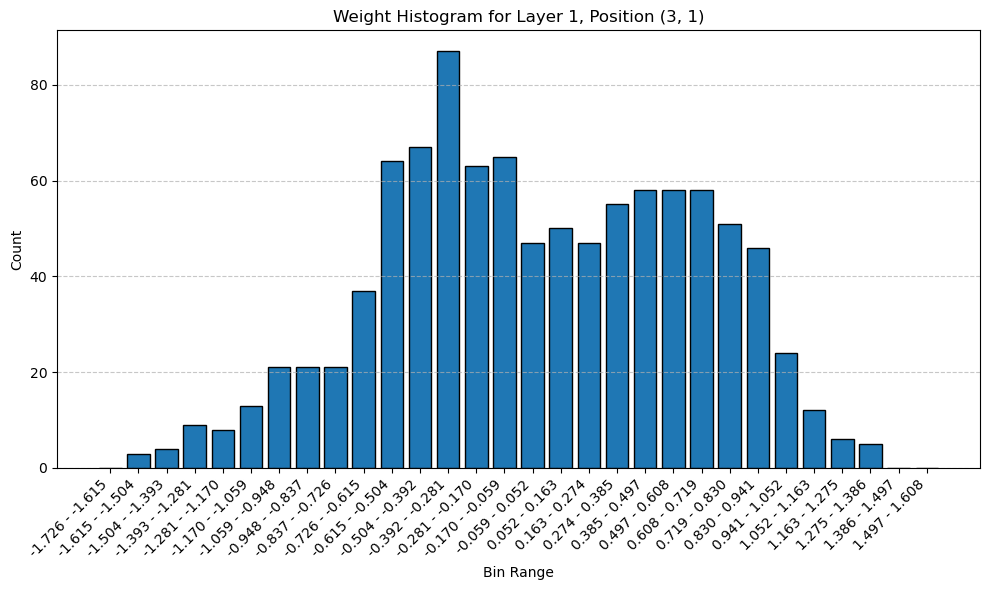

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

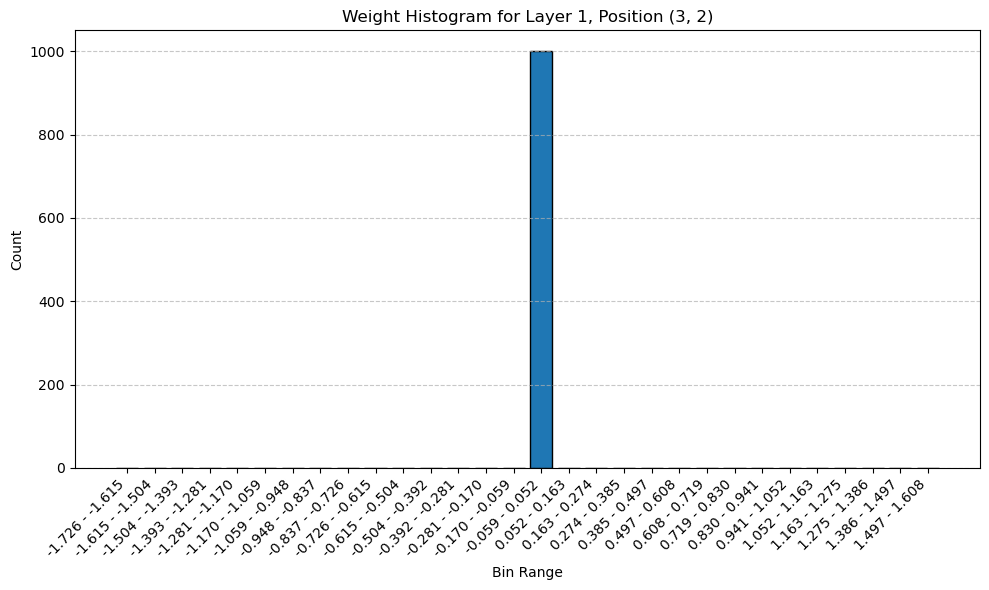

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

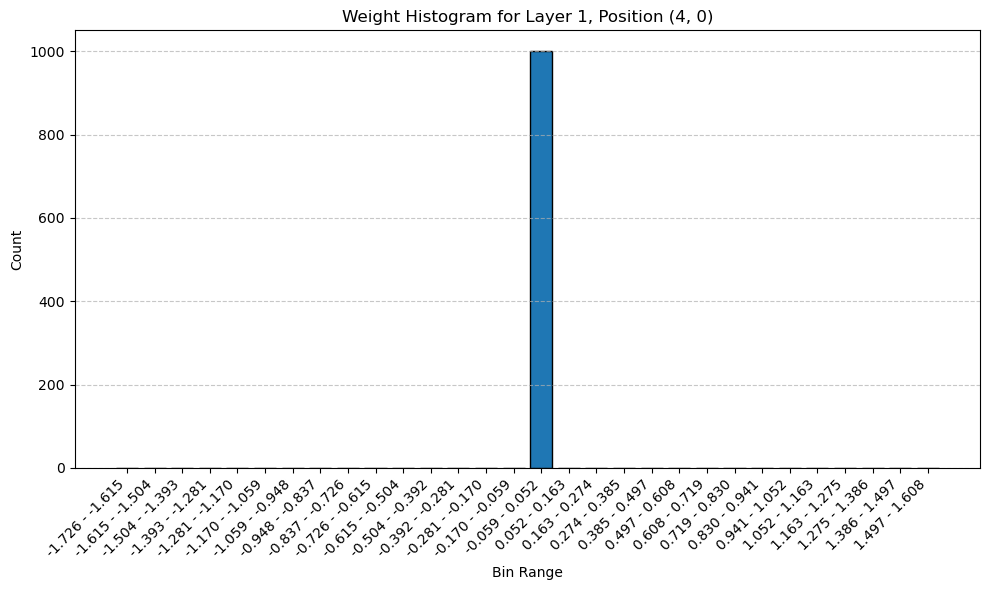

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

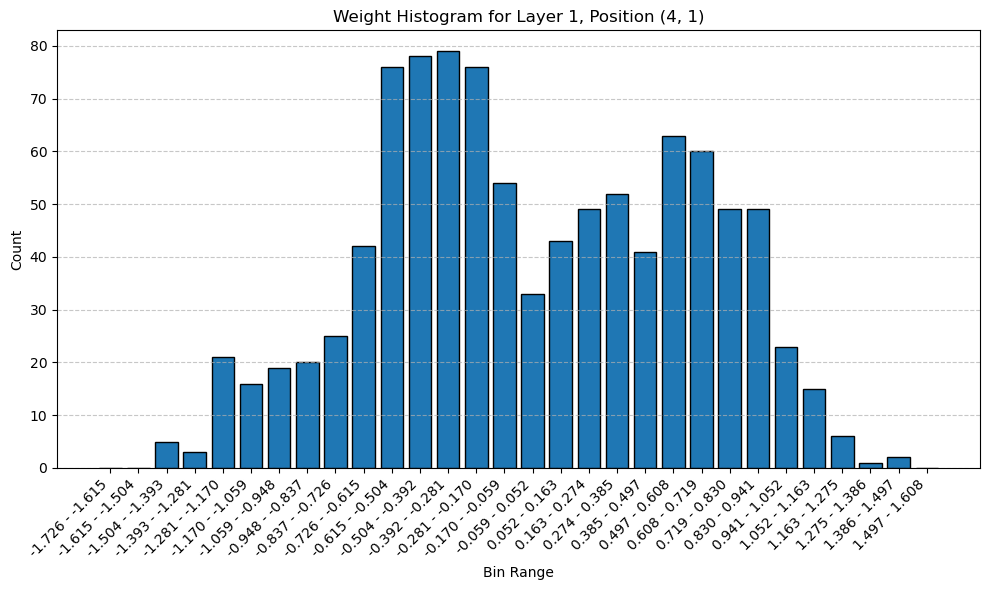

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

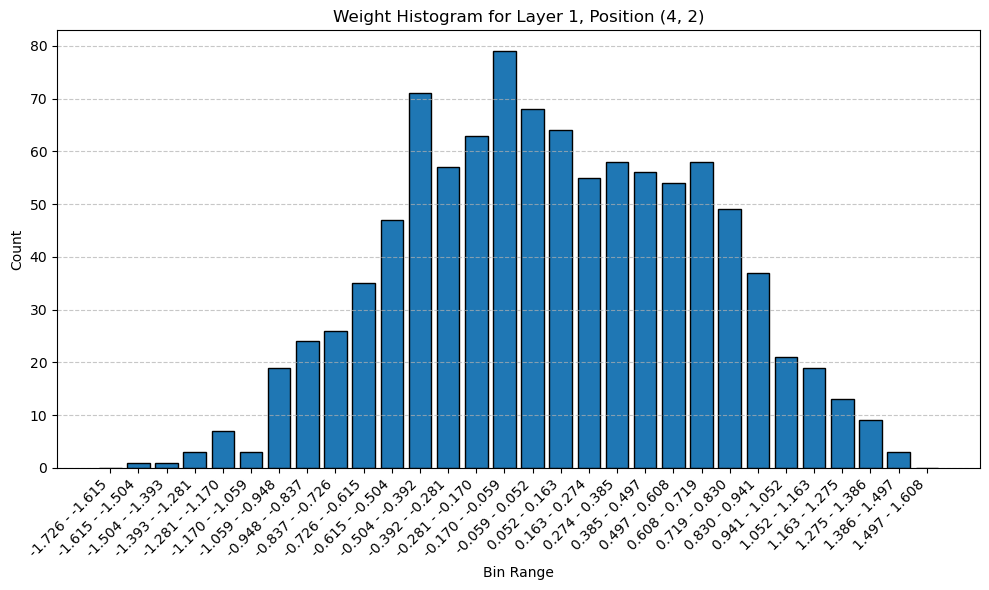

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

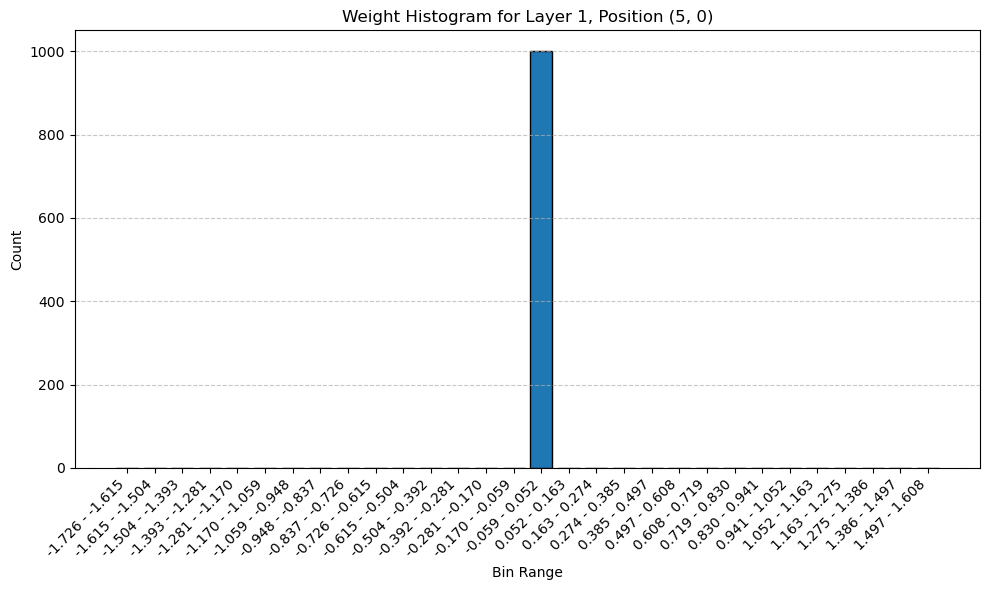

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

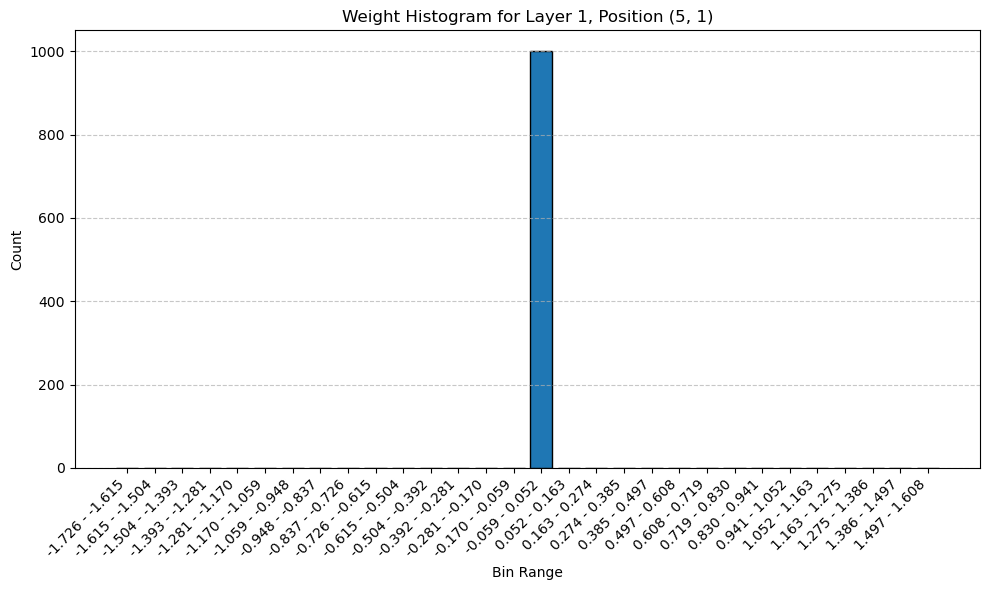

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

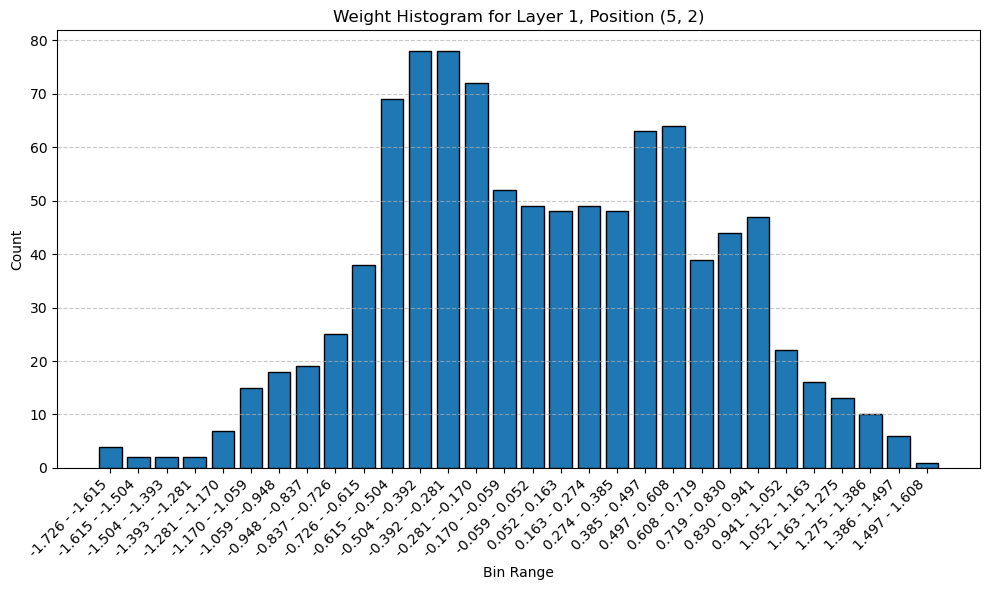

Press Enter to continue, or type 'q' to stop: 


<Figure size 640x480 with 0 Axes>

In [10]:
weights_walkthrough(perm_free_layer_weight_distributions, 'previous_layer_first', 1, perm_free_layer_bin_ranges[1])

Neuron 0, Incoming Weight 0


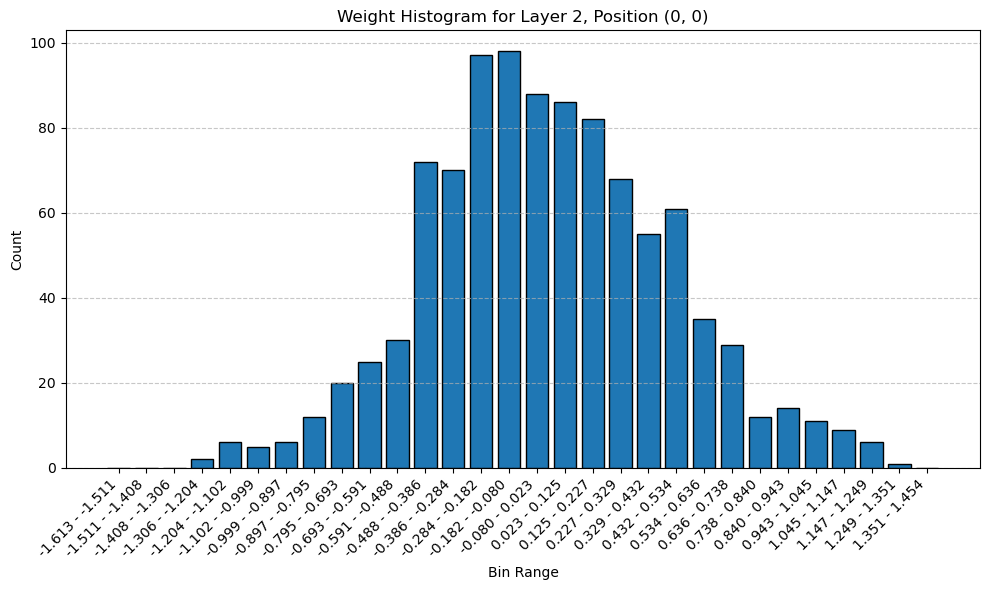

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

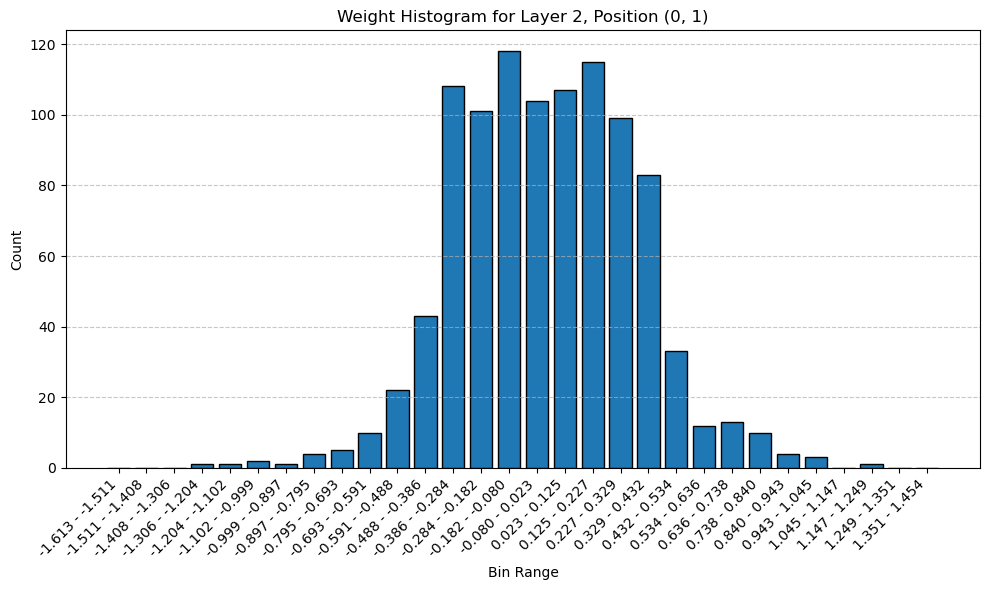

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

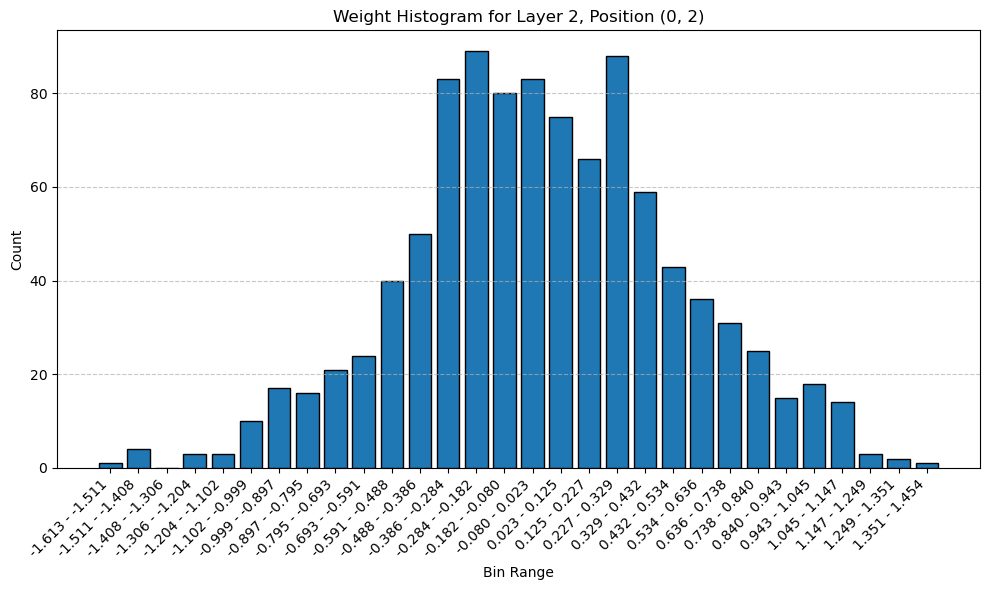

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

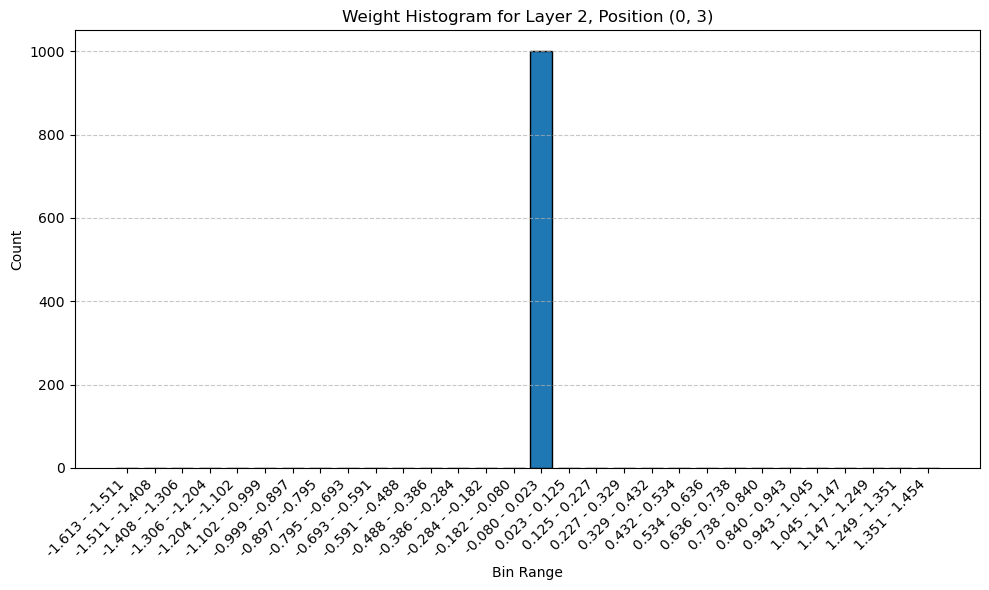

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

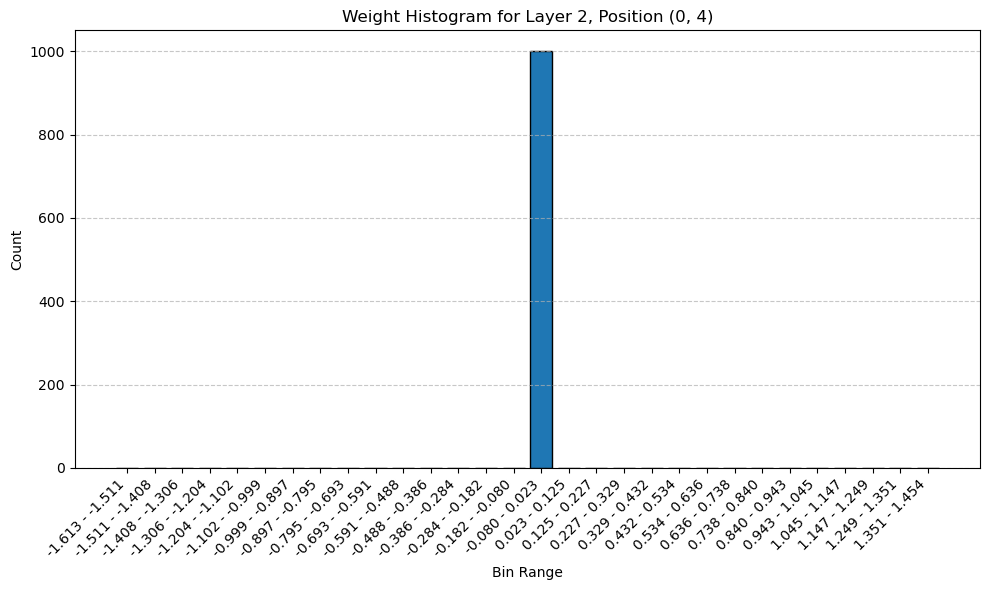

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

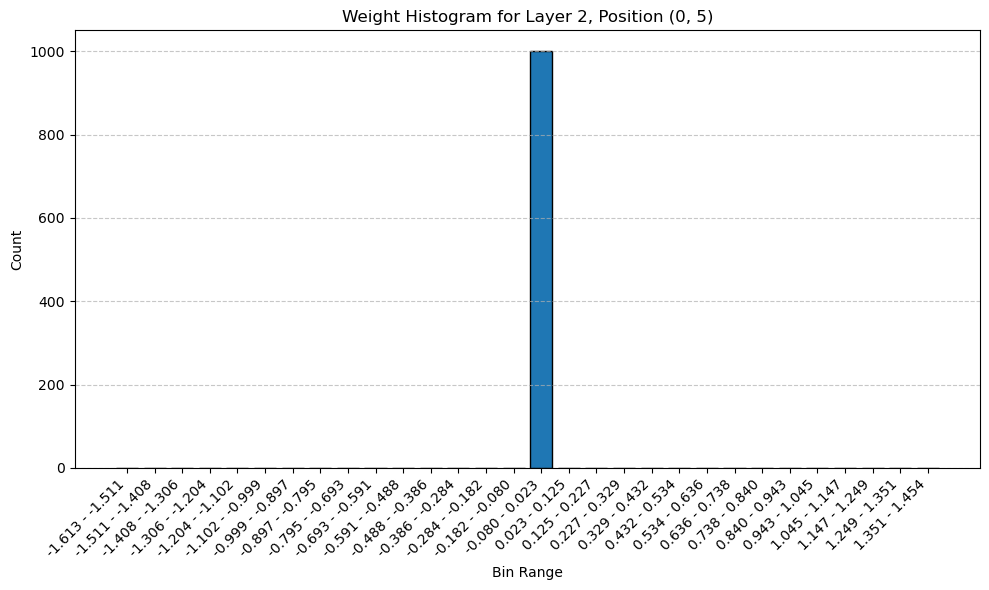

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

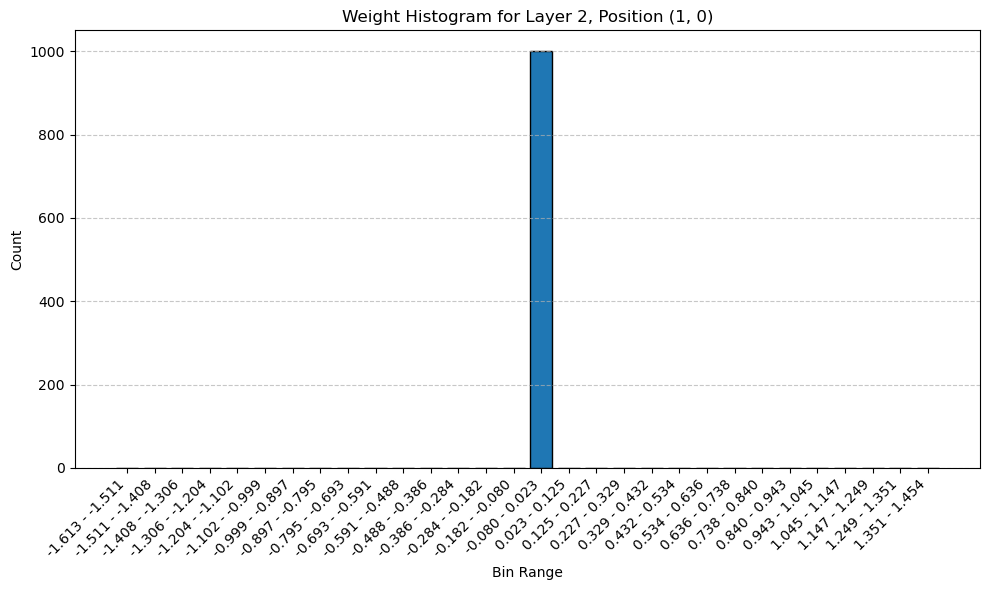

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

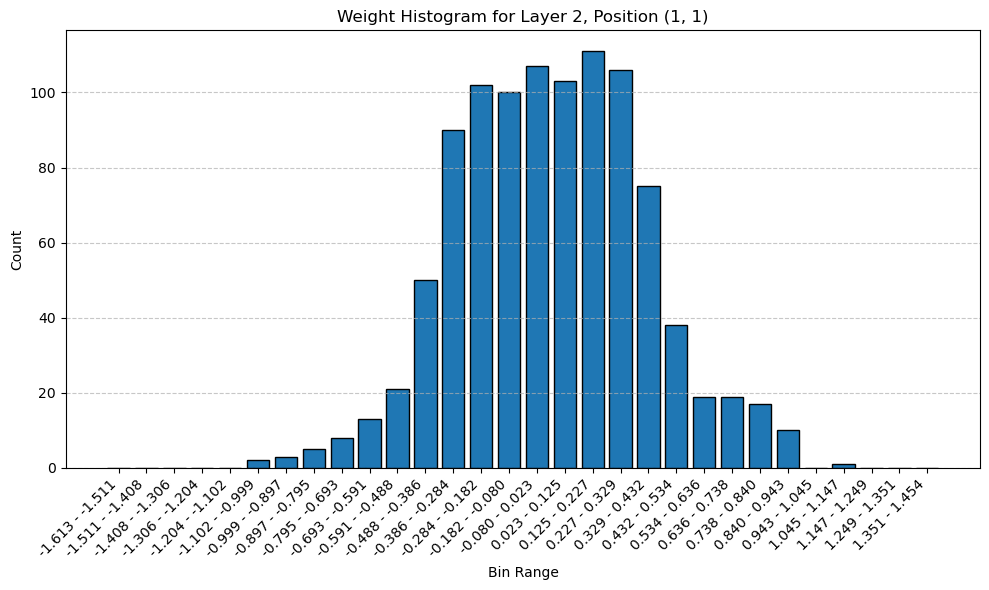

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

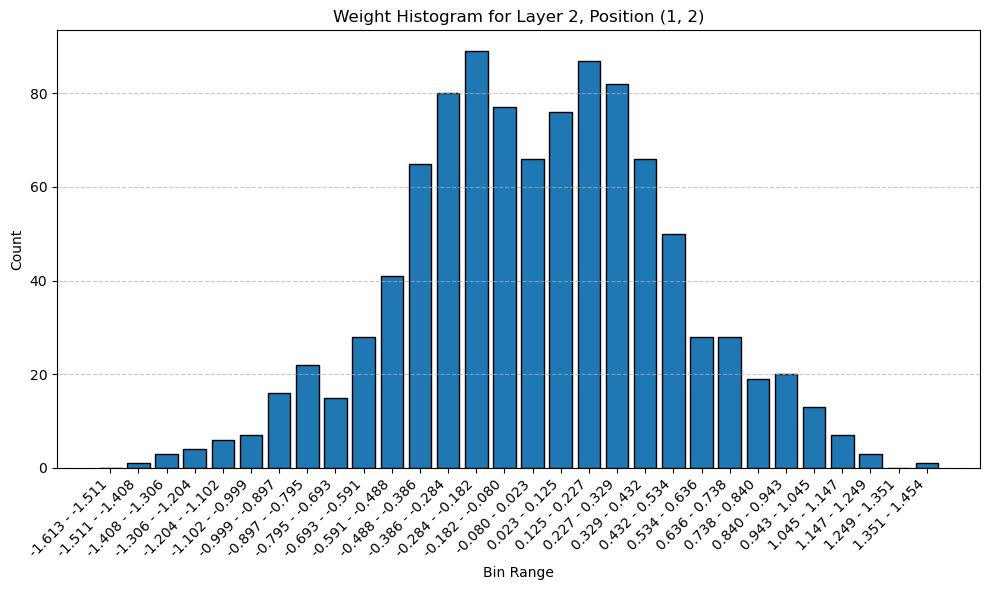

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

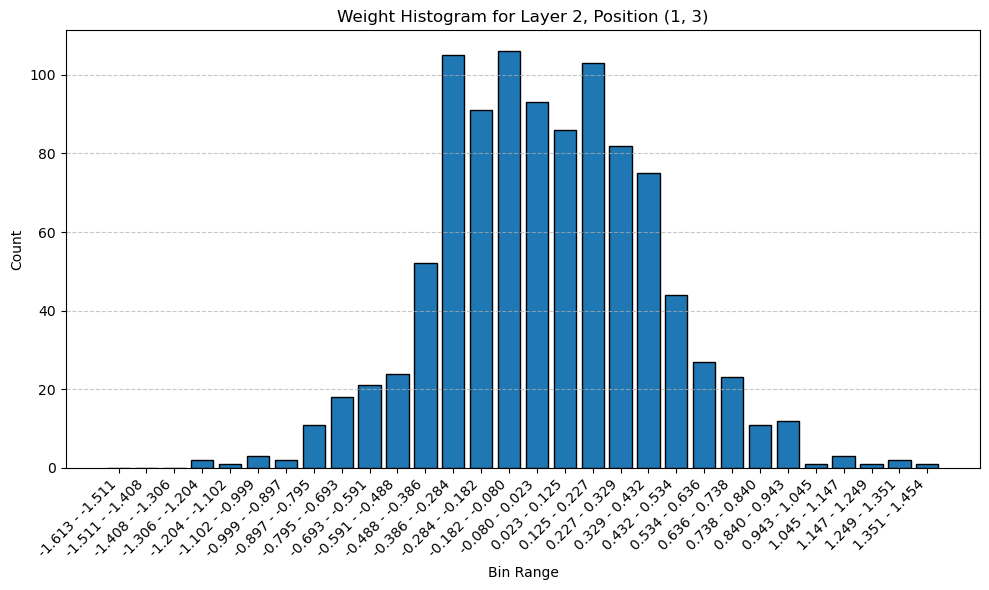

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

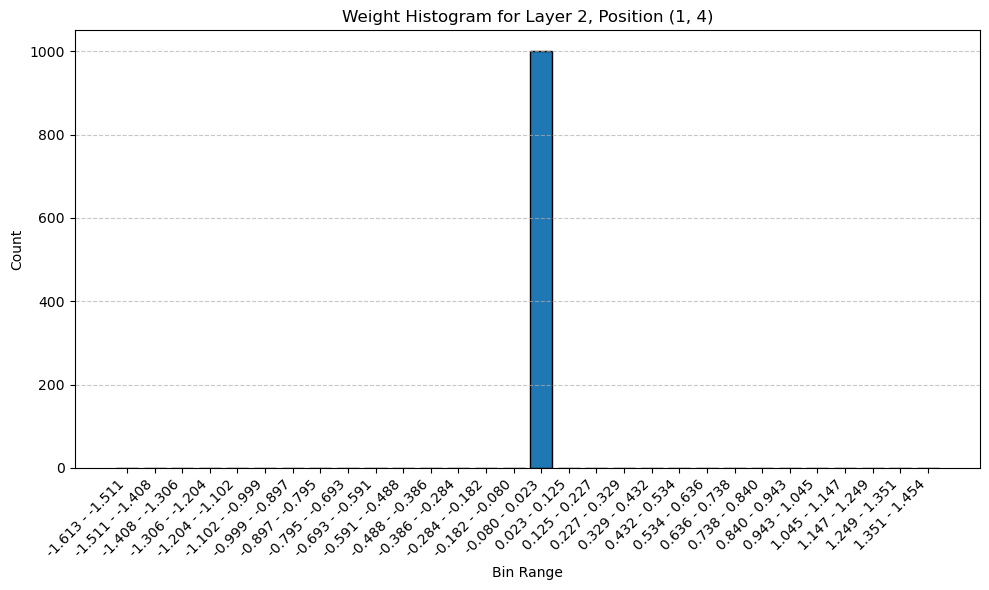

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

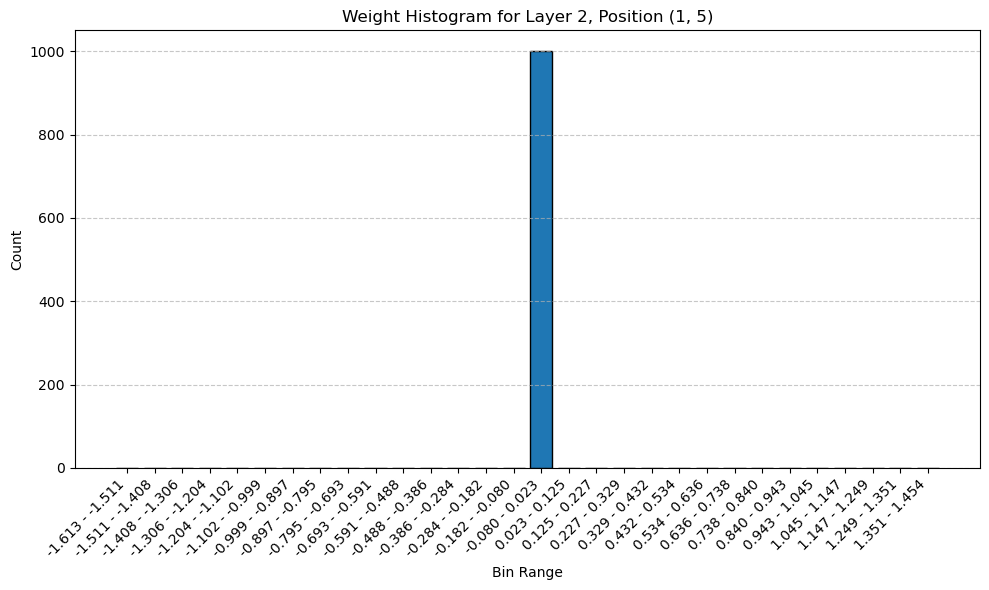

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

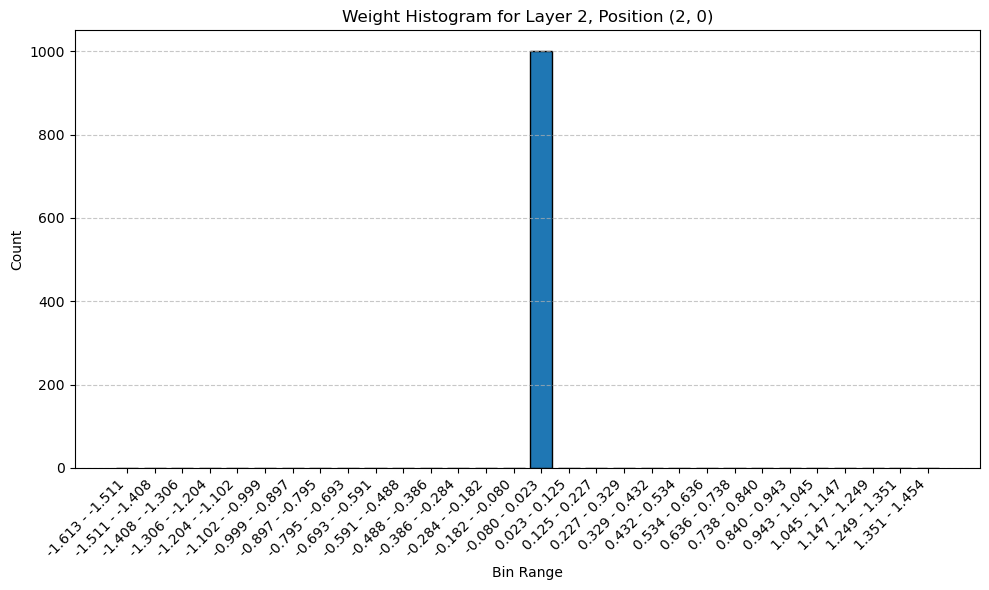

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

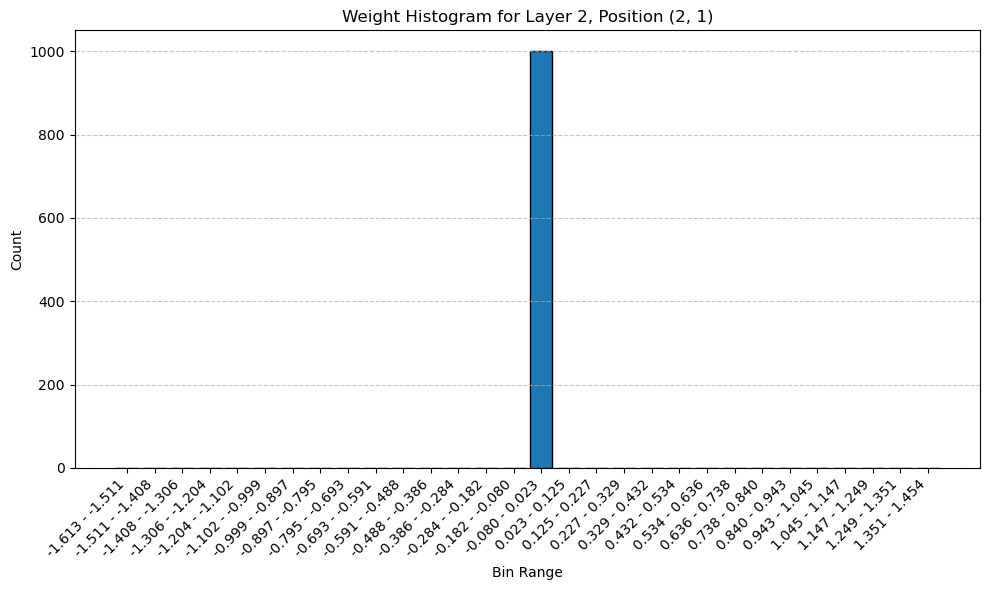

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

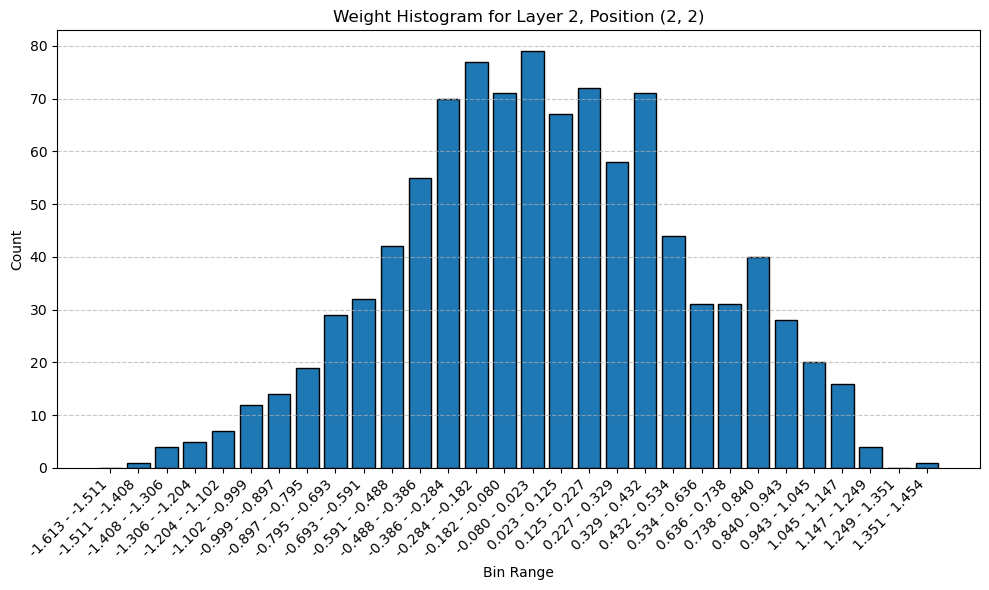

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

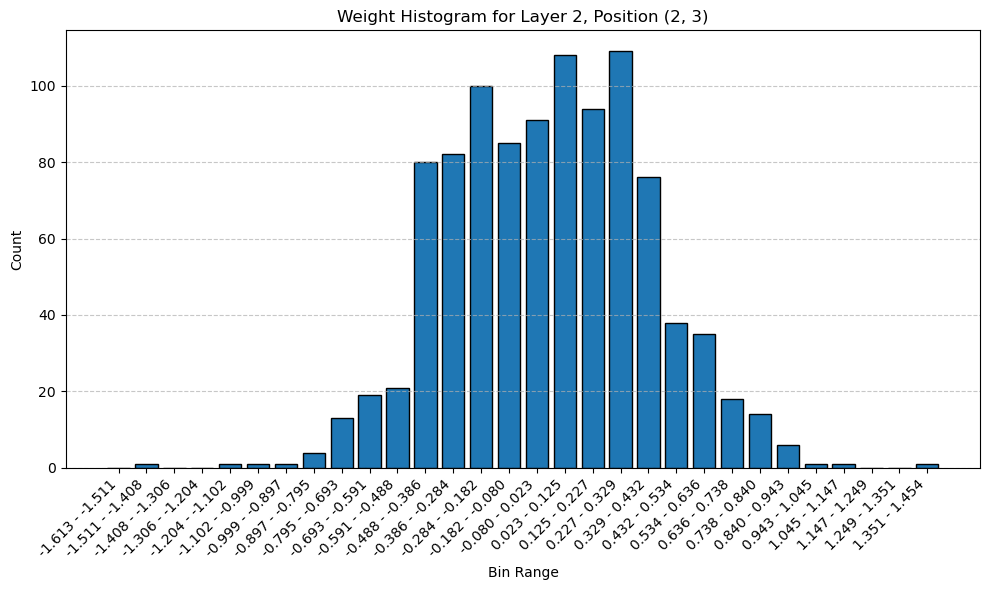

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

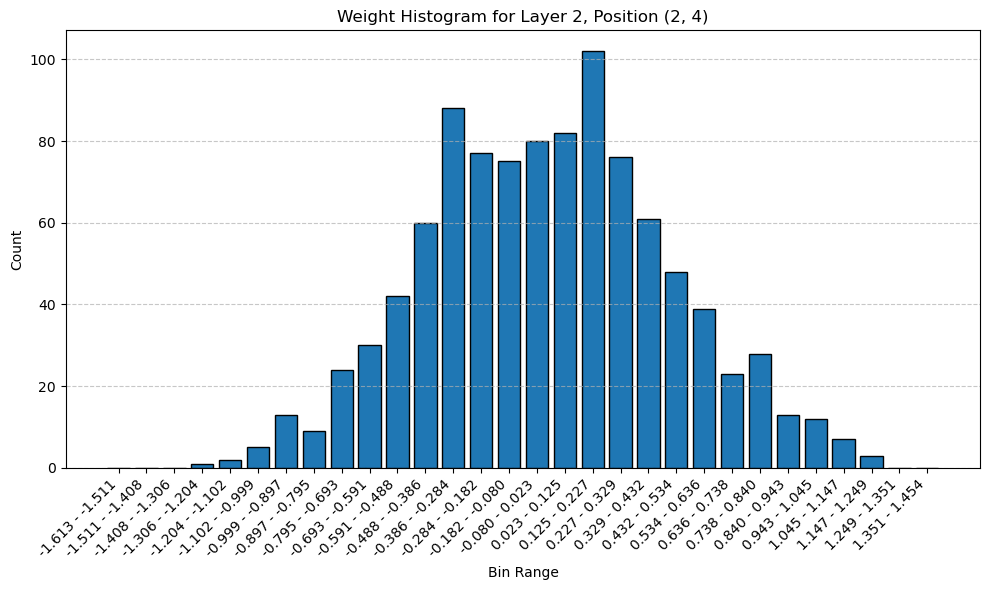

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

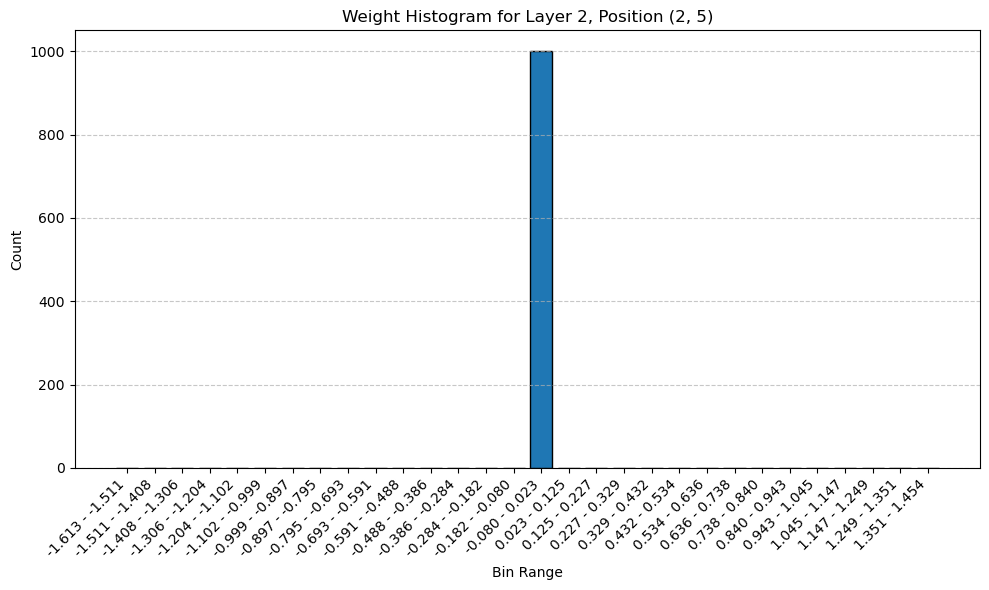

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

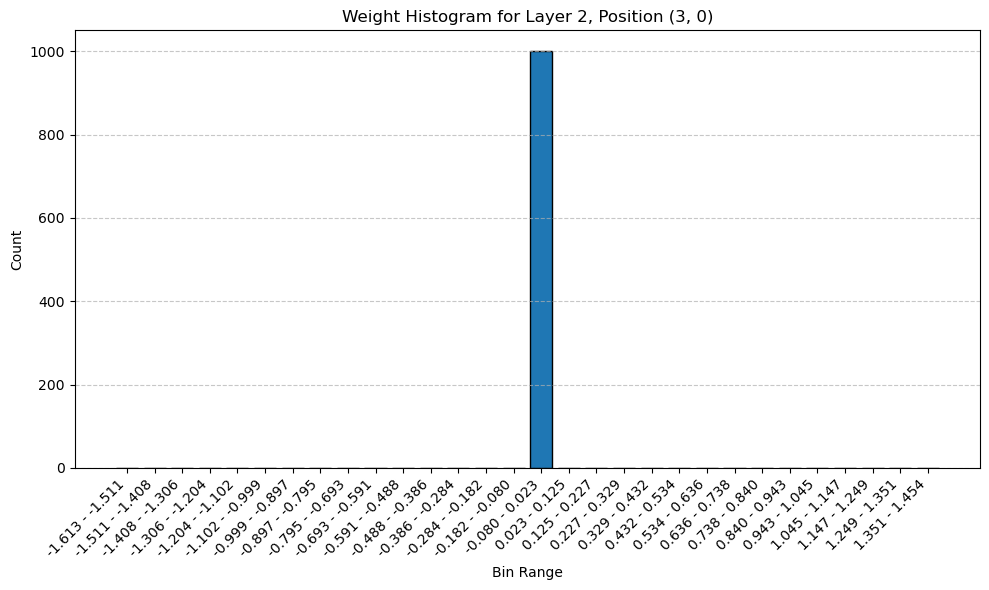

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

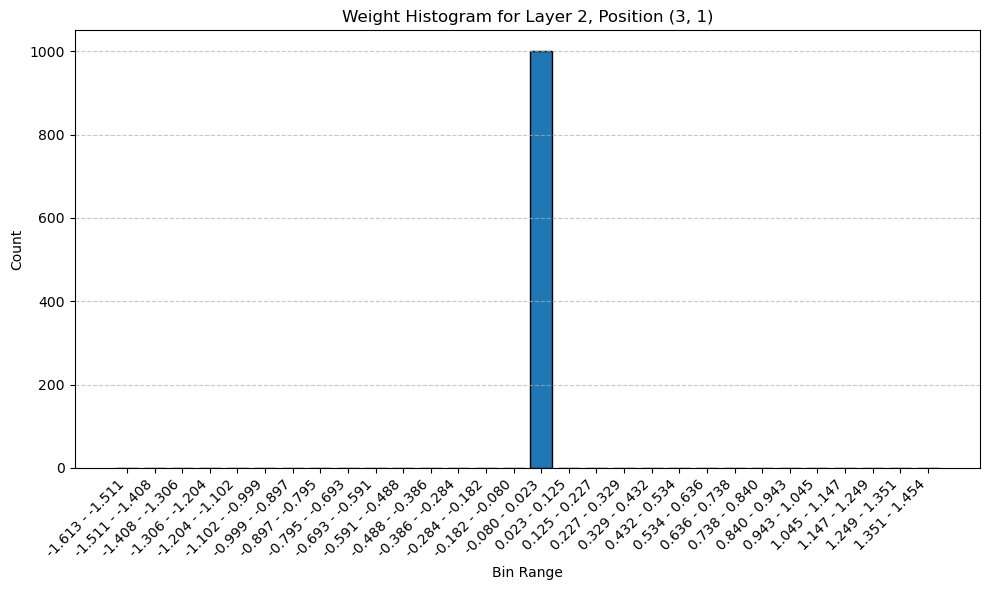

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

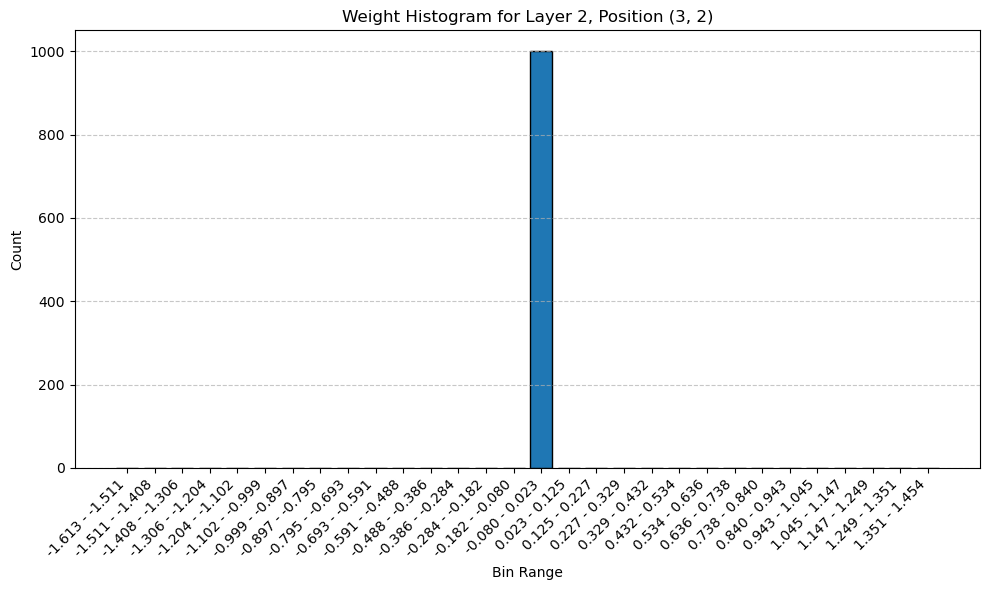

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

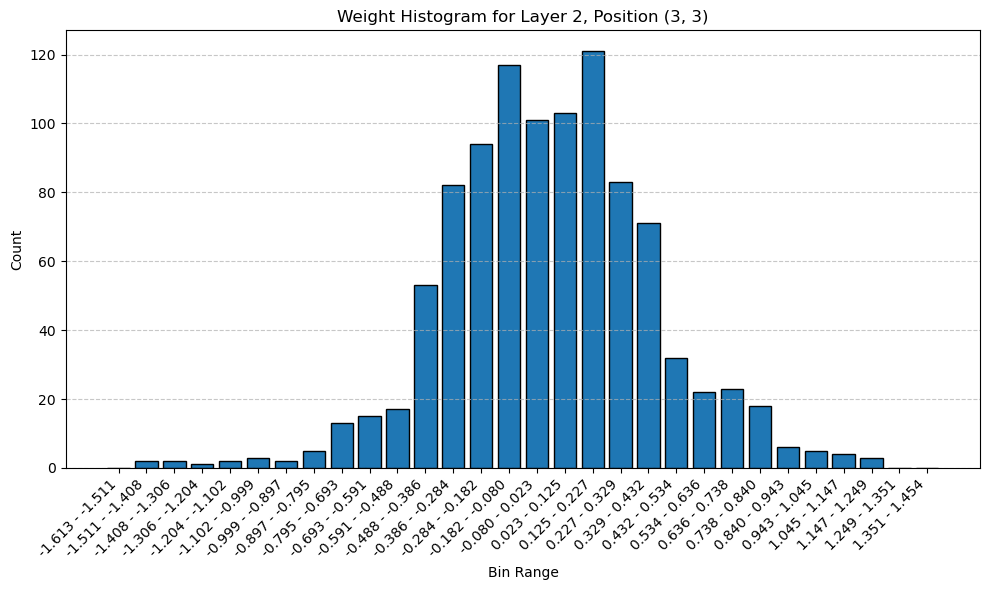

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

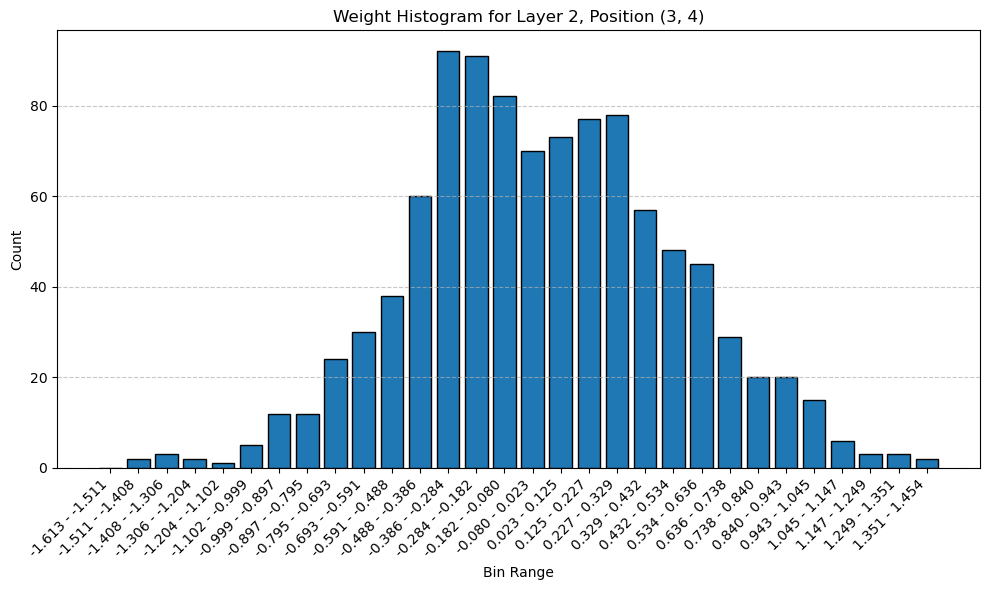

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

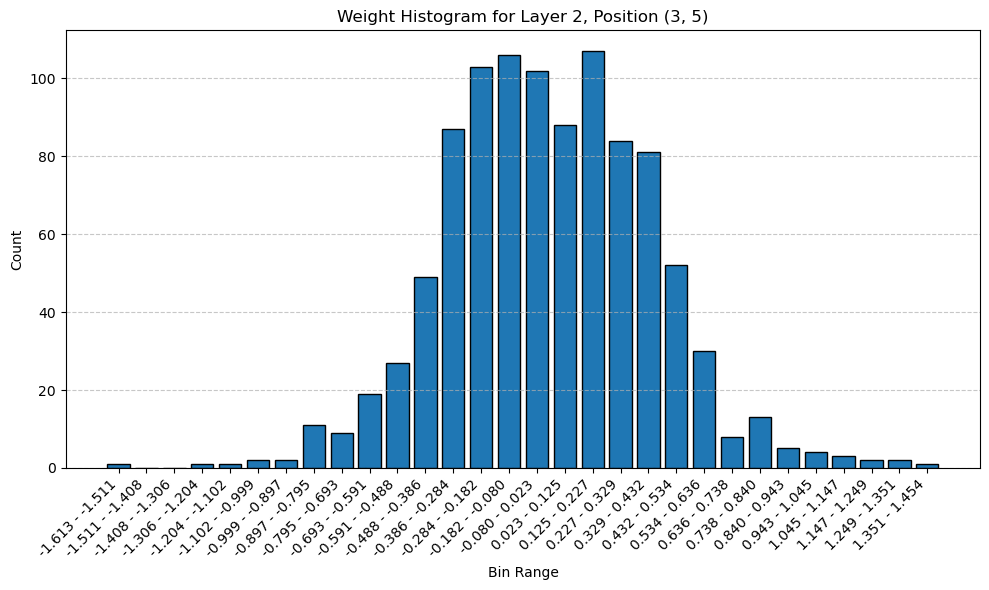

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

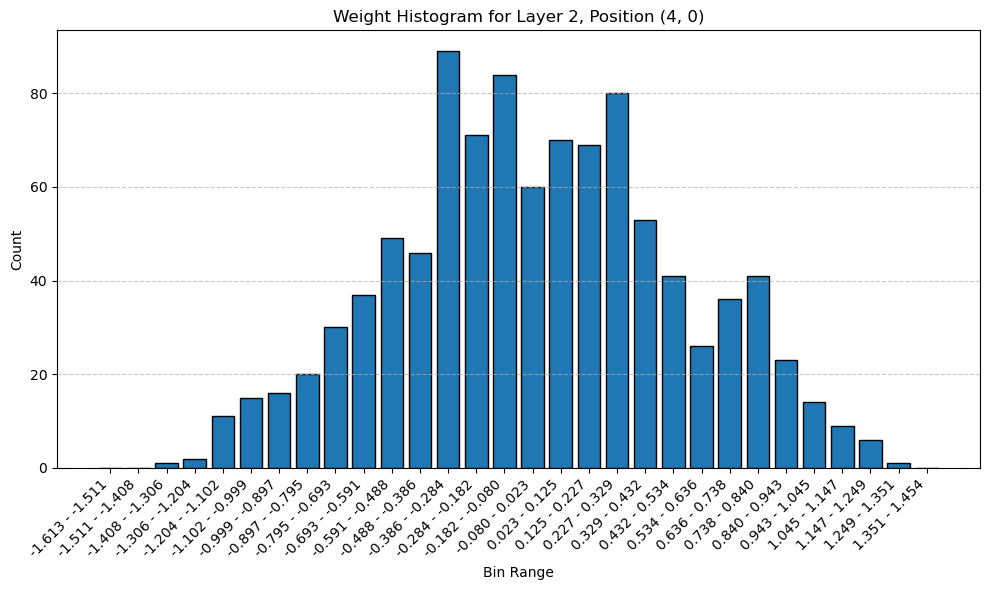

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

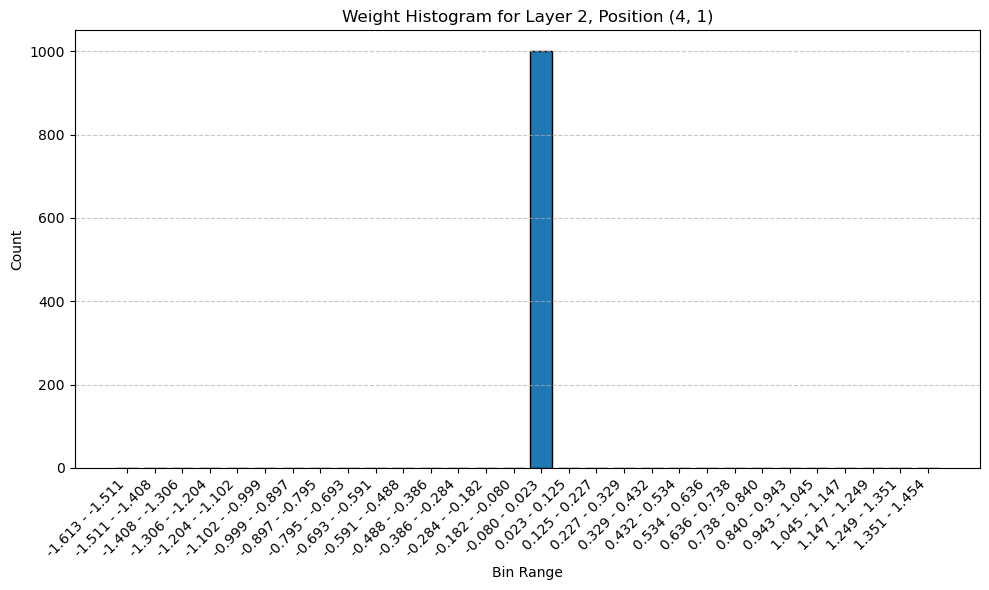

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

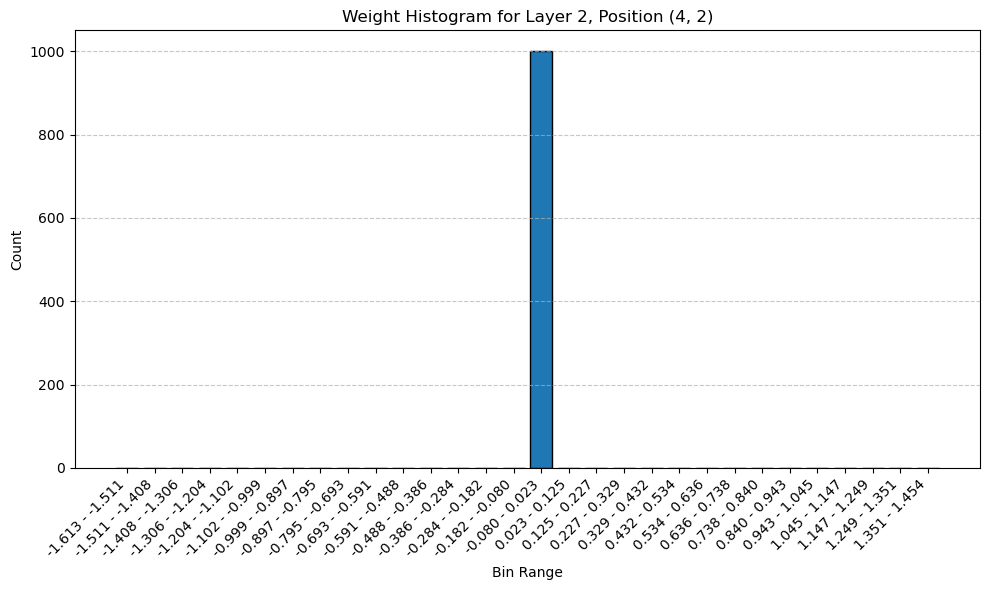

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

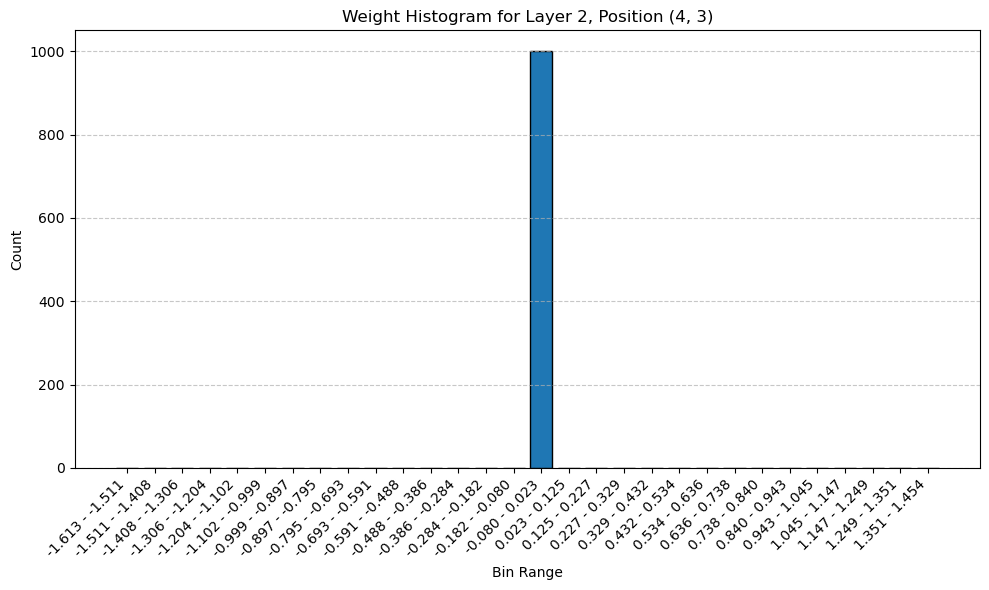

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

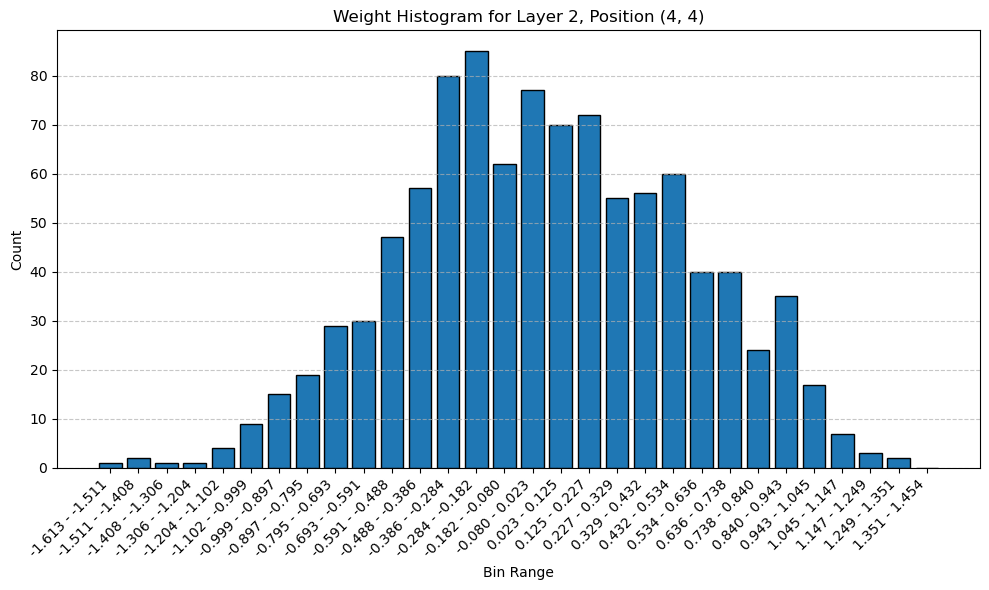

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

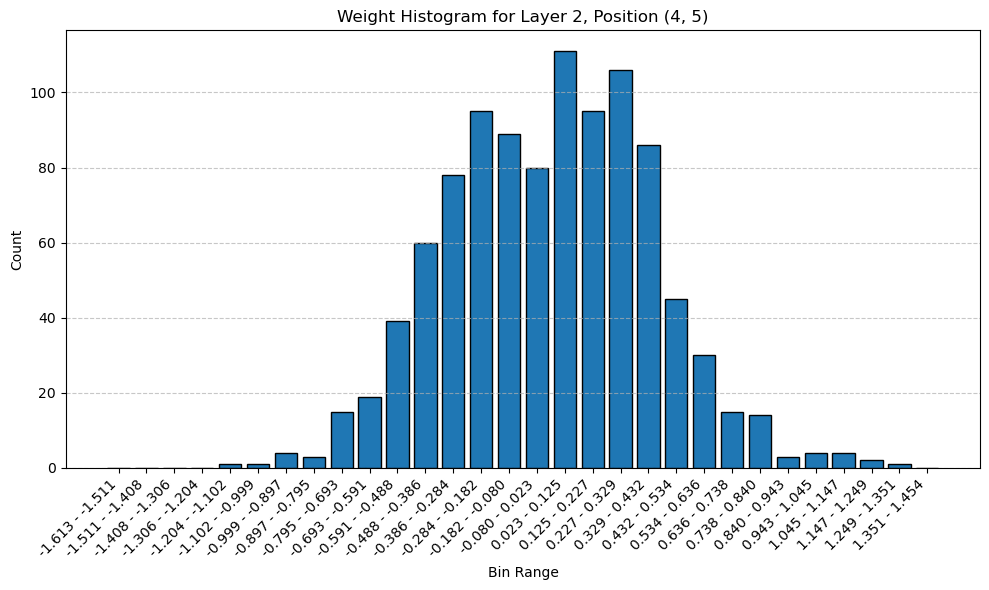

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

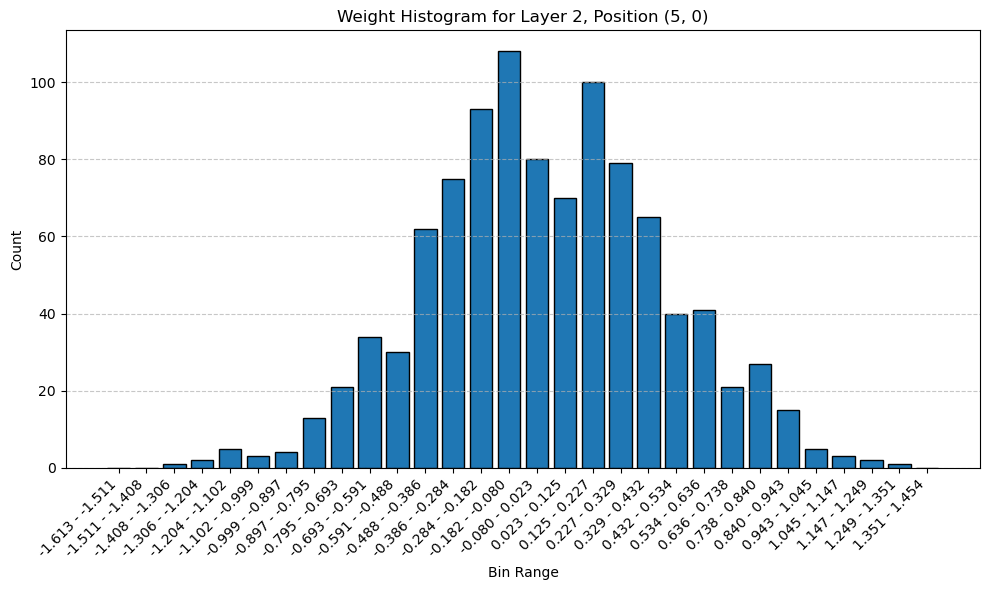

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

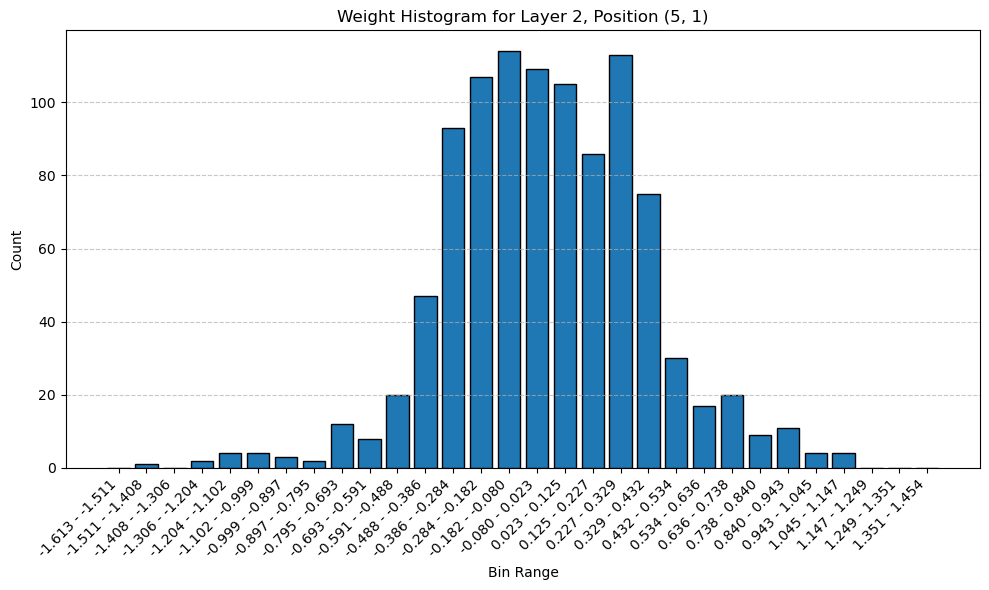

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

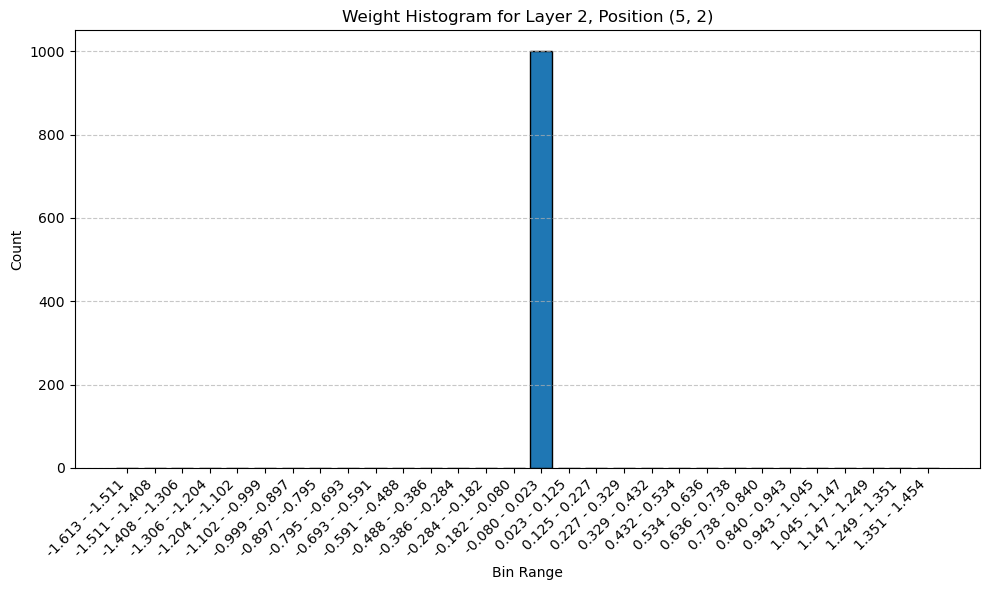

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

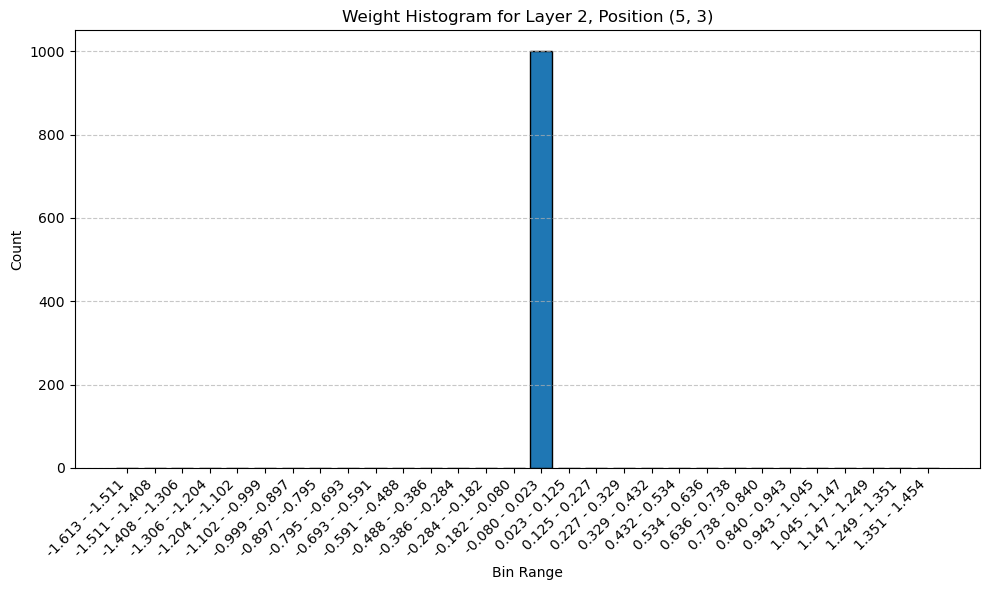

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

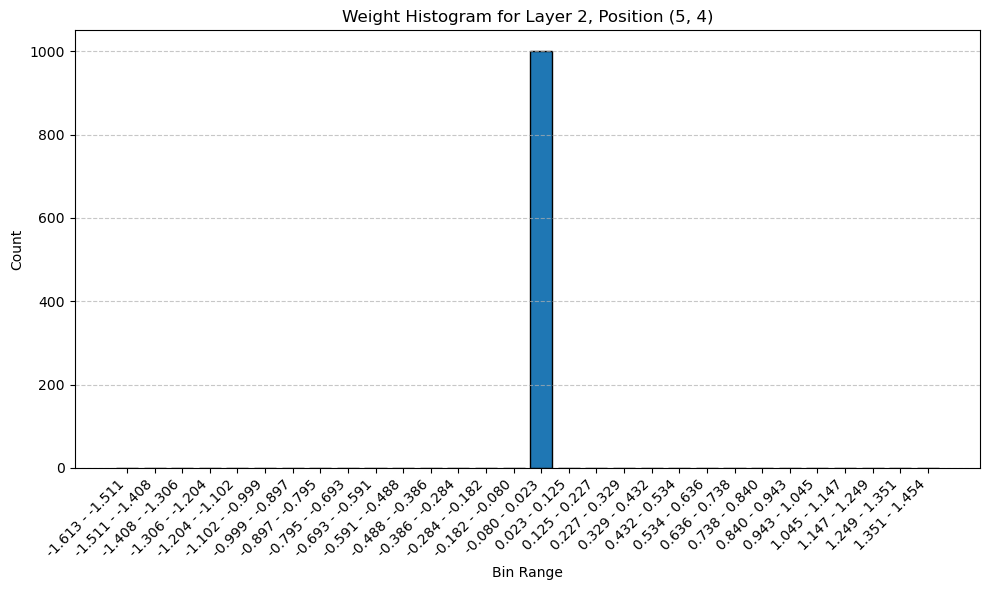

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

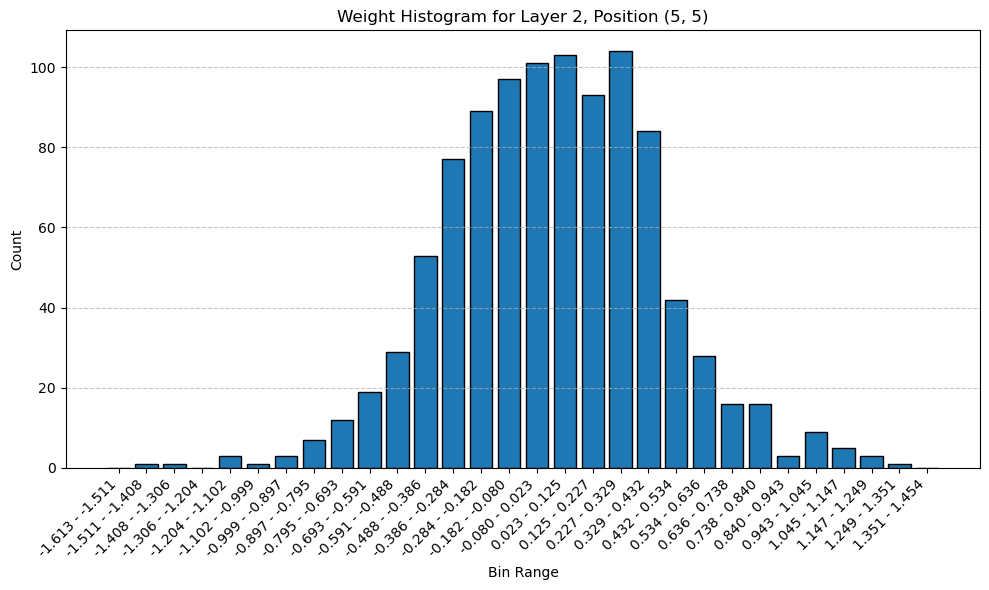

Press Enter to continue, or type 'q' to stop: 


<Figure size 640x480 with 0 Axes>

In [11]:
weights_walkthrough(perm_free_layer_weight_distributions, 'previous_layer_first', 2, perm_free_layer_bin_ranges[2])

Neuron 0, Incoming Weight 0


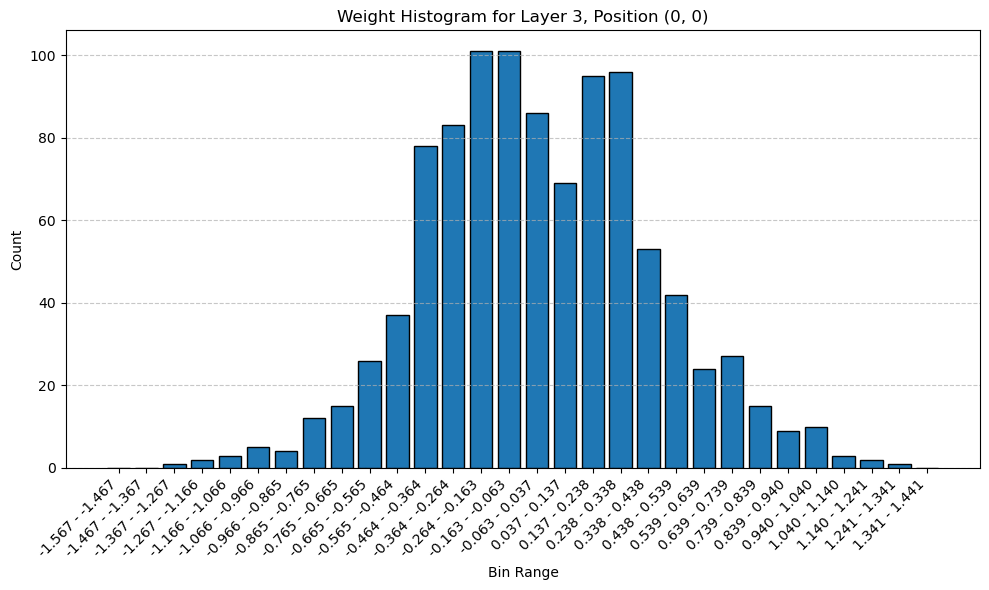

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

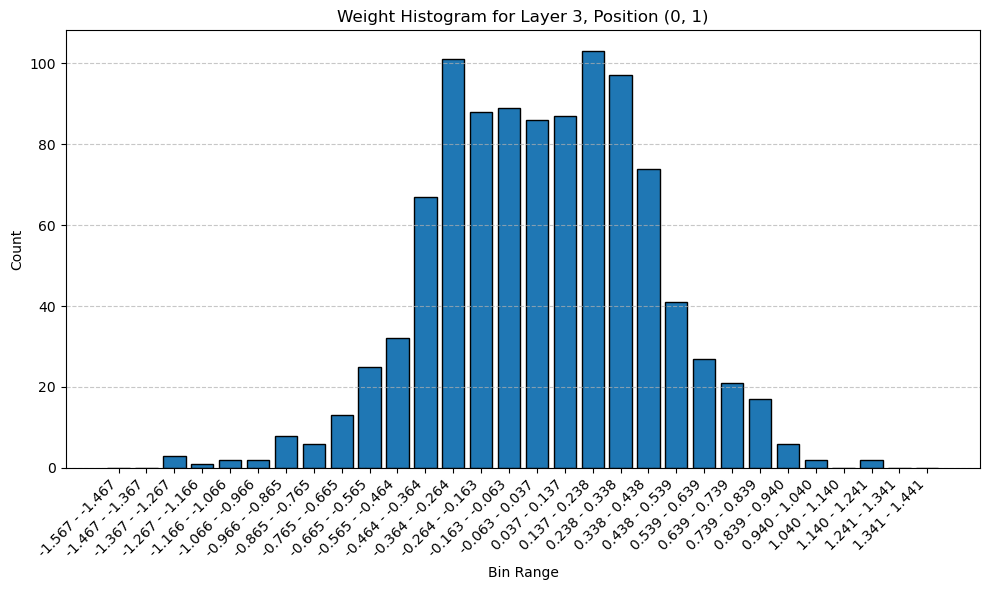

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

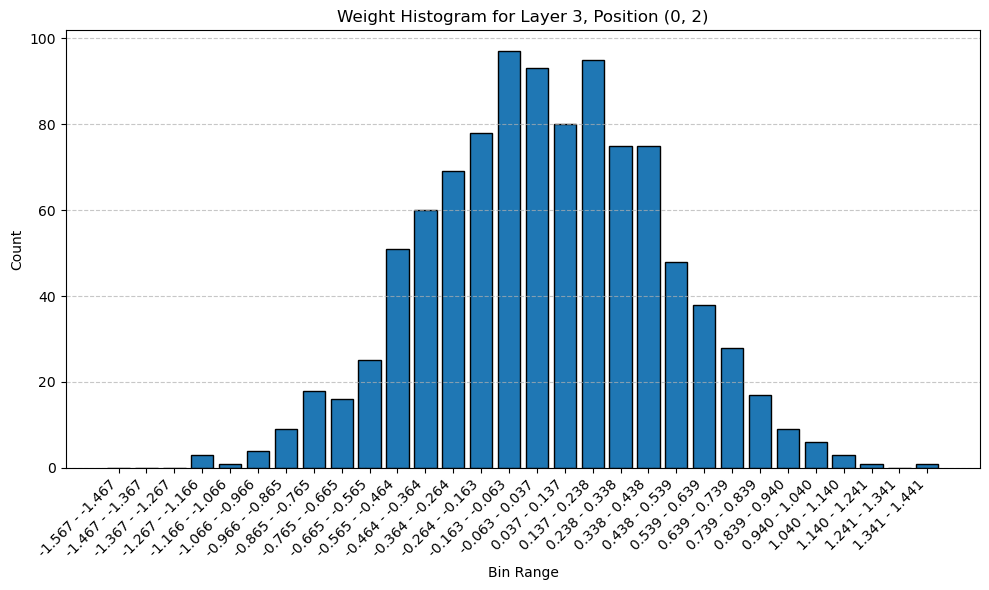

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

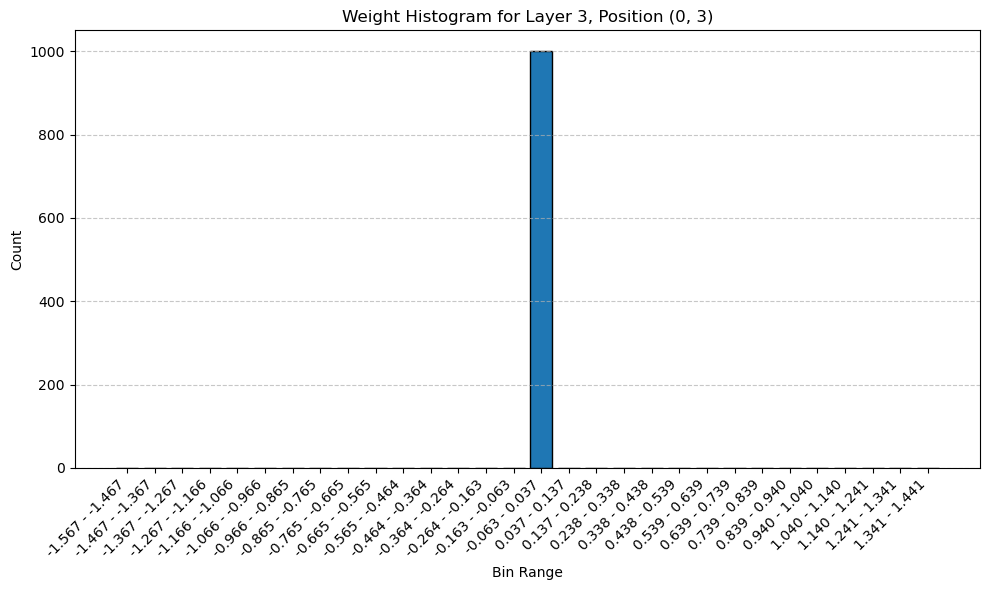

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

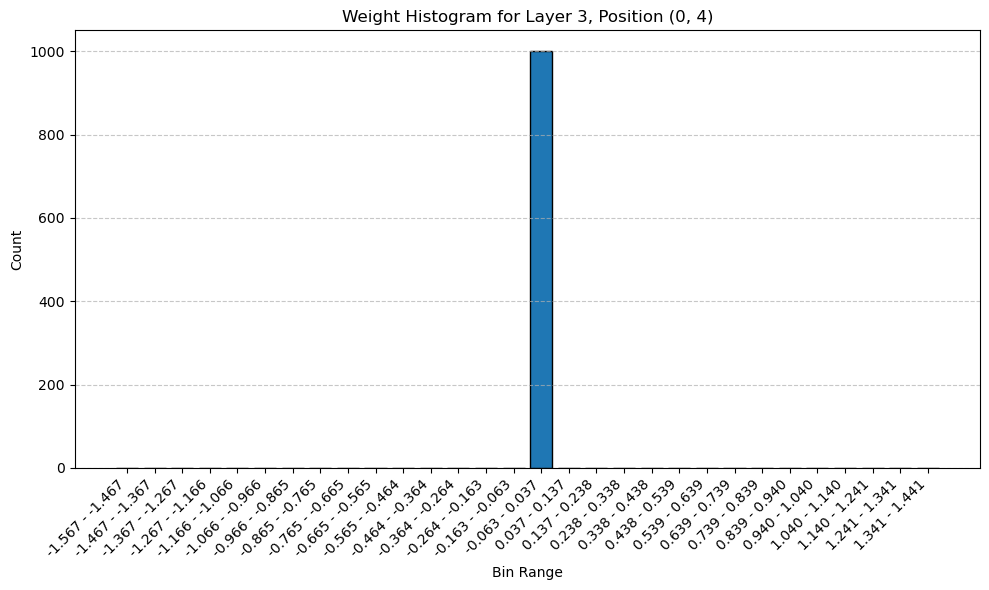

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

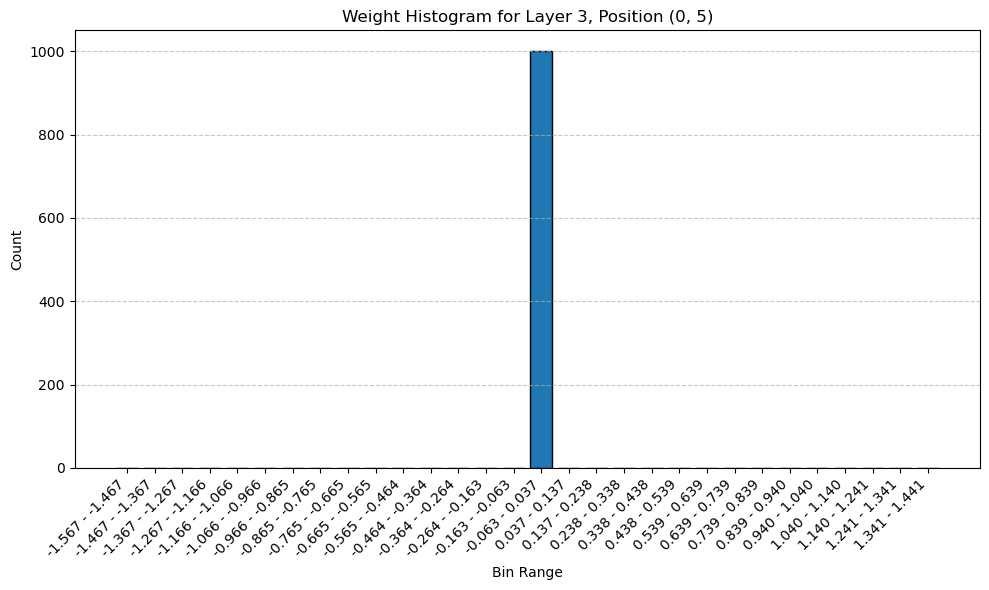

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

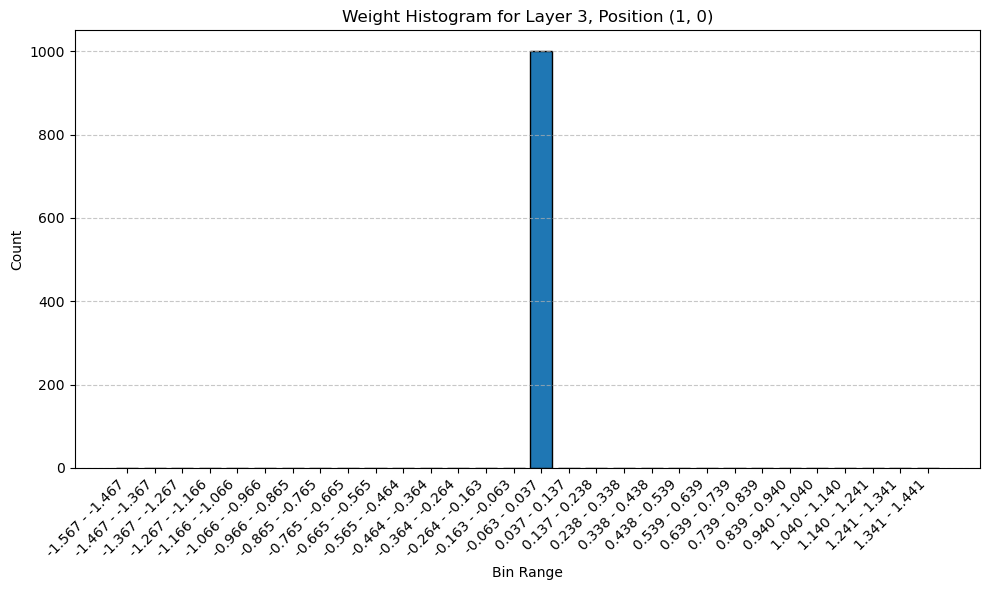

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

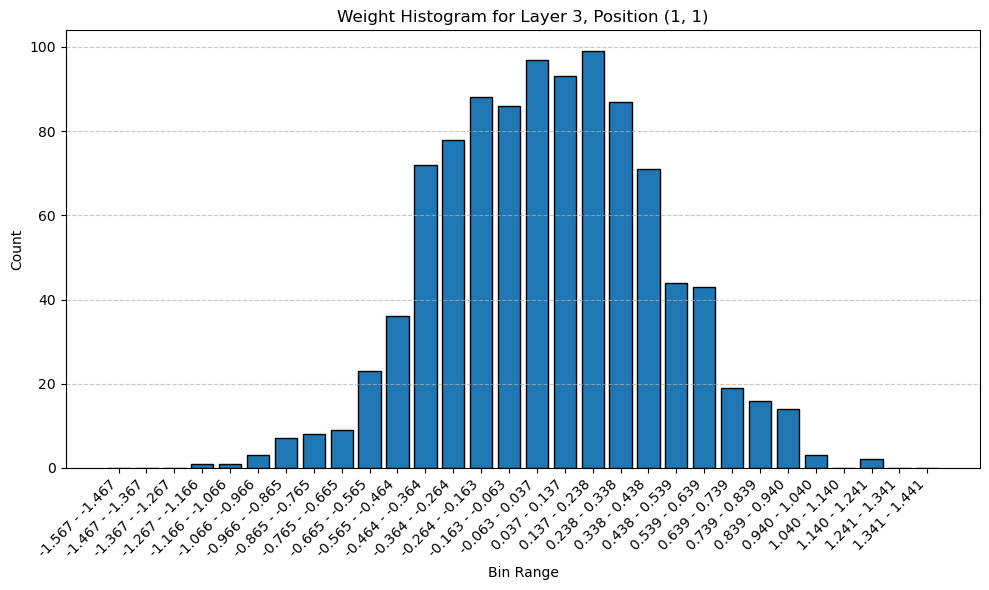

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

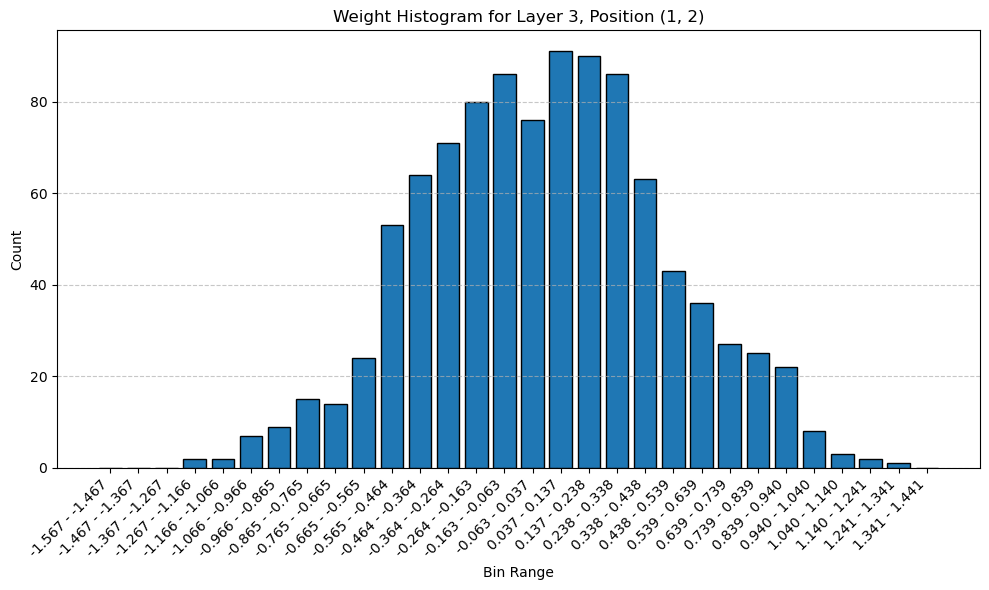

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

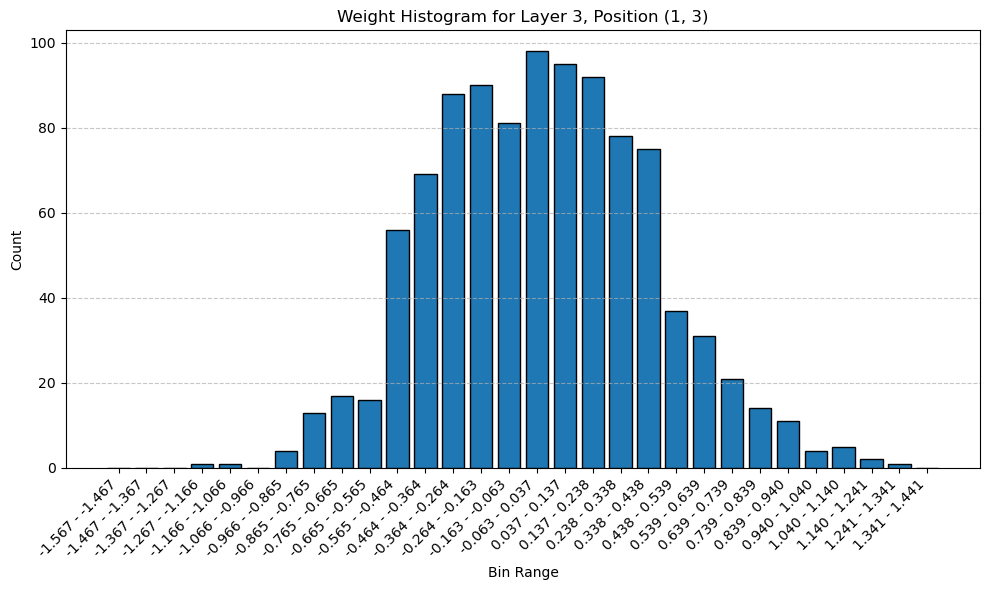

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

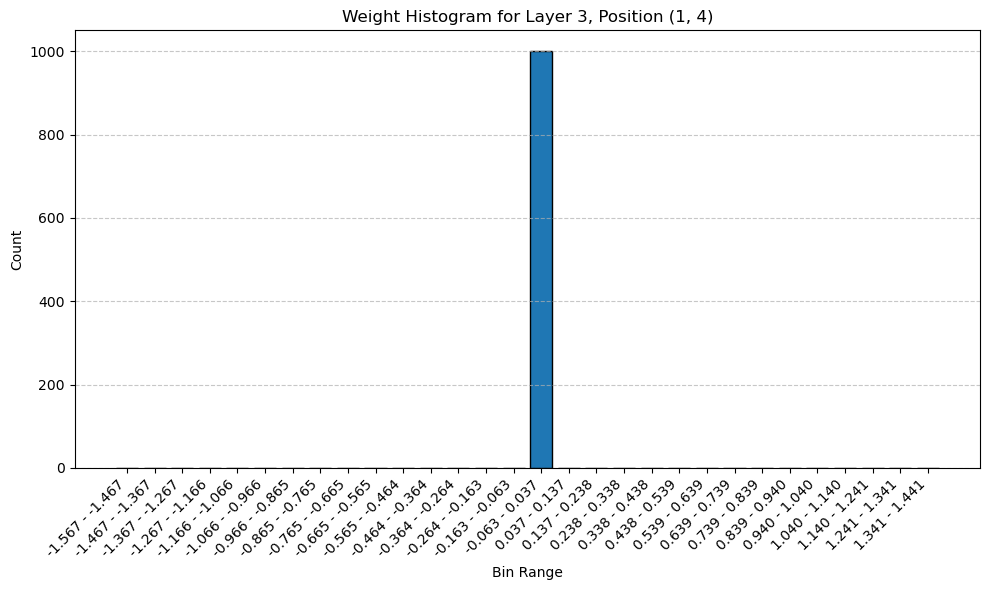

Press Enter to continue, or type 'q' to stop: 
Neuron 1, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

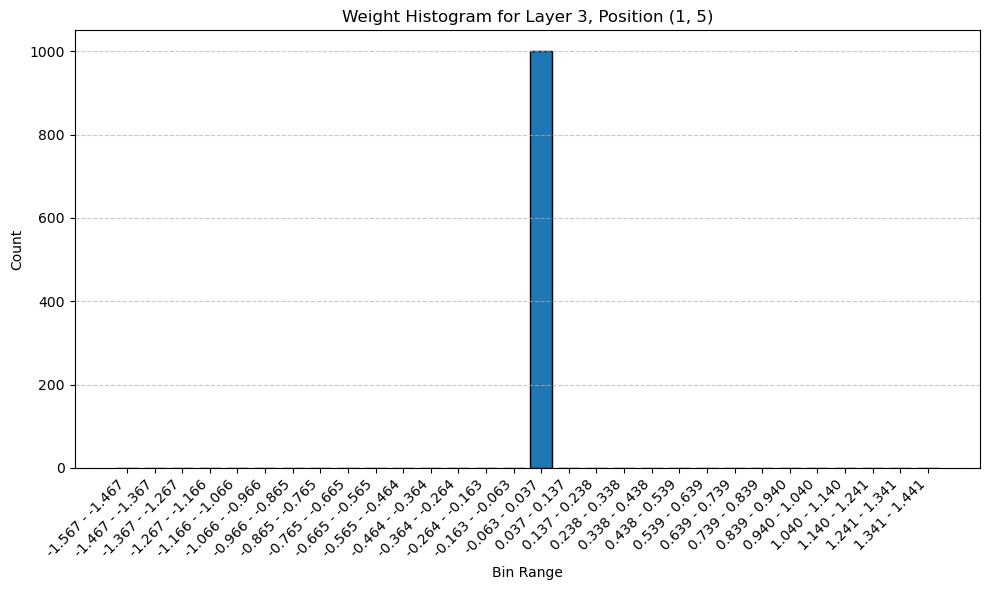

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

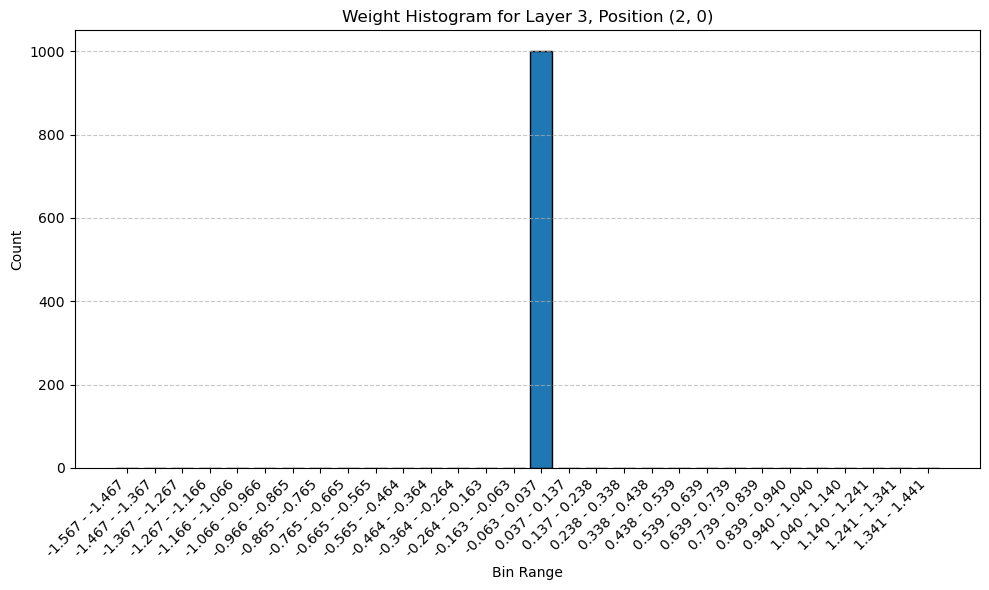

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

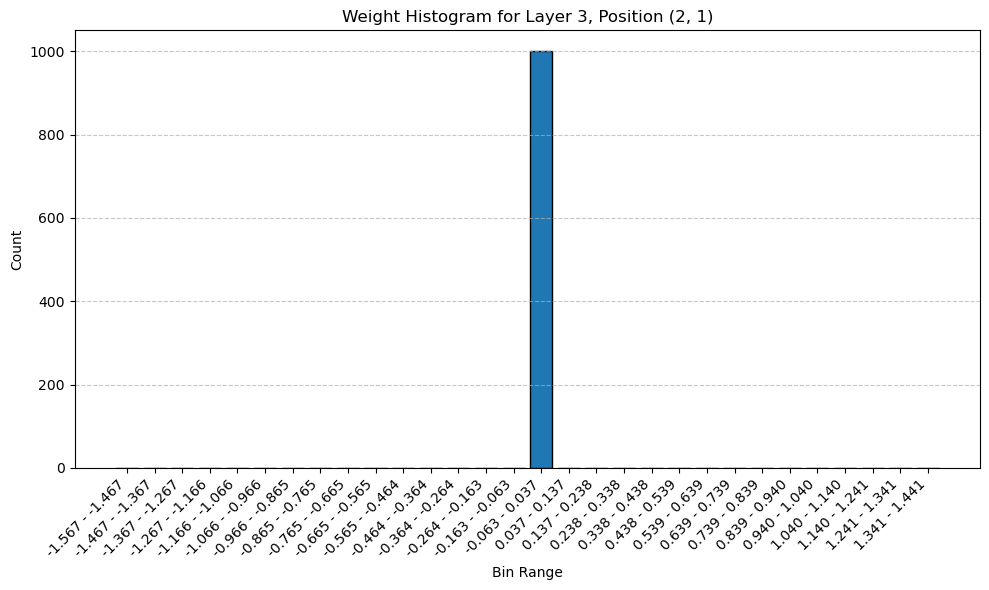

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

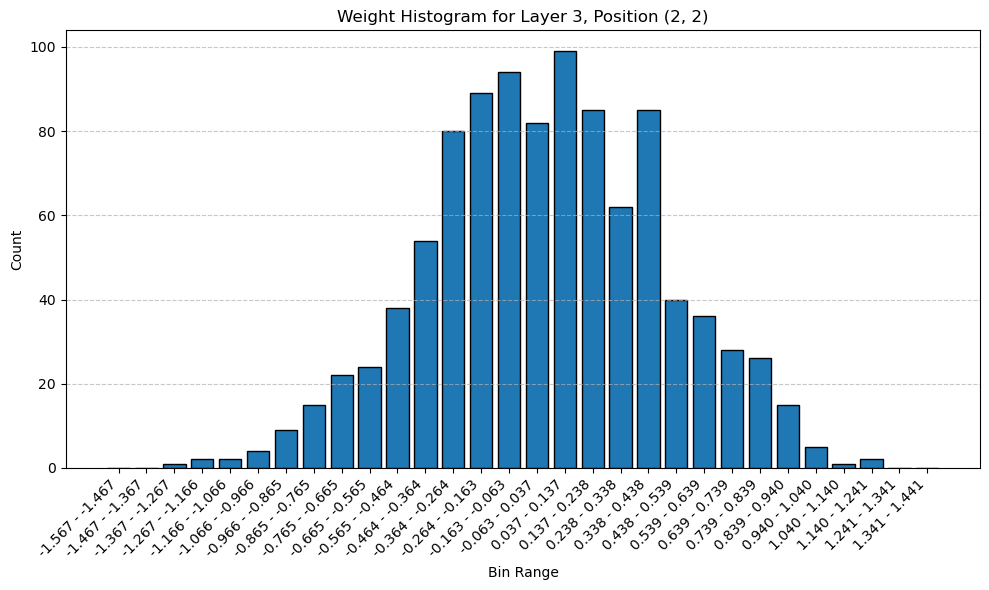

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

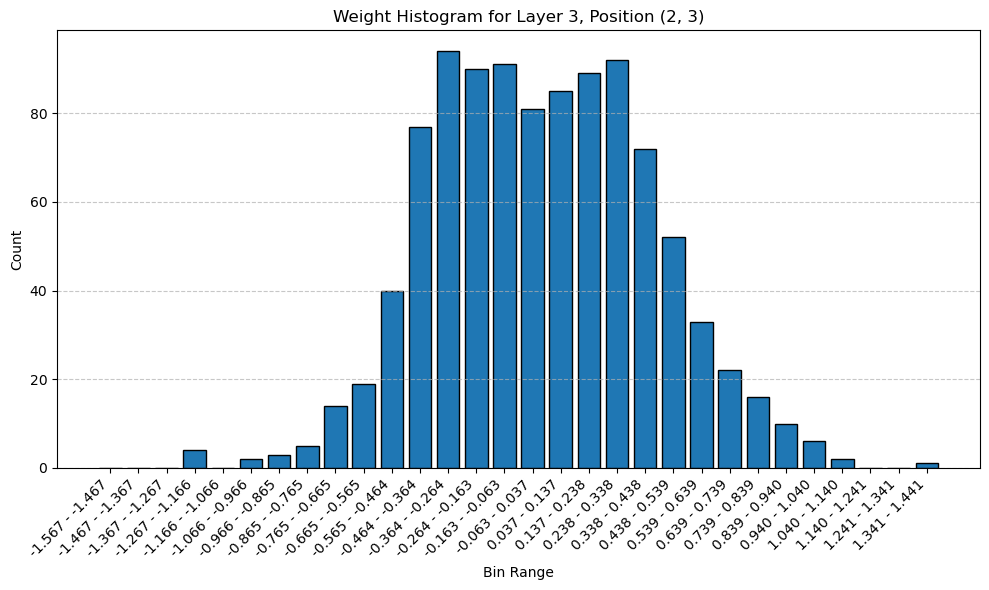

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

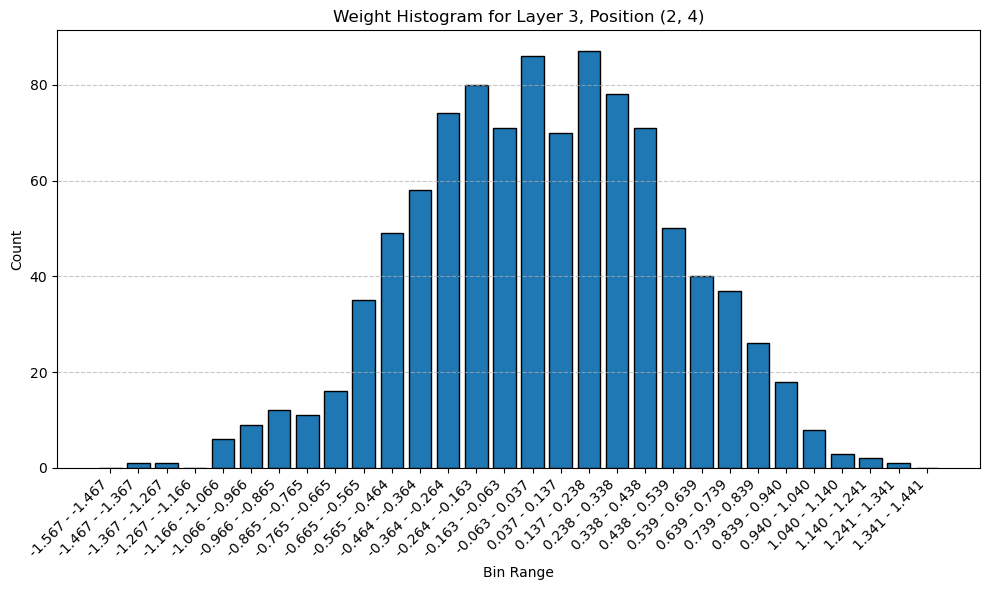

Press Enter to continue, or type 'q' to stop: 
Neuron 2, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

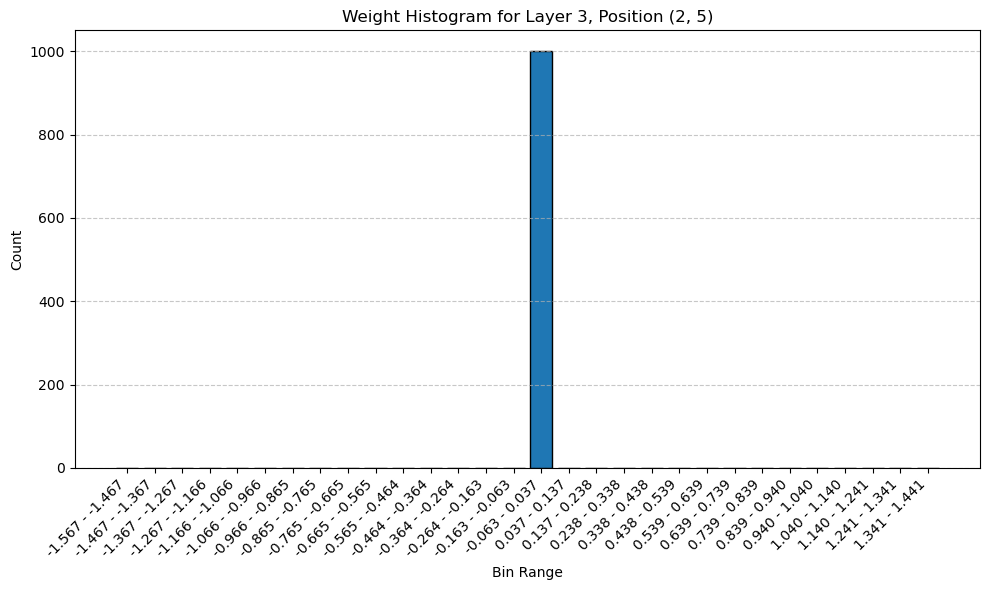

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

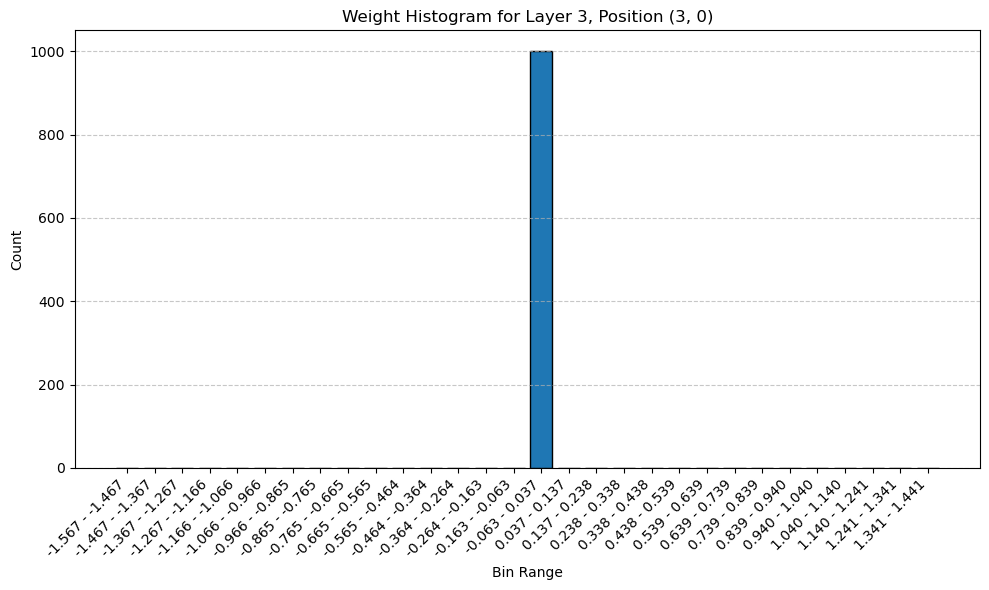

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

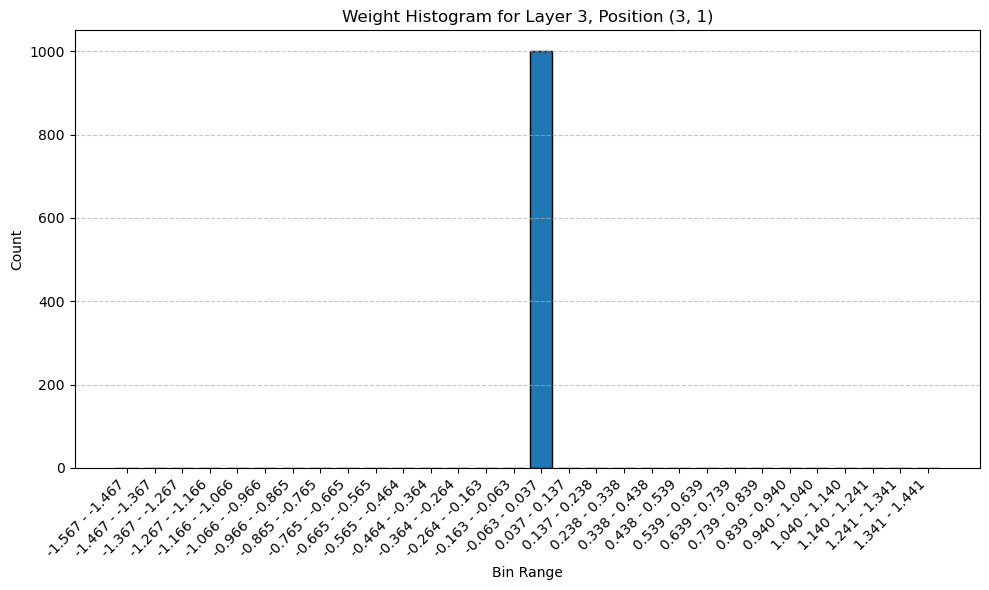

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

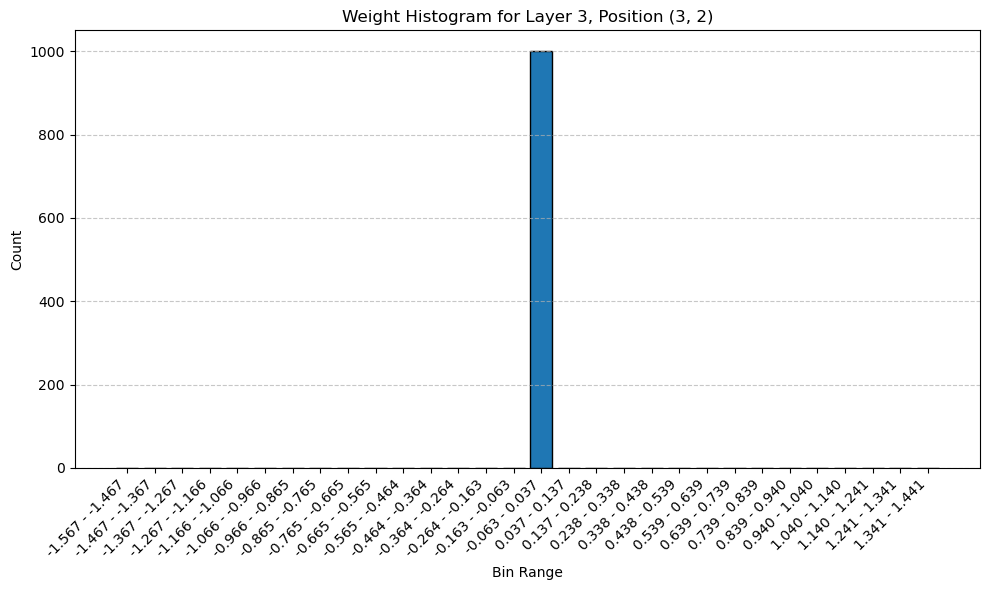

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

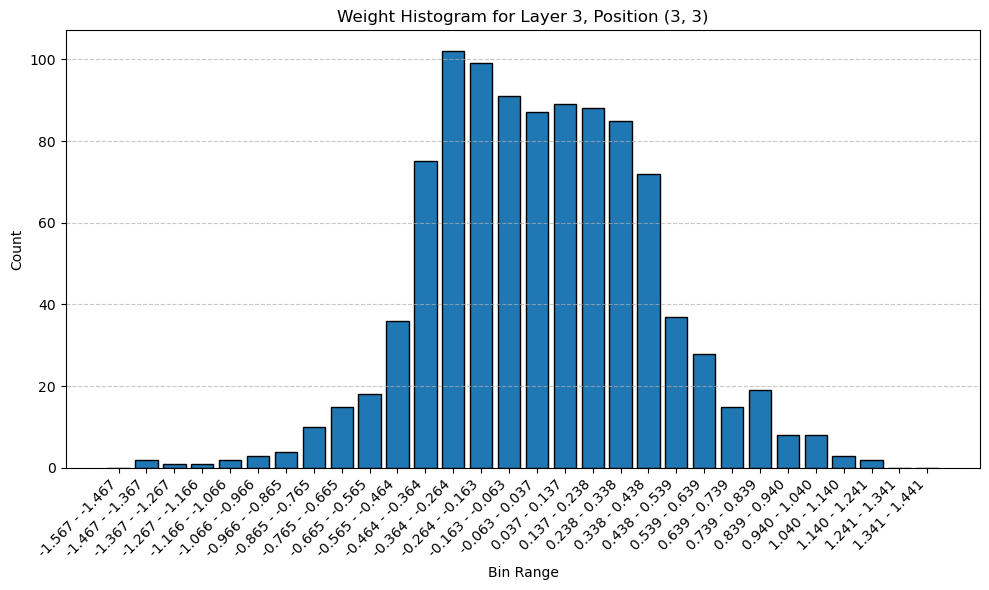

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

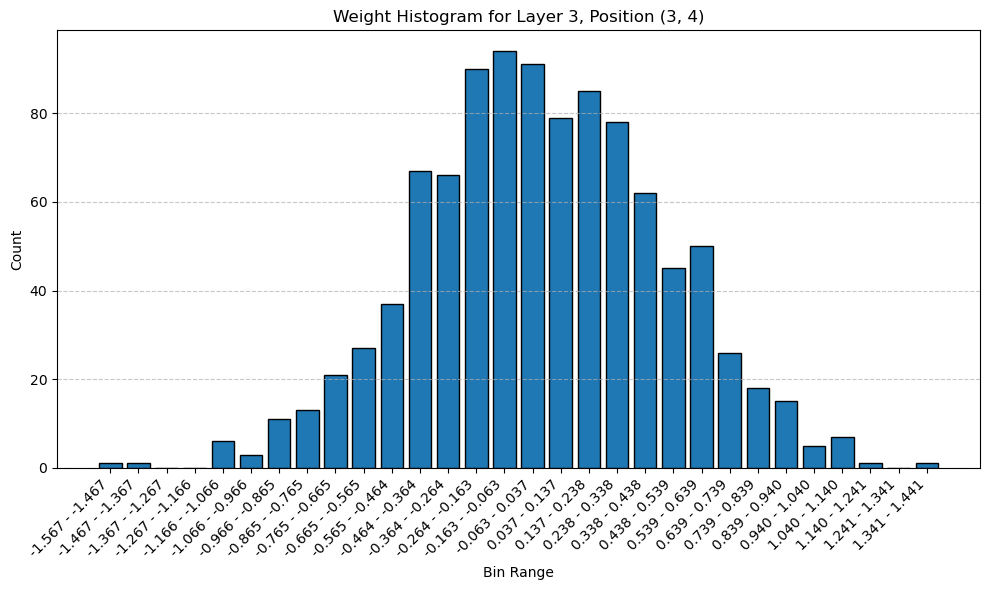

Press Enter to continue, or type 'q' to stop: 
Neuron 3, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

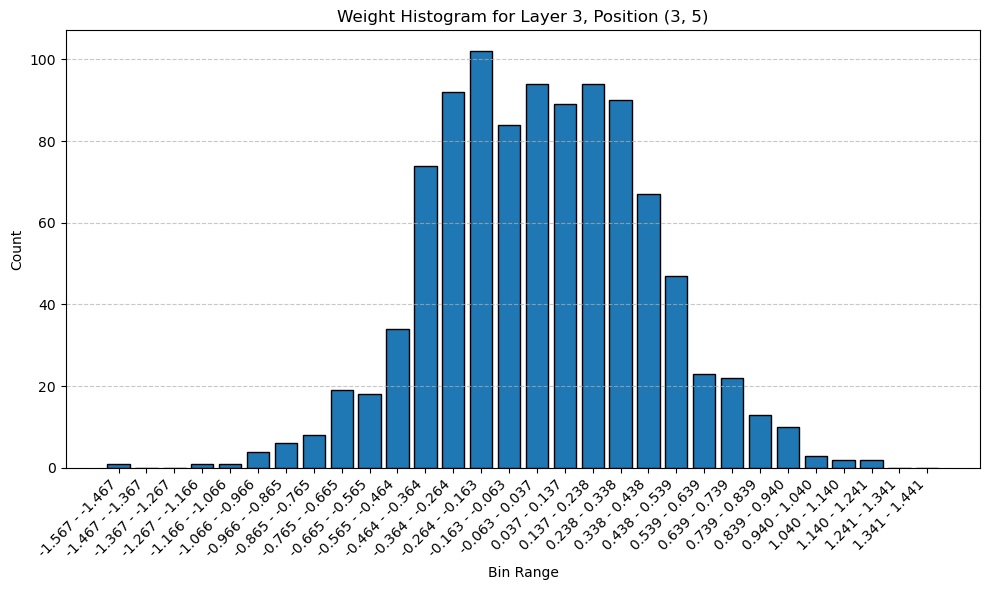

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

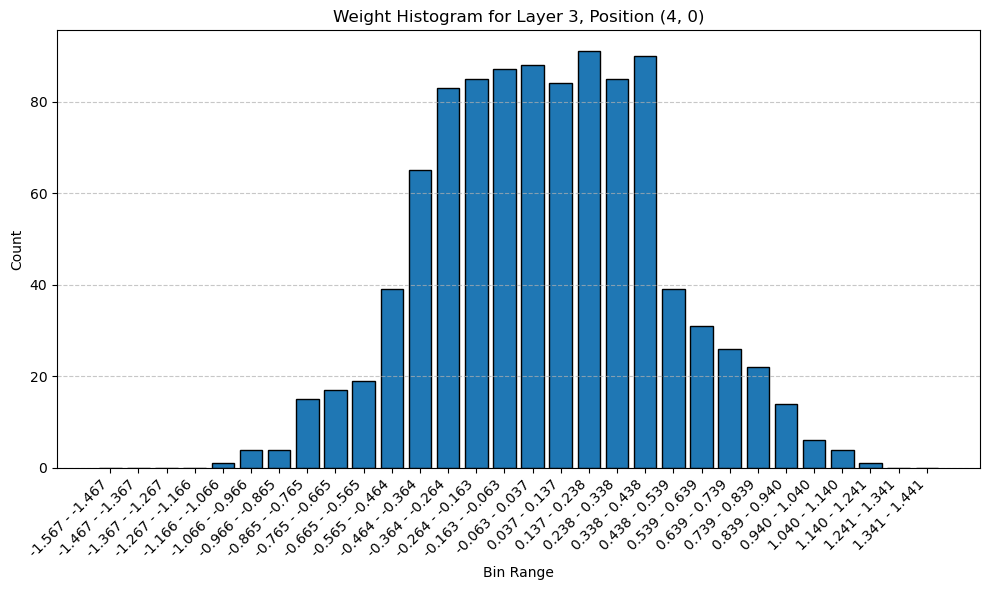

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

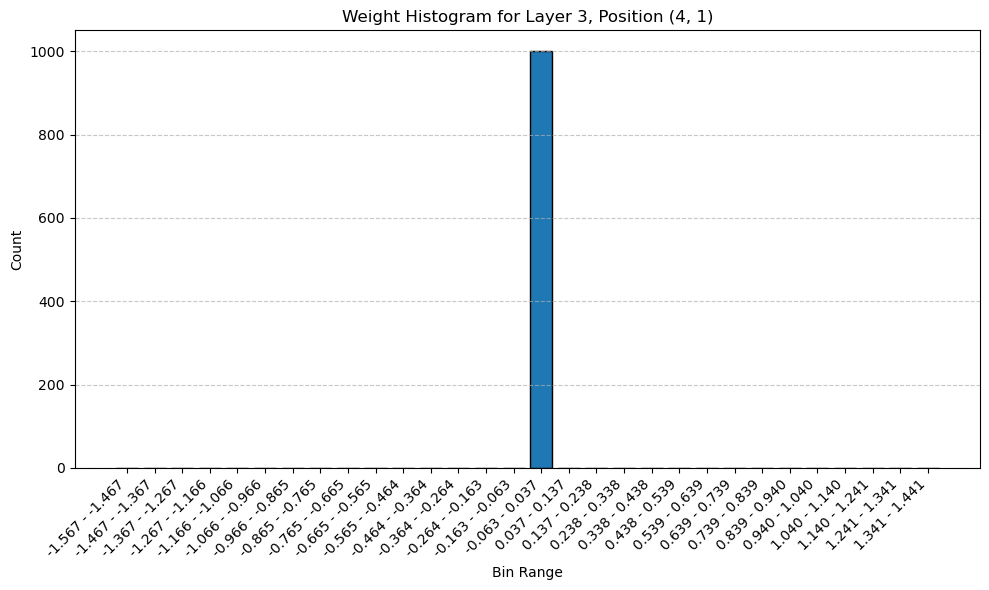

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

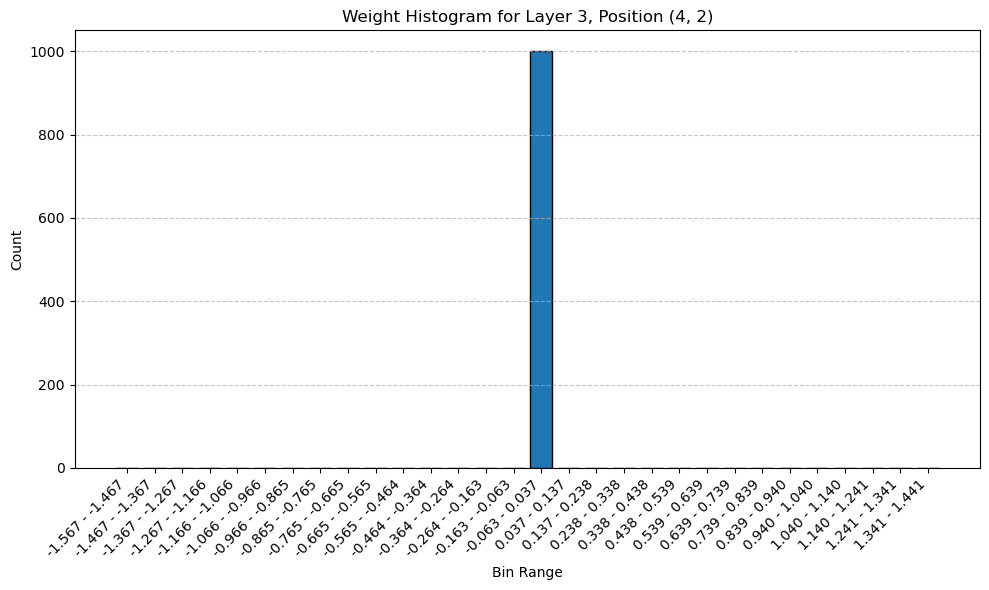

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

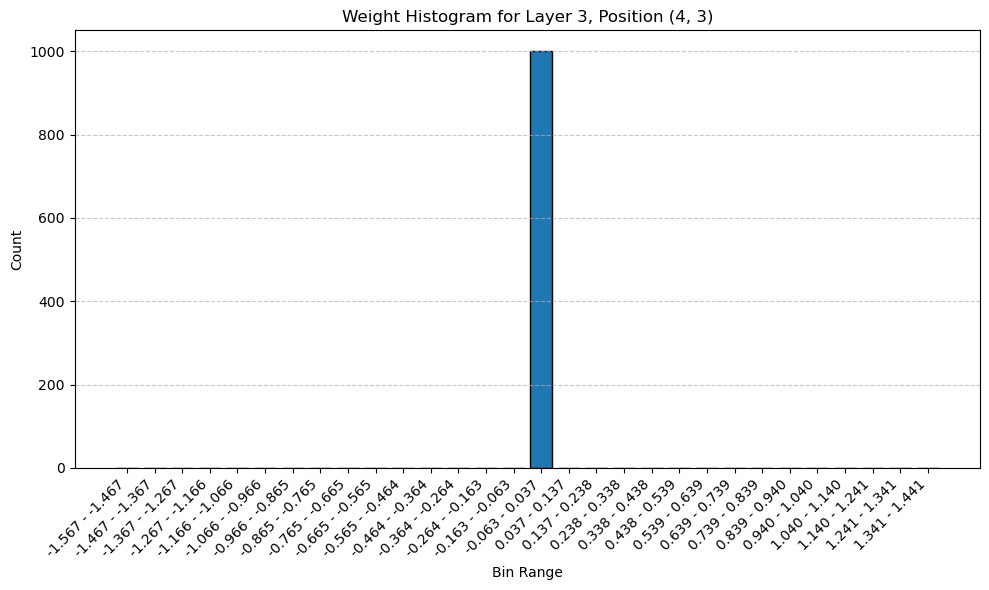

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

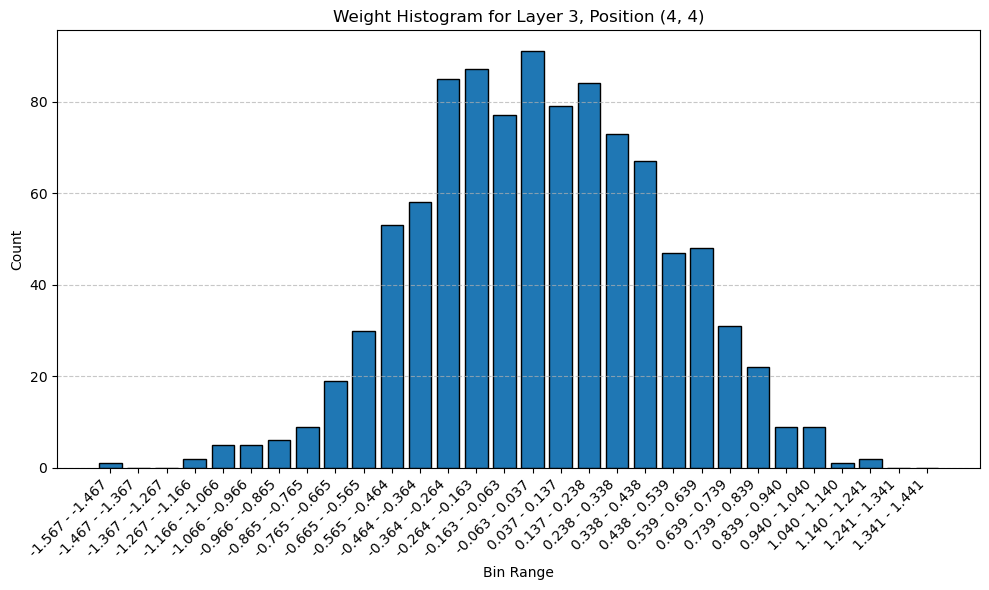

Press Enter to continue, or type 'q' to stop: 
Neuron 4, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

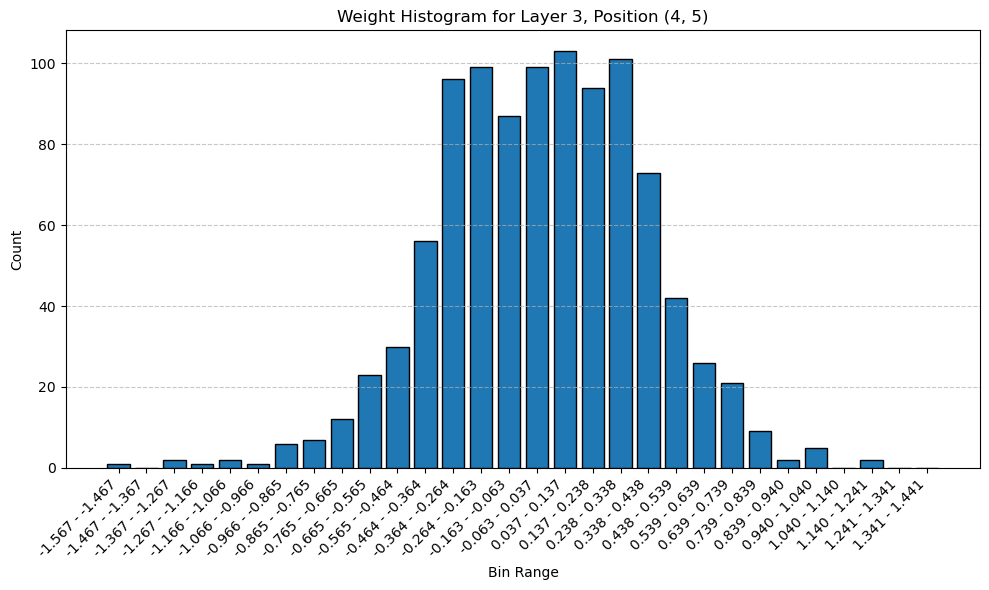

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 0


<Figure size 640x480 with 0 Axes>

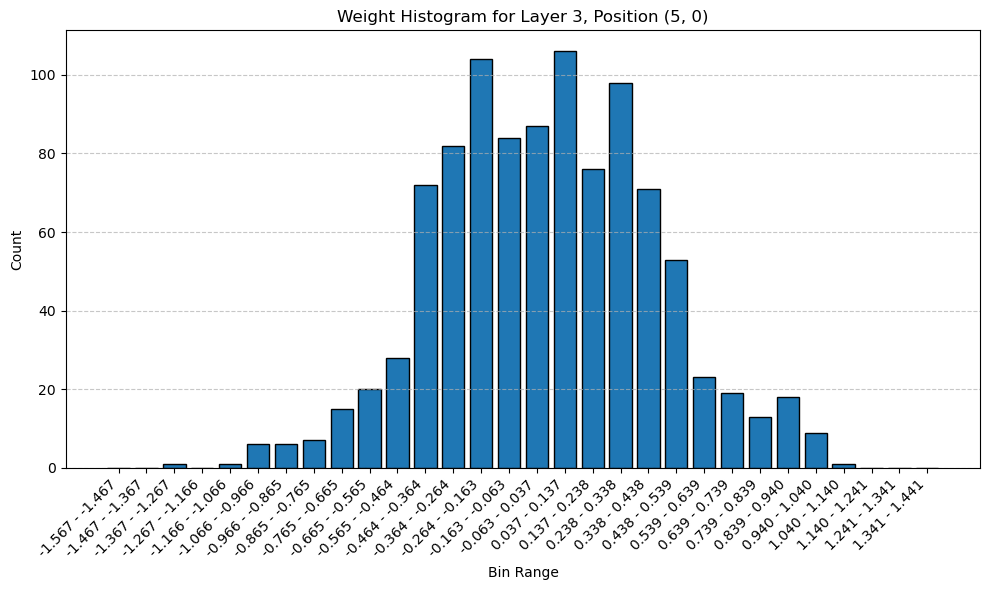

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

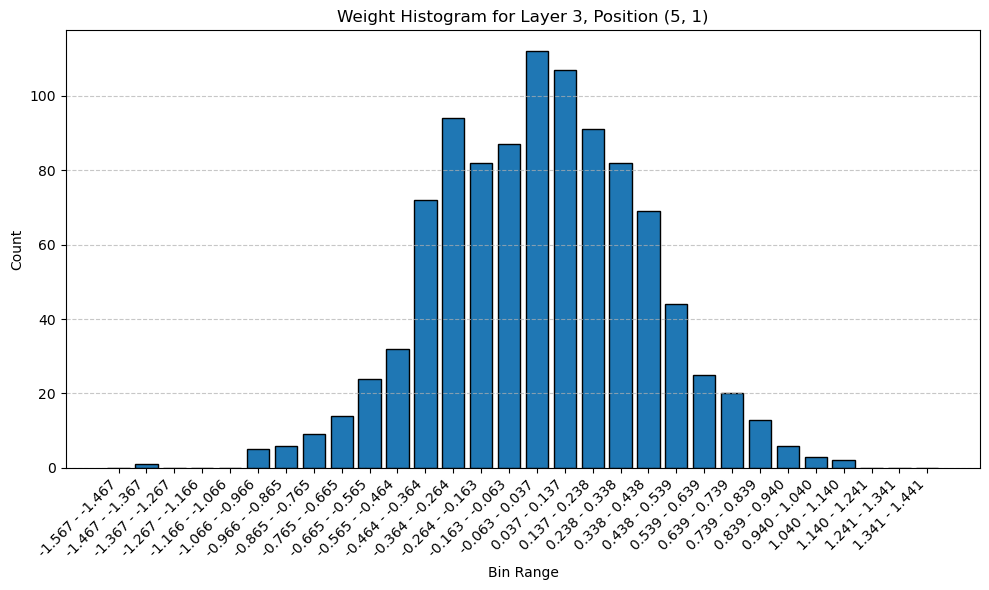

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

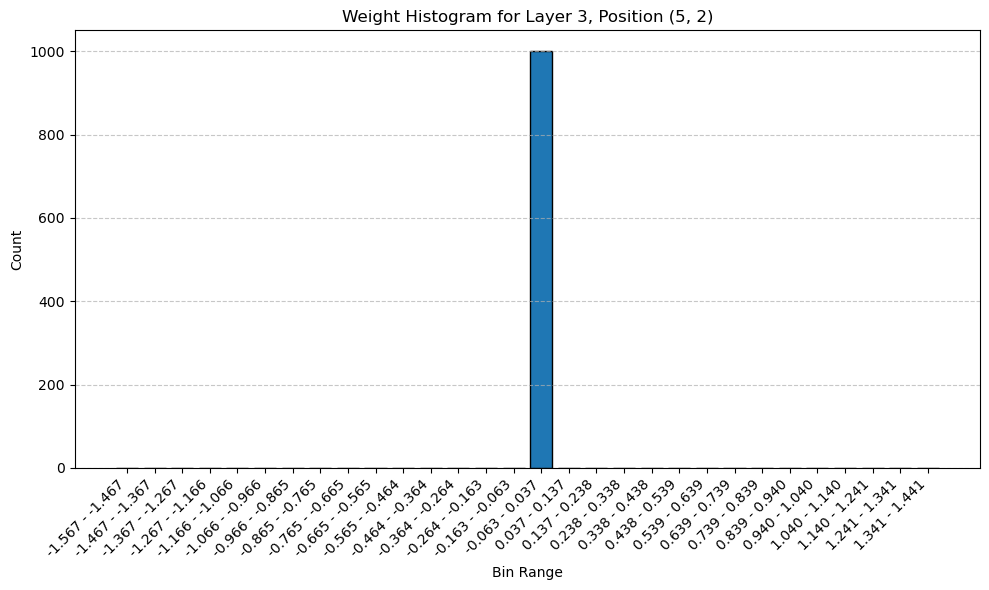

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

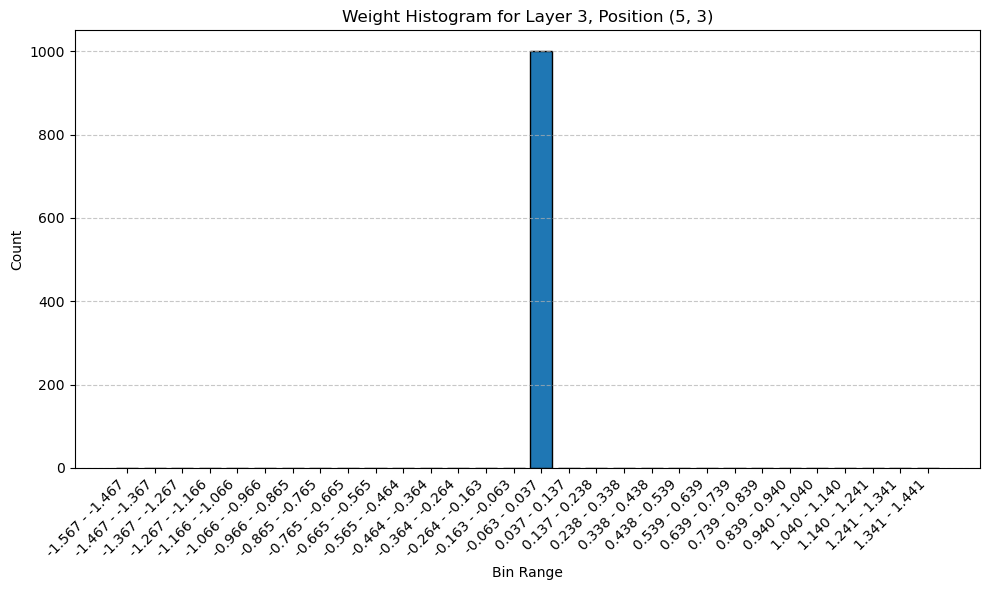

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

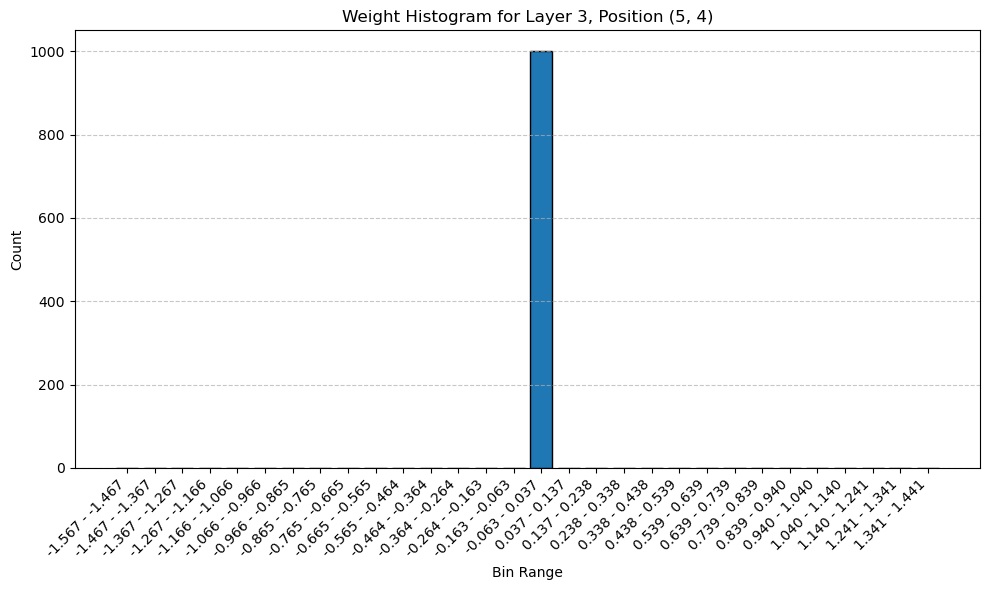

Press Enter to continue, or type 'q' to stop: 
Neuron 5, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

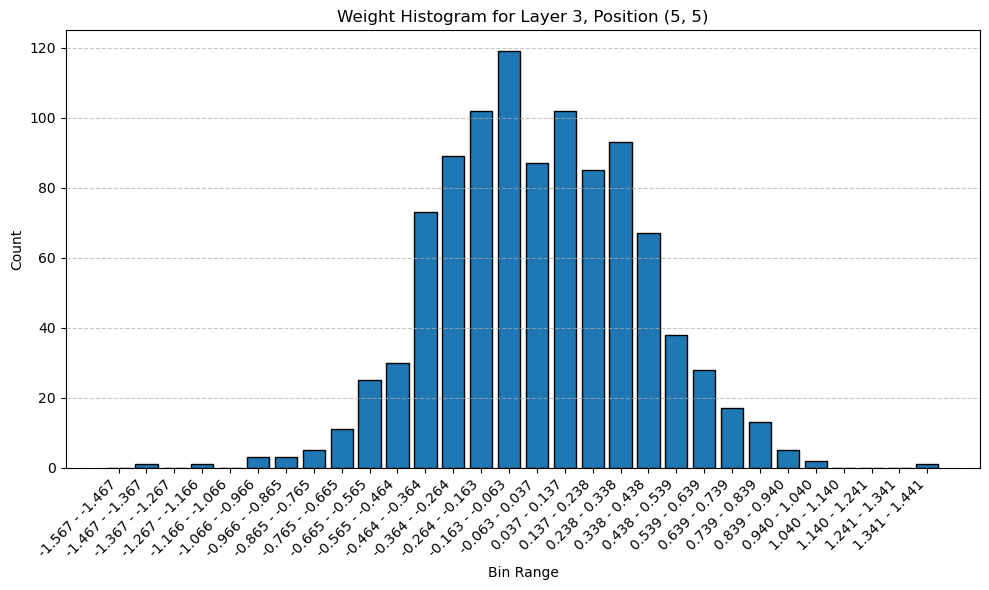

Press Enter to continue, or type 'q' to stop: 


<Figure size 640x480 with 0 Axes>

In [12]:
weights_walkthrough(perm_free_layer_weight_distributions, 'previous_layer_first', 3, perm_free_layer_bin_ranges[3])

Neuron 0, Incoming Weight 0


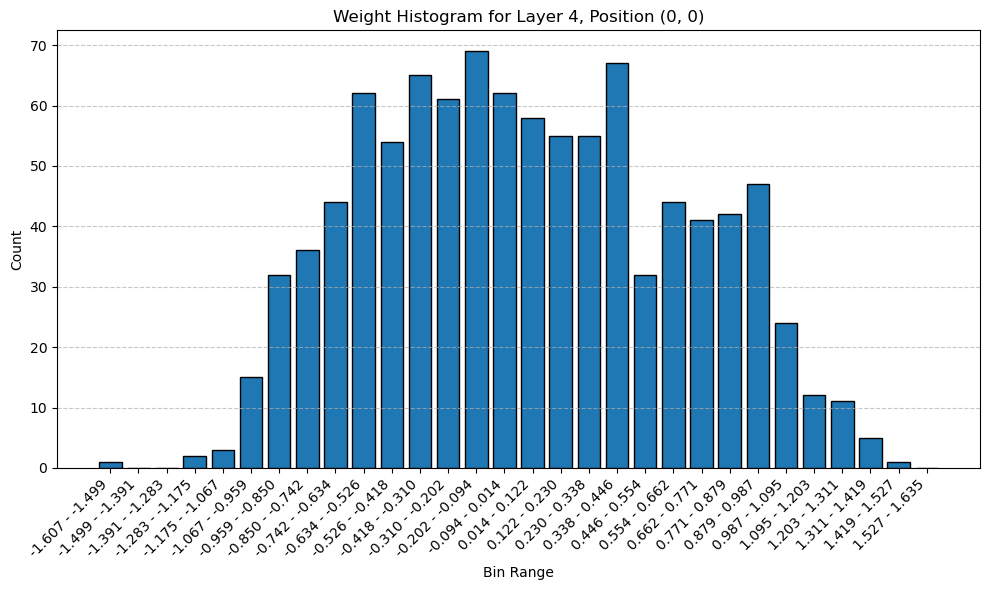

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 1


<Figure size 640x480 with 0 Axes>

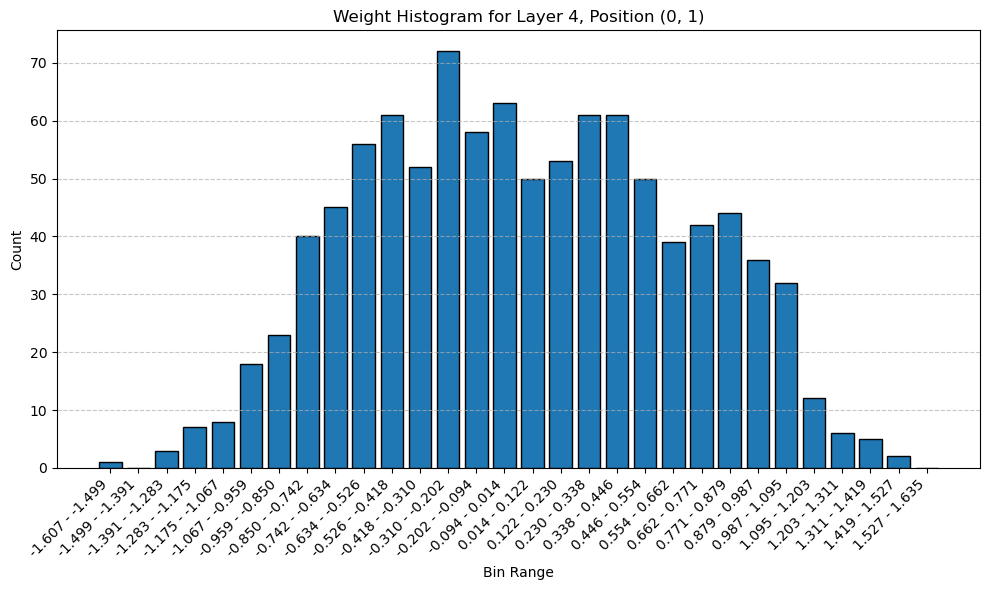

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 2


<Figure size 640x480 with 0 Axes>

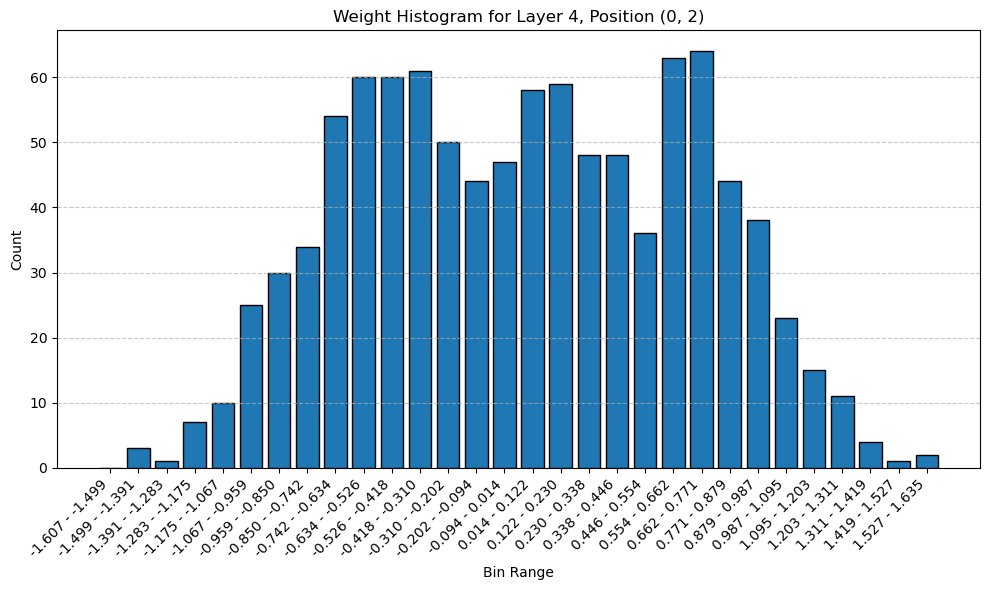

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 3


<Figure size 640x480 with 0 Axes>

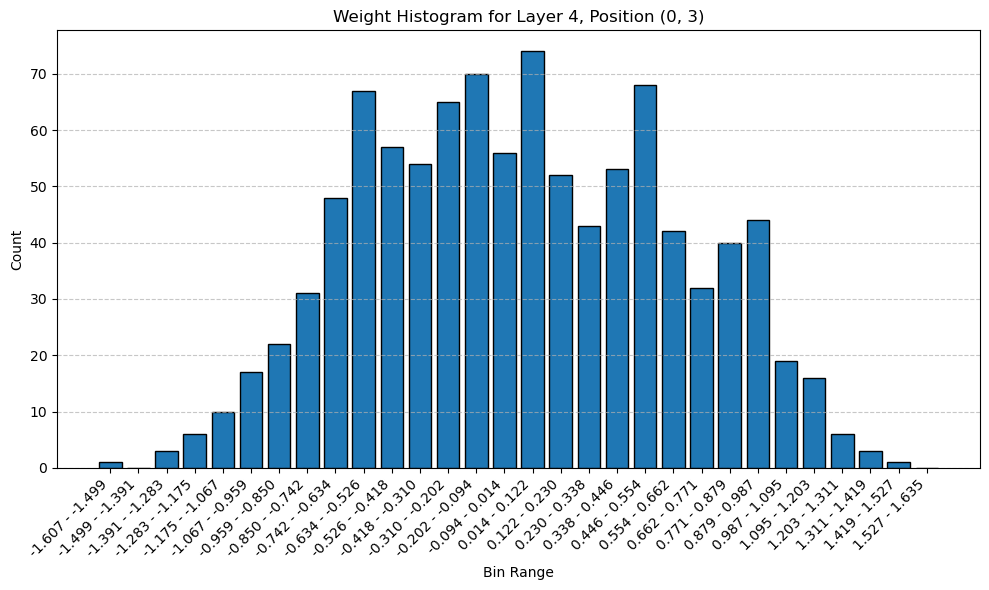

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 4


<Figure size 640x480 with 0 Axes>

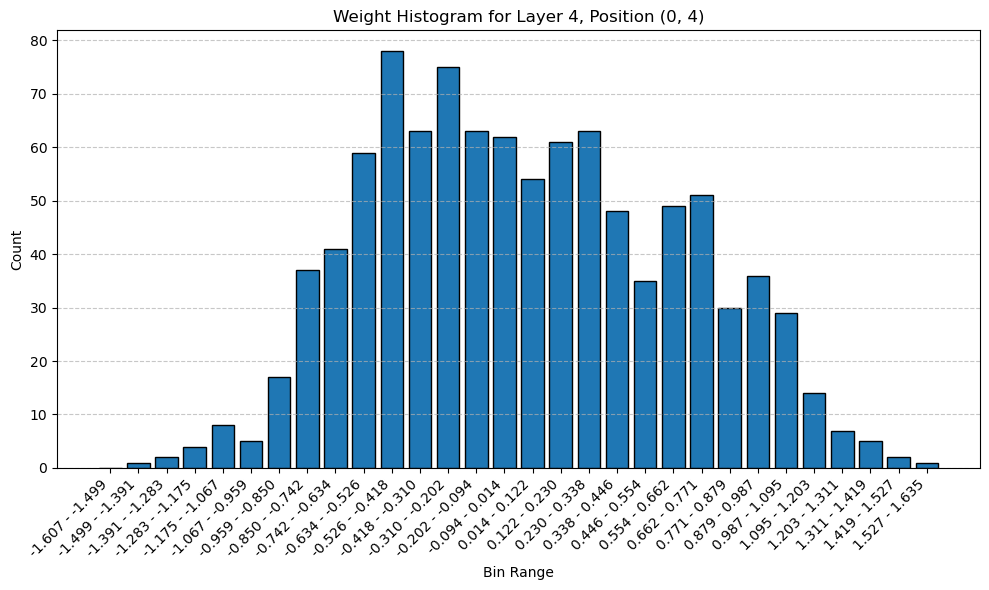

Press Enter to continue, or type 'q' to stop: 
Neuron 0, Incoming Weight 5


<Figure size 640x480 with 0 Axes>

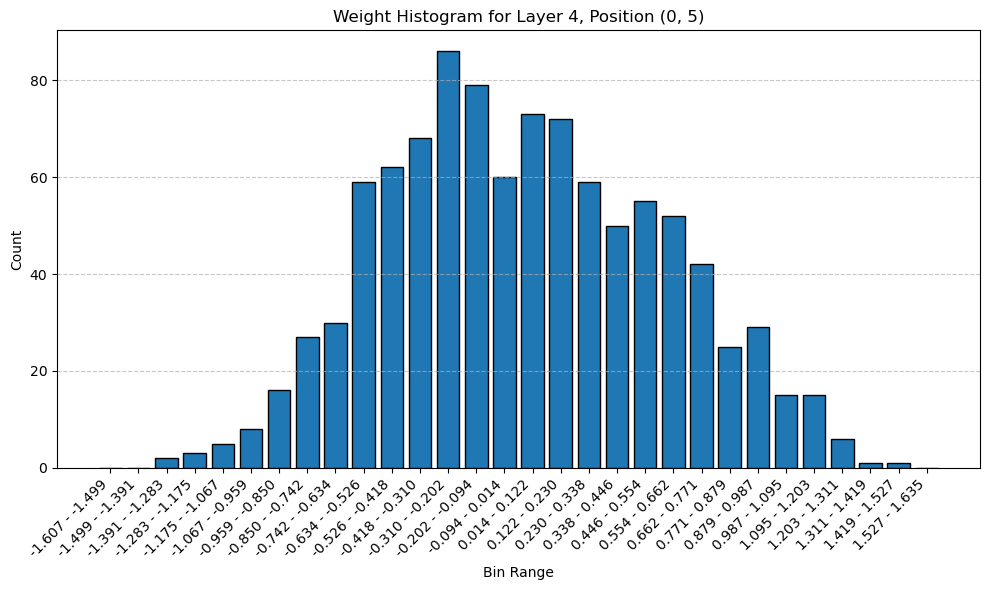

Press Enter to continue, or type 'q' to stop: 


<Figure size 640x480 with 0 Axes>

In [13]:
weights_walkthrough(perm_free_layer_weight_distributions, 'previous_layer_first', 4, perm_free_layer_bin_ranges[4])

Normalize distributions

In [ ]:
normalized_distributions = []
for layer in layer_weight_distributions:
    layer_counts = []
    for neuron in layer:
        neuron_counts = []
        for from_weight in neuron:
            #total should be num of networks
            total = sum(from_weight)
            normalized_bin_counts = [bin_count / total for bin_count in from_weight]
            neuron_counts.append(np.array(normalized_bin_counts))
        layer_counts.append(np.array(neuron_counts))
    normalized_distributions.append(np.array(layer_counts))

In [ ]:
from scipy.stats import norm
from scipy.optimize import curve_fit

def normal_pdf(x, mu, sigma, amplitude):
    return amplitude * norm.pdf(x, mu, sigma)

In [ ]:
def return_weight_bins_plot(weight_distributions, layer, weight_position, bin_edges):
    """
    Parameters:
    - weight_distributions: weight counts in the shape (layer, neuron, incoming weight, bin)
    - layer: Index of the layer to plot (0-indexed).
    - weight_position: Tuple indicating the neuron index and incoming weight index in the layer.
    - bin_edges: The edges of the bins for the specified layer, used to label the x-axis with actual values.
    """
    weight_distribution = weight_distributions[layer][weight_position[0]][weight_position[1]][:]

    num_bins = len(weight_distribution)

    bin_labels = [f"{bin_edges[i]:.3f} - {bin_edges[i+1]:.3f}" for i in range(num_bins)]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(num_bins), weight_distribution, width=0.8, align='center', edgecolor='black')
    ax.set_xlabel('Bin Range')
    ax.set_ylabel('Count')
    ax.set_title(f'Weight Histogram for Layer {layer}, Position {weight_position}')
    ax.set_xticks(range(num_bins))
    ax.set_xticklabels(bin_labels, rotation=45, ha='right')  # Rotate for readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout()  # Adjust layout to prevent label cut-off
    
    return fig, ax

Generate single-peak gaussian fit params for each weight

In [ ]:
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma):
        return A * np.exp(- (x - mu)**2 / (2 * sigma**2))

def fit_gaussians_to_weight_distributions(weight_distributions, bin_edges_list):
    """
    Fit Gaussian curves to all weight histograms and save the fit parameters.

    Parameters:
    - weight_distributions: List of weight counts, where each element corresponds to a layer and is structured
                            as a NumPy array (neuron, incoming weight, bin).
    - bin_edges_list: List of bin edges for each layer.

    Returns:
    - fit_params: List of fit parameters, mirroring the structure of weight_distributions.
                  Each layer's fit parameters are stored as a NumPy array (neuron, incoming weight, 3).
    """
    fit_params = []

    for layer_idx, (layer_data, bin_edges) in enumerate(zip(weight_distributions, bin_edges_list)):
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        num_neurons, num_from_weights, _ = layer_data.shape
        layer_fit_params = np.zeros((num_neurons, num_from_weights, 3))

        for neuron_idx in range(num_neurons):
            for from_weight_idx in range(num_from_weights):
                weight_distribution = layer_data[neuron_idx, from_weight_idx, :]
                #check for existence
                if np.any(weight_distribution):
                    initial_guess = [
                        np.max(weight_distribution),
                        bin_centers[np.argmax(weight_distribution)],
                        np.std(bin_centers)
                    ]
                    try:
                        #fitting
                        popt, _ = curve_fit(gaussian, bin_centers, weight_distribution, p0=initial_guess)
                    except RuntimeError:
                        print(f"Error - curve_fit failed for layer {layer_idx}, neuron {neuron_idx}, from_weight {from_weight_idx}")
                        popt = initial_guess
                else:
                    popt = [0, 0, 0]
                layer_fit_params[neuron_idx, from_weight_idx, :] = popt
        fit_params.append(layer_fit_params)
    return fit_params


Plot single-peak gaussian distribution

In [ ]:
def plot_weight_bins_with_fit(weight_distributions, bin_edges, fit_params, layer, weight_position, save=True, save_dir="./outputs"):
    """
    Plot the histogram of weights and the fitted Gaussian curve.

    Parameters:
    - weight_distributions: List of weight counts, where each element corresponds to a layer and is structured
                            as a NumPy array (neuron, incoming weight, bin).
    - bin_edges: Bin edges for the specified layer.
    - fit_params: List of fit parameters, mirroring the structure of weight_distributions.
                  Each layer's fit parameters are stored as a NumPy array (neuron, incoming weight, 3).
    - layer: Index of the layer to plot.
    - weight_position: Tuple indicating the neuron index and incoming weight index in the layer.
    """
    neuron_idx, from_weight_idx = weight_position

    #get data
    weight_distribution = weight_distributions[layer][neuron_idx, from_weight_idx, :]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    #get fit params
    fit_params_layer = fit_params[layer]
    fit_params_for_weight = fit_params_layer[neuron_idx, from_weight_idx, :]


    x_fit = np.linspace(bin_edges[0], bin_edges[-1], 1000)
    y_fit = gaussian(x_fit, *fit_params_for_weight)

    plt.figure(figsize=(10, 6))
    plt.bar(bin_centers, weight_distribution, width=np.diff(bin_edges), align='center',
            edgecolor='black', alpha=0.6, label='Histogram')
    plt.plot(x_fit, y_fit, 'r-', label='Fitted Gaussian Curve')
    plt.xlabel('Bin Range')
    plt.ylabel('Count')
    plt.title(f'Weight Histogram and Fitted Curve for Layer {layer}, Position {weight_position}')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    if save: 
        os.makedirs(save_dir, exist_ok=True)
        filename = f"layer{layer}-neuron{neuron_idx}-from{from_weight_idx}-fit.png"
        filepath = os.path.join(save_dir, filename)
        plt.savefig(filepath)


- fit distribution stored as 3 variables in the same 4D matrix as the bin values
- A: amplitude
- mu: mean (center) of Gaussian curve
- sigma: std deviation of curve

In [ ]:
fit_params = fit_gaussians_to_weight_distributions(
    normalized_distributions, bin_edges_list=layer_bin_ranges
)

print(fit_params[1][4][4])

plot_weight_bins_with_fit(
    normalized_distributions, bin_edges=layer_bin_ranges[1],
    fit_params=fit_params, layer=1, weight_position=(4, 1), save=True, save_dir=f"{directory}/outputs"
)
plot_weight_bins_with_fit(
    normalized_distributions, bin_edges=layer_bin_ranges[1],
    fit_params=fit_params, layer=1, weight_position=(4, 0), save=True, save_dir=f"{directory}/outputs"
)

In [ ]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

def fit_gmm_to_weight_distributions(weight_distributions, bin_edges_list, peaks_per_layer, random_state=None, replicate_factor=1000):
    """
    Fits a Gaussian Mixture Model (GMM) to each layer's weight histogram
    by replicating bin_centers replicate_factor * normalized_count times (if > 0).

    Parameters:
      weight_distributions (list of np.ndarray): 
          Each element is shape (num_neurons, num_from_weights, num_bins).
      bin_edges_list (list of np.ndarray): 
          Bin edges for each layer.
      peaks_per_layer (list of int): 
          For each layer, how many Gaussian components to fit.
      random_state (int or None): 
          Random seed for reproducibility.
      replicate_factor (int): 
          Multiplier for normalized counts to avoid int truncation to 0.

    Returns:
      gmm_models (list): 
          A list of length = number of layers, where gmm_models[layer_idx] is
          a 2D array (num_neurons, num_from_weights) of fitted GaussianMixture objects.
          None indicates an empty distribution.
    """
    gmm_models = []

    for layer_idx, (layer_data, bin_edges) in enumerate(zip(weight_distributions, bin_edges_list)):
        n_components = peaks_per_layer[layer_idx]
        num_neurons, num_from_weights, num_bins = layer_data.shape
        layer_models = np.empty((num_neurons, num_from_weights), dtype=object)

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        for neuron_idx in range(num_neurons):
            for from_weight_idx in range(num_from_weights):
                counts = layer_data[neuron_idx, from_weight_idx, :]
                if np.any(counts):
                    X_list = []
                    for center, c in zip(bin_centers, counts):
                        #scaling up normalized count
                        if c < 1:
                            rep_count = int(round(c * replicate_factor))
                        else:
                            rep_count = int(c)
                            
                        if rep_count > 0:
                            X_list.extend([center] * rep_count)

                    if len(X_list) == 0:
                        layer_models[neuron_idx, from_weight_idx] = None
                        continue

                    X = np.array(X_list).reshape(-1, 1)
                    gmm = GaussianMixture(
                        n_components=n_components,
                        random_state=random_state
                    )
                    gmm.fit(X)
                    layer_models[neuron_idx, from_weight_idx] = gmm
                else:
                    layer_models[neuron_idx, from_weight_idx] = None

        gmm_models.append(layer_models)

    return gmm_models

def plot_weight_bins_with_gmm(weight_distributions, bin_edges_list, gmm_models, layer, weight_position,
                              scale_to_hist=True, show_individual=True, save=True, save_dir="./outputs"):
    """
    Plot the histogram of weights and the fitted GMM for a specified (layer, neuron_idx, from_weight_idx).
    """
    neuron_idx, from_weight_idx = weight_position
    gmm = gmm_models[layer][neuron_idx, from_weight_idx]

    if gmm is None:
        print("No data or GMM not fitted for this distribution.")
        return

    weight_distribution = weight_distributions[layer][neuron_idx, from_weight_idx, :]
    bin_edges = bin_edges_list[layer]
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Evaluate the GMM PDF on a smooth grid
    x_fit = np.linspace(bin_edges[0], bin_edges[-1], 1000).reshape(-1, 1)
    log_probs = gmm.score_samples(x_fit)
    pdf = np.exp(log_probs)

    #scale the fit st it matches the height of histogram, optional
    counts_sum = np.sum(weight_distribution)
    bin_width = (bin_edges[-1] - bin_edges[0]) / (len(bin_edges) - 1) if len(bin_edges) > 1 else 1.0
    if scale_to_hist:
        pdf *= (counts_sum * bin_width)

    plt.figure(figsize=(8, 5))
    plt.bar(bin_centers, weight_distribution, width=np.diff(bin_edges),
            align='center', edgecolor='black', alpha=0.6, label='Histogram')
    plt.plot(x_fit, pdf, 'r-', label='GMM PDF')

    # Plot each component
    if show_individual:
        for i, (w, m, c) in enumerate(zip(gmm.weights_, gmm.means_, gmm.covariances_)):
            mu = m[0]
            sigma = np.sqrt(c[0, 0])
            component_pdf = w * norm.pdf(x_fit.flatten(), mu, sigma)
            if scale_to_hist:
                component_pdf *= (counts_sum * bin_width)
            plt.plot(x_fit, component_pdf, '--', label=f'Component {i+1}')

    plt.xlabel('Bin Range')
    plt.ylabel('Count')
    plt.title(f'Layer {layer}, Position {weight_position} - GMM Fit')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    if save:
        os.makedirs(save_dir, exist_ok=True)
        filename = f"layer{layer}-neuron{neuron_idx}-from{from_weight_idx}-gmm.png"
        filepath = os.path.join(save_dir, filename)
        plt.savefig(filepath)


SK learn gaussian mixture

In [ ]:
peaks_per_layer = [3, 2, 3]
gmm_models = fit_gmm_to_weight_distributions(
    weight_distributions=normalized_distributions,
    bin_edges_list=layer_bin_ranges,
    peaks_per_layer=peaks_per_layer,
    random_state=42
)

layer_to_plot = 0
num_neurons, num_from_weights, _ = normalized_distributions[layer_to_plot].shape

for i in range(num_neurons):
    for j in range(num_from_weights):
        plot_weight_bins_with_gmm(
            weight_distributions=normalized_distributions,
            bin_edges_list=layer_bin_ranges,
            gmm_models=gmm_models,
            layer=layer_to_plot,
            weight_position=(i, j),
            scale_to_hist=True,
            show_individual=True,
            save=True,
            save_dir=f"{directory}/outputs"
        )

In [ ]:
def compute_kl_divergence_gaussians(mu1, sigma1, mu2, sigma2):
    sigma1_adj = max(sigma1, 1e-8)
    sigma2_adj = max(sigma2, 1e-8)
    kl_divergence = np.log(sigma2_adj / sigma1_adj) + \
        (sigma1_adj ** 2 + (mu1 - mu2) ** 2) / (2 * sigma2_adj ** 2) - 0.5
    return kl_divergence

def compute_cross_entropy_gaussians(mu1, sigma1, mu2, sigma2):
    sigma2_adj = max(sigma2, 1e-8)
    cross_entropy = 0.5 * np.log(2 * np.pi * sigma2_adj ** 2) + \
        ((sigma1 ** 2 + (mu1 - mu2) ** 2) / (2 * sigma2_adj ** 2))
    return cross_entropy

def cluster_gaussians_by_kl_divergence(fit_params, threshold):
    """
    Cluster Gaussians within each layer based on KL divergence.

    Parameters:
    - fit_params: List of fit parameters for each layer. Each layer is a NumPy array of shape (neurons, from_weights, 3).
    - threshold: KL divergence threshold for clustering.

    Returns:
    - cluster_indices_list: List over layers. Each layer is a NumPy array of shape (neurons, from_weights) containing cluster indices.
    """
    cluster_indices_list = []

    for layer_idx, layer_params in enumerate(fit_params):
        num_neurons, num_from_weights, _ = layer_params.shape
        total_gaussians = num_neurons * num_from_weights

        #flatten params
        mu_sigma_list = []
        for i in range(num_neurons):
            for j in range(num_from_weights):
                A, mu, sigma = layer_params[i, j, :]
                mu_sigma_list.append((mu, sigma))

        #make adjacecny matrix where mat[i, j] is the distance between i and j 
        kl_matrix = np.zeros((total_gaussians, total_gaussians))
        for idx1 in range(total_gaussians):
            mu1, sigma1 = mu_sigma_list[idx1]
            for idx2 in range(idx1 + 1, total_gaussians):
                mu2, sigma2 = mu_sigma_list[idx2]
                kl = compute_kl_divergence_gaussians(mu1, sigma1, mu2, sigma2)
                kl_matrix[idx1, idx2] = kl
                kl_matrix[idx2, idx1] = kl 

        #filter adjacency matrix by the threshold. replaces wit hbools
        adjacency_matrix = kl_matrix < threshold

        #replace with inedexes
        cluster_indices = np.full(total_gaussians, -1, dtype=int)
        current_cluster = 0
        for idx in range(total_gaussians):
            if cluster_indices[idx] == -1:
                cluster_indices[idx] = current_cluster
                queue = [idx]
                while queue:
                    current_idx = queue.pop(0)
                    neighbors = np.where(adjacency_matrix[current_idx])[0]
                    for neighbor_idx in neighbors:
                        if cluster_indices[neighbor_idx] == -1:
                            cluster_indices[neighbor_idx] = current_cluster
                            queue.append(neighbor_idx)
                current_cluster += 1
        #resahpe
        cluster_indices_layer = cluster_indices.reshape((num_neurons, num_from_weights))
        cluster_indices_list.append(cluster_indices_layer)

    return cluster_indices_list

def cluster_gaussians_by_cross_entropy(fit_params, threshold):
    """
    Cluster Gaussians within each layer based on cross-entropy.

    Parameters:
    - fit_params: List of fit parameters for each layer. Each layer is a NumPy array of shape (neurons, from_weights, 3).
    - threshold: Cross-entropy threshold for clustering.

    Returns:
    - cluster_indices_list: List over layers. Each layer is a NumPy array of shape (neurons, from_weights) containing cluster indices.
    """
    cluster_indices_list = []

    for layer_idx, layer_params in enumerate(fit_params):
        num_neurons, num_from_weights, _ = layer_params.shape
        total_gaussians = num_neurons * num_from_weights

        mu_sigma_list = []
        for i in range(num_neurons):
            for j in range(num_from_weights):
                A, mu, sigma = layer_params[i, j, :]
                mu_sigma_list.append((mu, sigma))

        ce_matrix = np.zeros((total_gaussians, total_gaussians))
        for idx1 in range(total_gaussians):
            mu1, sigma1 = mu_sigma_list[idx1]
            for idx2 in range(idx1 + 1, total_gaussians):
                mu2, sigma2 = mu_sigma_list[idx2]
                ce = compute_cross_entropy_gaussians(mu1, sigma1, mu2, sigma2)
                ce_matrix[idx1, idx2] = ce
                ce_matrix[idx2, idx1] = ce

        adjacency_matrix = ce_matrix < threshold

        cluster_indices = np.full(total_gaussians, -1, dtype=int)
        current_cluster = 0
        for idx in range(total_gaussians):
            if cluster_indices[idx] == -1:
                cluster_indices[idx] = current_cluster
                queue = [idx]
                while queue:
                    current_idx = queue.pop(0)
                    neighbors = np.where(adjacency_matrix[current_idx])[0]
                    for neighbor_idx in neighbors:
                        if cluster_indices[neighbor_idx] == -1:
                            cluster_indices[neighbor_idx] = current_cluster
                            queue.append(neighbor_idx)
                current_cluster += 1

        cluster_indices_layer = cluster_indices.reshape((num_neurons, num_from_weights))
        cluster_indices_list.append(cluster_indices_layer)

    return cluster_indices_list


In [ ]:
kl_threshold = 0.001
ce_threshold = 0.555

kl_indices = cluster_gaussians_by_kl_divergence(fit_params=fit_params, threshold=kl_threshold)
print(kl_indices)

ce_indices = cluster_gaussians_by_cross_entropy(fit_params=fit_params, threshold=ce_threshold)
print(ce_indices)

In [ ]:
def plot_unique_distributions(indices, layer, normalized_distributions, all_bin_edges, fit_params):
    """
    Plot unique distributions for a specified layer based on cluster indices.

    Parameters:
    - indices: A 3D matrix (list of 2D NumPy arrays) where each element corresponds to a layer,
               and each value in the innermost array represents the cluster index for a Gaussian.
               Shape: (layers, neurons, from_weights).
    - layer: The layer (index) for which to plot unique distributions.
    - normalized_distributions: A 4D matrix representing the normalized weight distributions.
                                Shape: (layers, neurons, from_weights, bins).
    - all_bin_edges: A list of bin edges for each layer, used for plotting the histogram bins.
                     Shape: (layers, bin_edges_per_layer).
    - fit_params: A list of fitted Gaussian parameters for each layer.
                  Shape: (layers, neurons, from_weights, 3).

    Description:
    - This function plots unique Gaussian weight distributions for a specified layer.
    - A distribution is considered "unique" if it belongs to a cluster that has not yet been plotted
      (as determined by the cluster indices in `indices`).
    - The function iterates through the neurons and weights of the specified layer, identifies
      unique distributions (based on their cluster index), and plots them using the provided
      `plot_weight_bins_with_fit` function.
    """
    layer_indices = indices[layer]

    seen_indices = set()

    for i, unique_distribution_neuron_indices in enumerate(layer_indices):
        for j, unique_distribution_index in enumerate(unique_distribution_neuron_indices):
            if unique_distribution_index not in seen_indices:
                plot_weight_bins_with_fit(
                    normalized_distributions, layer_bin_ranges[layer], 
                    fit_params=fit_params, layer=layer, weight_position=(i, j)
                )
                seen_indices.add(unique_distribution_index)


In [ ]:
# plot_unique_distributions(kl_indices, 0, normalized_distributions, layer_bin_ranges, fit_params)
# plot_unique_distributions(kl_indices, 1, normalized_distributions, layer_bin_ranges, fit_params)
# plot_unique_distributions(kl_indices, 2, normalized_distributions, layer_bin_ranges, fit_params)


In [ ]:
def save_normalized_distributions(normalized_distributions, save_dir="outputs"):
    """
    Saves the normalized_distributions array as a .npy file in the specified directory.
    """
    os.makedirs(save_dir, exist_ok=True)
    
    save_path = os.path.join(save_dir, "normalized_distributions.npy")
    
    np.save(save_path, np.array(normalized_distributions, dtype=object), allow_pickle=True)
    print(f"normalized_distributions saved to {save_path}")

save_normalized_distributions(normalized_distributions, save_dir=f"{directory}/outputs")

def load_normalized_distributions(load_path="my_list_of_arrays.npy"):
    """
    Loads a .npy file that contains a Python list of NumPy arrays.
    """
    loaded_obj = np.load(load_path, allow_pickle=True)
    #convert the loaded object back to a Python list
    arr_list = loaded_obj.tolist()
    print(f"Loaded list of arrays from: {load_path}")
    return arr_list

load_normalized_distributions("outputs/normalized_distributions.npy")